## BIXI

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import folium
from IPython.display import display
import geopandas as gpd
from shapely.geometry import Point
from shapely.geometry import mapping
from shapely.ops import transform
from folium.plugins import HeatMap
from folium.features import GeoJson, GeoJsonTooltip
from folium import Element
import pyproj
import networkx as nx
import branca
from branca.colormap import linear
import osmnx as ox
from shapely.ops import nearest_points
from itertools import combinations
import pyproj
from shapely.geometry import LineString
from math import comb
#import pulp
import unicodedata
from math import radians, sin, cos, asin, sqrt
from branca.colormap import LinearColormap
import calendar

## BIXI Visualization

#### BIXI Visualization_Trial_ ( Trends )

In [ ]:
## Station behavior (departures / arrivals / net)

dep = df.groupby("STARTSTATIONNAME").size().rename("dep")
arr = df.groupby("ENDSTATIONNAME").size().rename("arr")
st  = pd.concat([dep, arr], axis=1).fillna(0)
st["net"] = st["dep"] - st["arr"]

# attach canonical coords for mapping later
coords = (df.groupby("STARTSTATIONNAME")[["START_LAT_CANON","START_LON_CANON"]]
            .agg("first").rename(columns={"START_LAT_CANON":"lat","START_LON_CANON":"lon"}))
st_geo = st.join(coords, how="left").reset_index(names="Station_Name")

# Top origins figure
top20 = st_geo.sort_values("dep", ascending=False).head(20)
plt.figure(figsize=(9,5))
plt.barh(top20["Station_Name"].astype(str), top20["dep"])
plt.gca().invert_yaxis(); plt.xlabel("Departures")
plt.title("Top 20 origin stations"); plt.tight_layout(); plt.show()


In [ ]:
### Map: stations sized by departures, colored by net balance

m = folium.Map(location=[df["START_LAT_CANON"].mean(), df["START_LON_CANON"].mean()], zoom_start=12)

v = np.percentile(np.abs(st_geo["net"]), 95)
cmap = LinearColormap(["#d73027","#ffffbf","#1a9850"], vmin=-v, vmax=v).to_step(9)
cmap.caption = "Net balance (dep − arr)"

for _, r in st_geo.dropna(subset=["lat","lon"]).iterrows():
    rad = float(np.clip(4 + 10*(r["dep"]/st_geo["dep"].quantile(0.95)), 4, 14))
    col = cmap(r["net"])
    folium.CircleMarker([r["lat"], r["lon"]], radius=rad, color="#222", weight=1,
                        fill=True, fill_color=col, fill_opacity=.9,
                        tooltip=f"{r['Station_Name']} — dep:{int(r['dep'])}, arr:{int(r['arr'])}, net:{int(r['net'])}").add_to(m)
cmap.add_to(m)
m  # display(m) in Jupyter; 

# m.save("stations_net_map.html")


In [ ]:
#### Top OD flows

od = (df.groupby(["STARTSTATIONNAME","ENDSTATIONNAME"]).size()
        .rename("trips").reset_index().sort_values("trips", ascending=False))
od_top = od.head(30)

# station coords dict for drawing straight lines
xy = st_geo.set_index("Station_Name")[["lat","lon"]].to_dict(orient="index")

m2 = folium.Map(location=[df["START_LAT_CANON"].mean(), df["START_LON_CANON"].mean()], zoom_start=12)
maxw = od_top["trips"].max()
for _, r in od_top.iterrows():
    o, d, w = r["STARTSTATIONNAME"], r["ENDSTATIONNAME"], int(r["trips"])
    if (o in xy) and (d in xy):
        folium.PolyLine([[xy[o]["lat"], xy[o]["lon"]],[xy[d]["lat"], xy[d]["lon"]]],
                        color="#2B8CBE", weight=2+8*(w/maxw), opacity=.6,
                        tooltip=f"{o} → {d}: {w} trips").add_to(m2)
m2  # display or save


In [ ]:
# Define seasons (adjust to your paper’s definition)
summer_months = {5,6,7,8,9}   # May–Sep
winter_months = {12,1,2,3}    # Dec–Mar

df["season"] = np.where(df["month"].isin(summer_months), "summer",
                 np.where(df["month"].isin(winter_months), "winter", "other"))

# station-level *departures* per season (you can also use arrivals or both)
season_st = (df[df["season"].isin(["summer","winter"])]
             .groupby(["season","STARTSTATIONNAME"]).size().rename("trips").reset_index())

# add canonical coords & export two CSVs for your optimization inputs
season_st = season_st.merge(st_geo[["Station_Name","lat","lon","dep"]], left_on="STARTSTATIONNAME", right_on="Station_Name", how="left")
season_st = season_st[["season","STARTSTATIONNAME","lat","lon","trips"]].rename(
    columns={"STARTSTATIONNAME":"Station_Name","trips":"Demand"}
)

# season_st[season_st["season"]=="summer"].to_csv("bixi_station_demand_summer.csv", index=False)
# season_st[season_st["season"]=="winter"].to_csv("bixi_station_demand_winter.csv", index=False)
season_st.head()


In [ ]:


# Label seasons exactly as you described
op_months   = {4,5,6,7,8,9,10,11}   # Apr–Nov inclusive
winter_months = {12,1,2,3}          # Dec–Mar

df["season"] = np.where(df["month"].isin(op_months), "operating", "winter")

# Example seasonal aggregates (daily averages too)
daily = df.groupby("date").size().rename("trips").to_frame()
daily["season"] = pd.to_datetime(daily.index).month
daily["season"] = np.where(daily["season"].isin(op_months), "operating", "winter")

season_totals = daily.groupby("season")["trips"].sum().rename("total_trips")
season_days   = daily.groupby("season").size().rename("n_days")
season_stats  = pd.concat([season_totals, season_days], axis=1)
season_stats["avg_trips_per_day"] = season_stats["total_trips"] / season_stats["n_days"]
season_stats


In [ ]:

# Label seasons exactly as you described
op_months   = {4,5,6,7,8,9,10,11}   # Apr–Nov inclusive
winter_months = {12,1,2,3}          # Dec–Mar

df["season"] = np.where(df["month"].isin(op_months), "operating", "winter")

# Example seasonal aggregates (daily averages too)
daily = df.groupby("date").size().rename("trips").to_frame()
daily["season"] = pd.to_datetime(daily.index).month
daily["season"] = np.where(daily["season"].isin(op_months), "operating", "winter")

season_totals = daily.groupby("season")["trips"].sum().rename("total_trips")
season_days   = daily.groupby("season").size().rename("n_days")
season_stats  = pd.concat([season_totals, season_days], axis=1)
season_stats["avg_trips_per_day"] = season_stats["total_trips"] / season_stats["n_days"]
season_stats


In [ ]:
# station-level departures per season (totals and per-day)
st_season = (df
    .groupby(["season","STARTSTATIONNAME"])
    .size()
    .rename("trips")
    .reset_index())

# add canonical coords (for your pipeline)
coords = (df.groupby("STARTSTATIONNAME")[["START_LAT_CANON","START_LON_CANON"]]
            .agg("first").rename(columns={"START_LAT_CANON":"lat","START_LON_CANON":"lon"}))
st_season = st_season.merge(coords, left_on="STARTSTATIONNAME", right_index=True, how="left")

# per-day
ndays = daily.groupby("season").size()
st_season["trips_per_day"] = st_season.apply(
    lambda r: r["trips"]/ndays.loc[r["season"]], axis=1
)

# Export
# st_season.query("season=='operating'")[["STARTSTATIONNAME","lat","lon","trips","trips_per_day"]].rename(
#     columns={"STARTSTATIONNAME":"Station_Name","trips":"Demand_total","trips_per_day":"Demand_daily"}
# ).to_csv("bixi_station_demand_operating.csv", index=False)

# st_season.query("season=='winter'")[["STARTSTATIONNAME","lat","lon","trips","trips_per_day"]].rename(
#     columns={"STARTSTATIONNAME":"Station_Name","trips":"Demand_total","trips_per_day":"Demand_daily"}
# ).to_csv("bixi_station_demand_winter.csv", index=False)


In [ ]:
# Haversine distance (meters) between two (lat,lon) points

def hav_m(p1, p2):
    (lat1,lon1),(lat2,lon2)=p1,p2
    R=6371000.0
    lat1,lon1,lat2,lon2 = map(radians,[lat1,lon1,lat2,lon2])
    dlat=lat2-lat1; dlon=lon2-lon1
    a=sin(dlat/2)**2+cos(lat1)*cos(lat2)*sin(dlon/2)**2
    return 2*R*asin(sqrt(a))

# Top OD
od = (df.groupby(["STARTSTATIONNAME","ENDSTATIONNAME"]).size()
        .rename("trips").reset_index().sort_values("trips", ascending=False))
od_top = od.head(100)  # tune

# coords dict (using canonical coords we computed)
xy = st_geo.set_index("Station_Name")[["lat","lon"]].to_dict(orient="index")

# Filter: remove OD pairs missing coords or too short
min_len_m = 300.0
rows = []
for _, r in od_top.iterrows():
    o, d, w = r["STARTSTATIONNAME"], r["ENDSTATIONNAME"], int(r["trips"])
    if (o not in xy) or (d not in xy) or (o == d): 
        continue
    p1 = (xy[o]["lat"], xy[o]["lon"])
    p2 = (xy[d]["lat"], xy[d]["lon"])
    if hav_m(p1, p2) < min_len_m:
        continue
    rows.append((o,d,w,p1,p2))
od_filt = rows

# Curved arcs (simple quadratic Bezier)
def curved_arc(p1, p2, bend=0.15, n=25):
    # control point offset perpendicular to the segment
    lat1,lon1 = p1; lat2,lon2 = p2
    mx,my = (lat1+lat2)/2, (lon1+lon2)/2
    dx,dy = (lat2-lat1), (lon2-lon1)
    # perpendicular unit vector
    L = (dx**2+dy**2)**0.5 or 1e-9
    ux,uy = -dy/L, dx/L
    cx,cy = mx + bend*ux, my + bend*uy
    t = np.linspace(0,1,n)
    lat = (1-t)**2*lat1 + 2*(1-t)*t*cx + t**2*lat2
    lon = (1-t)**2*lon1 + 2*(1-t)*t*cy + t**2*lon2
    return list(map(list, zip(lat, lon)))

# Map
m2 = folium.Map(
    location=[df["START_LAT_CANON"].mean(), df["START_LON_CANON"].mean()],
    zoom_start=12, tiles="CartoDB positron"
)

# Width/color scaling
weights = np.array([w for _,_,w,_,_ in od_filt]) if od_filt else np.array([1])
q = np.quantile(weights, [0,.5,.8,.95,1])
def color_for(w):
    if   w>=q[4]: return "#084081"
    elif w>=q[3]: return "#0868ac"
    elif w>=q[2]: return "#2b8cbe"
    elif w>=q[1]: return "#4eb3d3"
    else:         return "#7bccc4"

for o,d,w,p1,p2 in od_filt:
    coords = curved_arc(p1, p2, bend=0.12, n=30)
    folium.PolyLine(
        coords, color=color_for(w), weight=float(2+6*(w/weights.max())),
        opacity=0.85, tooltip=f"{o} → {d}: {w} trips"
    ).add_to(m2)

# m2.save("bixi_od_flows.html")   # open in your browser for full tiles
m2


In [ ]:
#### 
### 7-day moving average. It smooths the noisy daily series by averaging each day with the 3 days before and after (centered window)

# Daily with 7-day MA 
daily = df.groupby("date").size().rename("trips").to_frame()
daily["roll7"] = daily["trips"].rolling(7, center=True).mean()

plt.figure(figsize=(11,4))
plt.plot(daily.index, daily["trips"], lw=1, alpha=.35, label="Daily")
plt.plot(daily.index, daily["roll7"],  lw=2.2, label="7-day MA")
plt.ylabel("Trips/day"); plt.xlabel("")
plt.title("BIXI daily ridership (Operating vs Winter)")
plt.grid(alpha=.25); plt.legend(); plt.tight_layout(); plt.show()

# Monthly with month names
month_tot = df.groupby("month").size()
months = range(1,13)
labels = [calendar.month_abbr[m] for m in months]

plt.figure(figsize=(9,4))
plt.bar(months, [month_tot.get(m, 0) for m in months])
plt.xticks(months, labels)
plt.xlabel("Month"); plt.ylabel("Trips")
plt.title("Monthly ridership distribution")
plt.grid(axis='y', alpha=.25); plt.tight_layout(); plt.show()


In [ ]:

### BIXI Temporal Figures
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from matplotlib.dates import MonthLocator, DateFormatter
import calendar
import numpy as np
import pandas as pd

# ---- 0) Styling helpers ----
mpl.rcParams.update({
    "font.size": 12,
    "axes.titleweight": "semibold",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

def fmt_thousands(x, _):
    # 12,340 -> '12.3k'
    if x >= 1e6:  return f"{x/1e6:.1f}M"
    if x >= 1e3:  return f"{x/1e3:.1f}k"
    return f"{x:.0f}"

def label_bars(ax, fmt=lambda v: f"{v:,.0f}", dy=0.01):
    for p in ax.patches:
        h = p.get_height()
        if h > 0:
            ax.text(
                p.get_x() + p.get_width()/2, h*(1+dy),
                fmt(h), ha="center", va="bottom", fontsize=10
            )

# ---- 1) Daily with 7-day moving average ----
daily = df.groupby("date").size().rename("trips").to_frame()
daily.index = pd.to_datetime(daily.index)
daily["roll7"] = daily["trips"].rolling(7, center=True).mean()

fig, ax = plt.subplots(figsize=(12, 4.5))

# Seasonal shading: Operating (Apr–Nov) vs Winter (Dec–Mar)
year = daily.index[0].year
op_months = set([4,5,6,7,8,9,10,11])
# draw light band over operating months
starts = [pd.Timestamp(y, m, 1) for y in sorted(set(daily.index.year)) for m in (4,)]
ends   = [pd.Timestamp(y, 12, 1) for y in sorted(set(daily.index.year))]
# Simpler: shade month-by-month
for d in pd.date_range(daily.index.min(), daily.index.max(), freq="MS"):
    month_is_op = d.month in op_months
    ax.axvspan(d, d + pd.offsets.MonthEnd(1),
               color=("#e8f7f1" if month_is_op else "#f9f1f0"),
               alpha=0.40, lw=0)

# Plot series
ax.plot(daily.index, daily["trips"], color="#8a9aa9", lw=1.0, alpha=0.55, label="Daily")
ax.plot(daily.index, daily["roll7"], color="#1f7a8c", lw=2.4, label="7-day MA")

# Annotate peak
peak_idx = daily["trips"].idxmax()
peak_val = int(daily.loc[peak_idx, "trips"])
ax.scatter([peak_idx],[peak_val], color="#1f7a8c", zorder=5)
ax.text(peak_idx, peak_val*1.05, f"Peak: {peak_val:,.0f}", ha="center", va="bottom", fontsize=10)

# Format axes
ax.set_title("BIXI daily ridership (Operating vs Winter)")
ax.set_ylabel("Trips/day")
ax.yaxis.set_major_formatter(FuncFormatter(fmt_thousands))
ax.xaxis.set_major_locator(MonthLocator(interval=1))
ax.xaxis.set_major_formatter(DateFormatter("%b"))
ax.legend(frameon=False, ncol=2, loc="upper left")
fig.tight_layout()
plt.show()

# ---- 2) Monthly bars with month names & seasonal colors ----
month_tot = df.groupby("month").size().reindex(range(1,13), fill_value=0)
months = np.arange(1, 13)
labels = [calendar.month_abbr[m] for m in months]
colors = ["#2c7fb8" if m in op_months else "#f03b20" for m in months]  # blue=operating, red=winter

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(months, month_tot.values, color=colors, edgecolor="white", linewidth=0.6)
ax.set_xticks(months, labels)
ax.set_xlabel("Month")
ax.set_ylabel("Trips")
ax.set_title("Monthly ridership distribution")
ax.yaxis.set_major_formatter(FuncFormatter(fmt_thousands))

# Legend handles
op_patch  = mpl.patches.Patch(color="#2c7fb8", label="Operating (Apr–Nov)")
win_patch = mpl.patches.Patch(color="#f03b20", label="Winter (Dec–Mar)")
ax.legend(handles=[op_patch, win_patch], frameon=False, loc="upper left")

# Add labels on bars (compact)
label_bars(ax, fmt=lambda v: fmt_thousands(v), dy=0.02)
fig.tight_layout()
plt.show()

# (Optional) Save at print quality
# fig.savefig("bixi_monthly_distribution.png", dpi=300, bbox_inches="tight")


In [ ]:

# --- Ensure time columns exist ---
if "start_dt" not in df.columns:
    df["start_dt"] = pd.to_datetime(df["STARTTIMEMS"], unit="ms", utc=True).dt.tz_convert("America/Montreal")
if "date" not in df.columns:
    df["date"] = df["start_dt"].dt.date
if "month" not in df.columns:
    df["month"] = df["start_dt"].dt.month

# --- Totals per month (1..12) ---
month_tot = df.groupby("month").size().reindex(range(1,13), fill_value=0).rename("trips")

# --- Active days per month (count of distinct calendar dates with ≥1 trip) ---
month_days = (
    df.groupby("month")["date"].nunique()             # number of unique dates per month
      .reindex(range(1,13), fill_value=0)
      .rename("active_days")
)

# --- Build monthly table ---
op_months = {4,5,6,7,8,9,10,11}   # operating season
monthly_df = (
    pd.DataFrame(month_tot)
    .join(month_days)
    .assign(
        month_name   = lambda d: d.index.map(lambda m: calendar.month_abbr[m]),
        season       = lambda d: np.where(d.index.isin(op_months), "operating", "winter"),
        trips_per_day= lambda d: (d["trips"] / d["active_days"]).replace([np.inf,-np.inf], np.nan)
    )
    .reset_index(names="month")
    .loc[:, ["month","month_name","season","trips","active_days","trips_per_day"]]
    .sort_values("month")
)

# --- Pretty display (version-safe) ---
s = (
    monthly_df.style
    .format({"trips":"{:,}", "active_days":"{:,}", "trips_per_day":"{:,.0f}"})
    .set_properties(**{"text-align":"center"})
    .set_table_styles([{"selector":"th","props":[("text-align","center")]}])
)

# pandas >= 1.4: use hide(axis="index"); older: CSS fallback
if hasattr(s, "hide"):
    s = s.hide(axis="index")
else:
    s = s.set_table_styles(s.table_styles + [
        {"selector": "th.row_heading", "props": [("display", "none")]},
        {"selector": "td.row_heading", "props": [("display", "none")]},
    ])

display(s)


# Optional: CSV
# monthly_df.to_csv("bixi_monthly_table.csv", index=False)

# --- Peaks summary (safe) ---
daily = df.groupby("date").size().rename("trips").to_frame()
peak_day = daily["trips"].idxmax()
print(f"Peak day: {peak_day} with {int(daily.loc[peak_day,'trips']):,} trips")

peak_month_row = monthly_df.loc[monthly_df["trips"].idxmax()]
print(f"Peak month: {peak_month_row['month_name']} "
      f"({int(peak_month_row['trips']):,} trips, {peak_month_row['season']}, "
      f"~{peak_month_row['trips_per_day']:.0f} trips/day over {int(peak_month_row['active_days'])} active days)")

# (Optional) top 5 days
top5_days = daily.sort_values("trips", ascending=False).head(5).reset_index()
top5_days.columns = ["date","trips"]
print("\nTop 5 days by trips:")
print(top5_days.assign(trips=top5_days["trips"].map(lambda v: f"{v:,}")).to_string(index=False))


In [ ]:

# --- Ensure time & season columns exist ---
if "start_dt" not in df.columns:
    df["start_dt"] = pd.to_datetime(df["STARTTIMEMS"], unit="ms", utc=True).dt.tz_convert("America/Montreal")
if "date" not in df.columns:
    df["date"] = df["start_dt"].dt.date
if "month" not in df.columns:
    df["month"] = df["start_dt"].dt.month

op_months = {4,5,6,7,8,9,10,11}   # Apr–Nov (operating)
df["season"] = np.where(df["month"].isin(op_months), "operating", "winter")

# --- Parameters (tweak as needed) ---
min_trips_winter = 50     # require at least 50 trips in winter
min_days_winter  = 10     # and active on at least 10 distinct winter days

# --- Aggregate winter departures by station ---
winter = df[df["season"]=="winter"].copy()

winter_st = (winter
    .groupby("STARTSTATIONNAME")
    .agg(trips=("STARTSTATIONNAME","size"),
         active_days=("date","nunique"),
         lat=("START_LAT_CANON","first"),
         lon=("START_LON_CANON","first"))
    .reset_index()
    .rename(columns={"STARTSTATIONNAME":"Station_Name"})
)

# Mark active
winter_st["is_active"] = (winter_st["trips"] >= min_trips_winter) & (winter_st["active_days"] >= min_days_winter)

# Split tables
winter_active  = winter_st[winter_st["is_active"]].sort_values("trips", ascending=False).reset_index(drop=True)
winter_inactive = winter_st[~winter_st["is_active"]].sort_values("trips", ascending=False).reset_index(drop=True)

print(f"Winter-active stations: {len(winter_active)} / {len(winter_st)} "
      f"(thresholds: ≥{min_trips_winter} trips & ≥{min_days_winter} active days)")

# Preview top 10
display(winter_active.head(10)[["Station_Name","trips","active_days","lat","lon"]])

# Optional: save CSVs
# winter_active.to_csv("bixi_winter_active_stations.csv", index=False)
# winter_st.to_csv("bixi_winter_station_stats_all.csv", index=False)


In [ ]:

if len(winter_active) == 0:
    print("No winter-active stations under current thresholds. Lower min_trips_winter/min_days_winter and rerun.")
else:
    # Center map on median coords to be robust to outliers
    center = [winter_active["lat"].median(), winter_active["lon"].median()]
    m_w = folium.Map(location=center, zoom_start=12, tiles="CartoDB positron")

    # Color scale by trips (quantiles for readability)
    vmax = np.percentile(winter_active["trips"], 95)
    cmap = LinearColormap(colors=["#c7e9c0","#74c476","#238b45"], vmin=0, vmax=max(1, vmax))
    cmap.caption = "Winter trips per station"

    for _, r in winter_active.iterrows():
        radius = float(np.clip(4 + 10*(r["trips"]/max(1, vmax)), 4, 16))
        folium.CircleMarker(
            [r["lat"], r["lon"]],
            radius=radius,
            color="#1b4332", weight=0.8,
            fill=True, fill_color=cmap(r["trips"]), fill_opacity=0.95,
            tooltip=(f"<b>{r['Station_Name']}</b><br>"
                     f"Trips (winter): {int(r['trips']):,}<br>"
                     f"Active days: {int(r['active_days'])}")
        ).add_to(m_w)

    cmap.add_to(m_w)
    m_w  # display in Jupyter; or save:
    m_w.save("bixi_winter_active_stations_map.html")


In [ ]:
# Top winter-active stations 
topN = 20
print(f"\nTop {topN} winter-active stations by trips:")
display(
    winter_active.head(topN)[["Station_Name","trips","active_days"]]
        .assign(trips=lambda d: d["trips"].map("{:,}".format))
)

# Share of total winter trips generated by winter-active stations
total_winter_trips = len(winter)
active_winter_trips = winter_active["trips"].sum()
print(f"\nShare of winter trips from active stations: "
      f"{active_winter_trips:,} / {total_winter_trips:,} "
      f"({100*active_winter_trips/max(1,total_winter_trips):.1f}%)")


In [ ]:
# prerequisites used below
df["start_dt"] = pd.to_datetime(df["STARTTIMEMS"], unit="ms", utc=True).dt.tz_convert("America/Montreal")
df["end_dt"]   = pd.to_datetime(df["ENDTIMEMS"],   unit="ms", utc=True).dt.tz_convert("America/Montreal")
df["date"]     = df["start_dt"].dt.date
df["hour"]     = df["start_dt"].dt.hour
df["dow"]      = df["start_dt"].dt.dayofweek
df["month"]    = df["start_dt"].dt.month
op_months      = {4,5,6,7,8,9,10,11}
df["season"]   = np.where(df["month"].isin(op_months), "operating", "winter")


In [ ]:
#### 
# trips per hour per day
hourly = (df.groupby(["season","date","hour"]).size()
            .rename("trips").reset_index())
profiles = (hourly.groupby(["season","hour"])["trips"]
                 .mean().reset_index())

plt.figure(figsize=(9.5,4))
for s,c in [("operating","#1f7a8c"), ("winter","#c44e52")]:
    sub = profiles[profiles["season"]==s]
    plt.plot(sub["hour"], sub["trips"], label=s.title(), lw=2.2, color=c)
plt.xticks(range(0,24,2))
plt.xlabel("Hour of day"); plt.ylabel("Avg trips per day")
plt.title("Diurnal profile (normalized per day)"); plt.grid(alpha=.3); plt.legend()
plt.tight_layout(); plt.show()


In [ ]:
# trip duration distribution by season
dur = (df["end_dt"]-df["start_dt"]).dt.total_seconds()/60
df["duration_m"] = dur.clip(lower=1, upper=120)  # common QC

fig, ax = plt.subplots(1,2, figsize=(12,4))
bins = np.arange(0,125,5)
for s,c in [("operating","#1f7a8c"),("winter","#c44e52")]:
    x = df.loc[df["season"]==s,"duration_m"].dropna()
    ax[0].hist(x, bins=bins, alpha=.5, density=True, label=s.title(), edgecolor="white")
    xs = np.sort(x); F = np.linspace(0,1,len(xs))
    ax[1].plot(xs, F, color=c, lw=2.2, label=s.title())

ax[0].set_title("Duration density"); ax[0].set_xlabel("Minutes"); ax[0].set_ylabel("Density")
ax[1].set_title("Duration CDF");     ax[1].set_xlabel("Minutes"); ax[1].set_ylabel("Cumulative share")
for a in ax: a.grid(alpha=.3); 
ax[1].legend(); plt.tight_layout(); plt.show()


In [ ]:
# departures per station & season (per-day normalized)
dps = (df.groupby(["season","date","STARTSTATIONNAME"]).size()
         .rename("trips").reset_index())
dps = dps.groupby(["season","STARTSTATIONNAME"])["trips"].mean().reset_index()

# pivot and compute log lift
wide = dps.pivot(index="STARTSTATIONNAME", columns="season", values="trips").fillna(0)
wide["lift_log"] = np.log1p(wide.get("operating",0)) - np.log1p(wide.get("winter",0))

# attach coords
coords = (df.groupby("STARTSTATIONNAME")[["START_LAT_CANON","START_LON_CANON"]]
            .agg("first").rename(columns={"START_LAT_CANON":"lat","START_LON_CANON":"lon"}))
lift = wide.join(coords, how="left")

import folium
from branca.colormap import LinearColormap
center = [df["START_LAT_CANON"].mean(), df["START_LON_CANON"].mean()]
m = folium.Map(location=center, zoom_start=12, tiles="CartoDB positron")

v = np.nanpercentile(np.abs(lift["lift_log"]), 95)
cmap = LinearColormap(["#b2182b","#f7f7f7","#2166ac"], vmin=-v, vmax=v)
cmap.caption = "log(1+Op) − log(1+Win)"

for st, r in lift.dropna(subset=["lat","lon"]).iterrows():
    folium.CircleMarker([r["lat"], r["lon"]],
        radius=float(np.clip(4 + 10*(abs(r["lift_log"])/max(v,1e-6)), 4, 14)),
        color="#333", weight=0.8,
        fill=True, fill_color=cmap(r["lift_log"]), fill_opacity=0.95,
        tooltip=(f"{st}<br>Op/day: {wide.loc[st,'operating'] if 'operating' in wide.columns else 0:.1f}"
                 f"<br>Win/day: {wide.loc[st,'winter'] if 'winter' in wide.columns else 0:.1f}")
    ).add_to(m)
cmap.add_to(m); m  # or m.save("station_lift_map.html")


In [ ]:
# Top-K per season
K=80
od = (df.groupby(["season","STARTSTATIONNAME","ENDSTATIONNAME"]).size()
        .rename("trips").reset_index())

# coords
xy = (df.groupby("STARTSTATIONNAME")[["START_LAT_CANON","START_LON_CANON"]]
        .agg("first").rename(columns={"START_LAT_CANON":"lat","START_LON_CANON":"lon"}))

def map_flows(sub, html_file):
    sub = sub.sort_values("trips", ascending=False).head(K)
    m = folium.Map(location=[df["START_LAT_CANON"].mean(), df["START_LON_CANON"].mean()],
                   zoom_start=12, tiles="CartoDB positron")
    w = sub["trips"].to_numpy()
    q = np.quantile(w, [0,.6,.85,.95,1])
    def col(val):
        return "#084081" if val>=q[4] else "#0868ac" if val>=q[3] else "#2b8cbe" if val>=q[2] else "#7bccc4"
    for _,r in sub.iterrows():
        o,d,t = r["STARTSTATIONNAME"], r["ENDSTATIONNAME"], int(r["trips"])
        if (o in xy.index) and (d in xy.index) and (o!=d):
            p1 = [xy.loc[o,"lat"], xy.loc[o,"lon"]]
            p2 = [xy.loc[d,"lat"], xy.loc[d,"lon"]]
            folium.PolyLine([p1,p2], color=col(t), weight=float(2+6*(t/w.max())),
                            opacity=.85, tooltip=f"{o} → {d}: {t}").add_to(m)
    m.save(html_file); return m

m_op = map_flows(od[od["season"]=="operating"], "flows_operating.html")
m_wi = map_flows(od[od["season"]=="winter"],    "flows_winter.html")
m_op, m_wi
m_op.save("bixi_od_flows_operating.html")
m_wi.save("bixi_od_flows_winter.html")


In [ ]:
## BIXI reading Files_Temporal Sparseing 

# BIXI reading Files_Temporal Sparse  

In [ ]:
# file_path = "C:/Users/nahmad29/Downloads/DonneesOuvertes2025_0102030405.csv"

# "C:\Users\nahmad29\Downloads\DonneesOuvertes2024_010203040506070809101112\DonneesOuvertes (2).csv"

# # file_path = "C:/Users/nahmad29/OneDrive - McGill University/Research/Opt/Data/DonneesOuvertes2025_0102030405.csv"
# file_path = "C:/Users/nahmad29/Downloads/DonneesOuvertes2024_010203040506070809101112/DonneesOuvertes (2).csv"

# df = pd.read_csv(file_path)

In [ ]:
### MAC

#### /Users/narges/Documents/Research_Opt/Data/DonneesOuvertes (2).csv
# /Users/narges/Documents/Research_Opt/Data
file_path = "DonneesOuvertes2025_01020304050607080910.csv"
df = pd.read_csv(file_path)


In [ ]:
df.head()

In [ ]:
### column check + name cleaning + parse START/END time

# --- 1) Basic column sanity check ---
print("Columns in raw df:\n", df.columns.tolist())

# --- 2) Helper: clean station names consistently ---
def clean_station_name(s: pd.Series) -> pd.Series:
    return (
        s.astype(str)
         .str.replace("\u00a0", " ", regex=False)   # non-breaking space
         .str.strip()
         .str.replace(r"\s+", " ", regex=True)      # collapse multiple spaces
    )

# --- 3) Apply cleaning on names (start & end) ---
df["START_NAME_CLEAN"] = clean_station_name(df["STARTSTATIONNAME"])
df["END_NAME_CLEAN"]   = clean_station_name(df["ENDSTATIONNAME"])

print("\nExample cleaned station names (start):")
print(df[["STARTSTATIONNAME","START_NAME_CLEAN"]].head(5))

# --- 4) Parse STARTTIMEMS into datetime ---
# Your file shows STARTTIMEMS like 1704230756167 (looks like ms since epoch).
# Detect seconds vs milliseconds safely for each timestamp column.
def parse_epoch_to_dt(x: pd.Series, colname: str) -> pd.Series:
    ts = pd.to_numeric(x, errors="coerce")
    med = ts.dropna().median()
    unit = "ms" if med > 1e11 else "s"
    dt = pd.to_datetime(ts, unit=unit, errors="coerce")
    print(f"Parsed {colname} using unit='{unit}'.")
    return dt

df["start_dt"] = parse_epoch_to_dt(df["STARTTIMEMS"], "STARTTIMEMS")
df["end_dt"]   = parse_epoch_to_dt(df["ENDTIMEMS"],   "ENDTIMEMS")    ###### DEFINE THIS !!!!!!!!

print("\nTime parsing preview:")
print(df[["STARTTIMEMS","start_dt","ENDTIMEMS","end_dt"]].head(5))


# Optional: drop rows with invalid START time or missing station names
# (Keep rows even if end_dt is missing; we’ll naturally drop NaN end_dt only where needed.)


before = len(df)
df = df.dropna(subset=["start_dt", "START_NAME_CLEAN", "END_NAME_CLEAN"])
print(f"\nDropped {before - len(df)} rows with missing time or station names.")
print("Remaining rows:", len(df))


In [ ]:
df.head()



In [ ]:
print(df.columns)

In [ ]:
# --- Canonical coords from START ---
### compute one lat/lon per station name, using the most frequent coordinate (mode)
###  for both start and end, then combine

start_coord_mode = (
    df.groupby("START_NAME_CLEAN")[["STARTSTATIONLATITUDE","STARTSTATIONLONGITUDE"]]
      .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0])
      .reset_index()
      .rename(columns={
          "START_NAME_CLEAN":"Station_Name",
          "STARTSTATIONLATITUDE":"Latitude",
          "STARTSTATIONLONGITUDE":"Longitude"
      })
)

# --- Canonical coords from END ---
end_coord_mode = (
    df.groupby("END_NAME_CLEAN")[["ENDSTATIONLATITUDE","ENDSTATIONLONGITUDE"]]
      .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0])
      .reset_index()
      .rename(columns={
          "END_NAME_CLEAN":"Station_Name",
          "ENDSTATIONLATITUDE":"Latitude",
          "ENDSTATIONLONGITUDE":"Longitude"
      })
)

# Combine and keep one row per station (prefer start coords if both exist)
stations_coords = (
    pd.concat([start_coord_mode, end_coord_mode], ignore_index=True)
      .dropna(subset=["Latitude","Longitude"])
      .drop_duplicates(subset=["Station_Name"], keep="first")
      .reset_index(drop=True)
)

print("stations_coords shape:", stations_coords.shape)
print(stations_coords.head(10))


In [ ]:
# --- Station-level totals (all trips in dataset period) ---
### Station totals: departures, arrivals, total, net


dep = df["START_NAME_CLEAN"].value_counts().rename("Trips_out")
arr = df["END_NAME_CLEAN"].value_counts().rename("Trips_in")

stations_counts = (
    pd.concat([dep, arr], axis=1)
      .fillna(0)
      .astype(int)
      .reset_index()
      .rename(columns={"index":"Station_Name"})
)

stations_counts["Trips_total"] = stations_counts["Trips_out"] + stations_counts["Trips_in"]
stations_counts["Net_flow"]    = stations_counts["Trips_in"] - stations_counts["Trips_out"]

stations_clean = stations_coords.merge(stations_counts, on="Station_Name", how="left").fillna(0)

print("stations_clean shape:", stations_clean.shape)
print(stations_clean.head(10))

print("\nTop 10 by Trips_out (departures):")
print(stations_clean.sort_values("Trips_out", ascending=False)[["Station_Name","Trips_out","Trips_in","Trips_total"]].head(10))

print("\nTop 10 by Trips_total (departures+arrivals):")
print(stations_clean.sort_values("Trips_total", ascending=False)[["Station_Name","Trips_out","Trips_in","Trips_total"]].head(10))




In [ ]:
# --- Total number of unique stations (after cleaning + canonical coords) ---
n_stations = stations_clean["Station_Name"].nunique()
print("Total unique stations (cleaned):", n_stations)

# Optional quick checks
print("\nStations_clean columns:", stations_clean.columns.tolist())
print("\nAny duplicate Station_Name rows?",
      stations_clean["Station_Name"].duplicated().sum())

print("Total unique stations with canonical coordinates:", stations_coords["Station_Name"].nunique())


print("\nTop 5 stations by total activity:")
print(stations_clean.sort_values("Trips_total", ascending=False)[
    ["Station_Name", "Trips_out", "Trips_in", "Trips_total", "Net_flow", "Latitude", "Longitude"]
].head(5))



In [ ]:
print("START time coverage:")
print("  min start_dt:", df["start_dt"].min())
print("  max start_dt:", df["start_dt"].max())

print("\nEND time coverage:")
print("  min end_dt:", df["end_dt"].min())
print("  max end_dt:", df["end_dt"].max())

# print("\nUnique years (start):", sorted(df["year"].dropna().unique()))
# print("Unique months (start):", sorted(df["month"].dropna().unique()))


In [ ]:
# --- Time features ---
## Add time features (date, month, week, hour)
#### 0 = Monday 


# Start-based features (for departures)
df["date"]  = df["start_dt"].dt.date
df["month"] = df["start_dt"].dt.month
df["year"]  = df["start_dt"].dt.year

iso = df["start_dt"].dt.isocalendar()
df["iso_year"] = iso["year"].astype(int)
df["iso_week"] = iso["week"].astype(int)

df["hour"] = df["start_dt"].dt.hour
df["dow"]  = df["start_dt"].dt.dayofweek  # 0=Mon ... 6=Sun

# End-based features (for arrivals)  ✅ FIX
df["end_date"]  = df["end_dt"].dt.date
df["end_month"] = df["end_dt"].dt.month
df["end_year"]  = df["end_dt"].dt.year

end_iso = df["end_dt"].dt.isocalendar()
df["end_iso_year"] = end_iso["year"].astype("Int64")  # keeps NaN safely
df["end_iso_week"] = end_iso["week"].astype("Int64")

df["end_hour"] = df["end_dt"].dt.hour
df["end_dow"]  = df["end_dt"].dt.dayofweek

print(df[["start_dt","date","month","iso_year","iso_week","hour","dow",
          "end_dt","end_date","end_month","end_year","end_iso_year","end_iso_week","end_hour","end_dow"]].head(10))


In [ ]:
print(df[["start_dt", "iso_year", "iso_week", "dow"]].head(10))
print("\nDOW mapping: 0=Mon ... 6=Sun")


In [ ]:
# --- Total trips over time (system level) ---
### System-level totals by month / week / day / hour


daily_total   = df.groupby("date").size().rename("trips").reset_index()
monthly_total = df.groupby(["year","month"]).size().rename("trips").reset_index()
weekly_total  = df.groupby(["iso_year","iso_week"]).size().rename("trips").reset_index()
hourly_total  = df.groupby("hour").size().rename("trips").reset_index().sort_values("hour")

print("Daily total head:")
print(daily_total.head())

print("\nMonthly total head:")
print(monthly_total.head())

print("\nWeekly total head:")
print(weekly_total.head())

print("\nHourly total head (hour-of-day profile):")
print(hourly_total.head(24))


In [ ]:
############# CORRECT !!!!!

# --- Monthly per station ---
### Station-level monthly / weekly / daily totals (departures & arrivals)

# Departures by START time bins
monthly_out = df.groupby(["START_NAME_CLEAN","year","month"]).size().rename("Trips_out").reset_index()

# Arrivals by END time bins //////// FIXXXXXXXXXXXXXXX
monthly_in  = (
    df.dropna(subset=["end_dt"])
      .groupby(["END_NAME_CLEAN","end_year","end_month"]).size()
      .rename("Trips_in").reset_index()
      .rename(columns={"end_year":"year", "end_month":"month"})
)

monthly_in  = monthly_in.rename(columns={"END_NAME_CLEAN":"Station_Name"})
monthly_out = monthly_out.rename(columns={"START_NAME_CLEAN":"Station_Name"})

station_monthly = (
    monthly_out.merge(monthly_in, on=["Station_Name","year","month"], how="outer")
               .fillna(0)
)
station_monthly["Trips_total"] = station_monthly["Trips_out"] + station_monthly["Trips_in"]
station_monthly["Net_flow"]    = station_monthly["Trips_in"] - station_monthly["Trips_out"]

print("station_monthly head:")
print(station_monthly.head())

print("\nTop 5 stations by Trips_out (MONTHLY total across all months):")
print(
    station_monthly.groupby("Station_Name")["Trips_out"].sum()
                  .sort_values(ascending=False)
                  .head(5)
)

# Top 5 stations by PEAK monthly Trips_out (with corresponding month/year)
idx_peak = station_monthly.groupby("Station_Name")["Trips_out"].idxmax()

station_peak_month = (
    station_monthly.loc[idx_peak, ["Station_Name", "year", "month", "Trips_out"]]
    .rename(columns={"Trips_out": "PeakMonthlyTrips_out"})
    .sort_values("PeakMonthlyTrips_out", ascending=False)
    .reset_index(drop=True)
)

print("\nTop 5 stations by PEAK monthly Trips_out (with corresponding month/year):")
print(station_peak_month.head(5))


# --- Weekly per station ---
# Departures by START ISO week bins
weekly_out = df.groupby(["START_NAME_CLEAN","iso_year","iso_week"]).size().rename("Trips_out").reset_index()

# Arrivals by END ISO week bins ✅ FIX
weekly_in  = (
    df.dropna(subset=["end_dt"])
      .groupby(["END_NAME_CLEAN","end_iso_year","end_iso_week"]).size()
      .rename("Trips_in").reset_index()
      .rename(columns={"end_iso_year":"iso_year", "end_iso_week":"iso_week"})
)

weekly_out = weekly_out.rename(columns={"START_NAME_CLEAN":"Station_Name"})
weekly_in  = weekly_in.rename(columns={"END_NAME_CLEAN":"Station_Name"})

station_weekly = (
    weekly_out.merge(weekly_in, on=["Station_Name","iso_year","iso_week"], how="outer")
              .fillna(0)
)
station_weekly["Trips_total"] = station_weekly["Trips_out"] + station_weekly["Trips_in"]

print("\nstation_weekly head:")
print(station_weekly.head())


# --- Daily per station ---
# Departures by START date
daily_out = df.groupby(["START_NAME_CLEAN","date"]).size().rename("Trips_out").reset_index()

# Arrivals by END date ✅ FIX
daily_in  = (
    df.dropna(subset=["end_dt"])
      .groupby(["END_NAME_CLEAN","end_date"]).size()
      .rename("Trips_in").reset_index()
      .rename(columns={"end_date":"date"})
)

daily_out = daily_out.rename(columns={"START_NAME_CLEAN":"Station_Name"})
daily_in  = daily_in.rename(columns={"END_NAME_CLEAN":"Station_Name"})

station_daily = (
    daily_out.merge(daily_in, on=["Station_Name","date"], how="outer")
             .fillna(0)
)
station_daily["Trips_total"] = station_daily["Trips_out"] + station_daily["Trips_in"]

print("\nstation_daily head:")
print(station_daily.head())


In [ ]:
# --- Overall hour-of-day profile by direction ---
#### Hourly-per-day (hour-of-day profile) overall + per station (for peaks)

hod_out = df.groupby("hour").size().rename("Trips_out").reindex(range(24), fill_value=0)

hod_in  = (
    df.dropna(subset=["end_dt"])
      .groupby("end_hour").size()
      .rename("Trips_in")
      .reindex(range(24), fill_value=0)
)

hod_total = (
    pd.concat([hod_out, hod_in], axis=1)
      .fillna(0)
      .astype(int)
      .reset_index()
      .rename(columns={"index":"hour"})
)
hod_total["Trips_total"] = hod_total["Trips_out"] + hod_total["Trips_in"]

print("Overall hour-of-day profile (0..23):")
print(hod_total.head(24))


# --- Per station hour-of-day profile ---
station_hod_out = (
    df.groupby(["START_NAME_CLEAN","hour"]).size()
      .rename("Trips_out").reset_index()
      .rename(columns={"START_NAME_CLEAN":"Station_Name"})
)

station_hod_in = (
    df.dropna(subset=["end_dt"])
      .groupby(["END_NAME_CLEAN","end_hour"]).size()
      .rename("Trips_in").reset_index()
      .rename(columns={"END_NAME_CLEAN":"Station_Name", "end_hour":"hour"})
)

station_hod = (
    station_hod_out.merge(station_hod_in, on=["Station_Name","hour"], how="outer")
                   .fillna(0)
)
station_hod["Trips_total"] = station_hod["Trips_out"] + station_hod["Trips_in"]

print("\nstation_hod head:")
print(station_hod.head())

# --- Peak hour per station (by total) ---
peak_by_station = (
    station_hod.sort_values(["Station_Name","Trips_total"], ascending=[True, False])
               .groupby("Station_Name")
               .head(1)
               .reset_index(drop=True)
               .sort_values("Trips_total", ascending=False)
)

print("\nTop 10 stations by peak-hour total activity:")
print(peak_by_station[["Station_Name","hour","Trips_out","Trips_in","Trips_total"]].head(10))


In [ ]:
# Compare totals from station_monthly vs full-period stations_counts
check_out = station_monthly.groupby("Station_Name")["Trips_out"].sum()
check_in  = station_monthly.groupby("Station_Name")["Trips_in"].sum()

# Full period totals from stations_clean
base_out = stations_clean.set_index("Station_Name")["Trips_out"]
base_in  = stations_clean.set_index("Station_Name")["Trips_in"]

# Align indices
cmp = pd.DataFrame({
    "monthly_sum_out": check_out,
    "base_out": base_out,
    "monthly_sum_in": check_in,
    "base_in": base_in
}).fillna(0)

cmp["diff_out"] = cmp["monthly_sum_out"] - cmp["base_out"]
cmp["diff_in"]  = cmp["monthly_sum_in"]  - cmp["base_in"]

print("Max abs diff Trips_out:", cmp["diff_out"].abs().max())
print("Max abs diff Trips_in :", cmp["diff_in"].abs().max())
print("\nIf both are 0 (or extremely close), your aggregation is perfectly consistent.")


In [ ]:
missing_end_count = df["end_dt"].isna().sum()
print("Trips with missing end_dt:", missing_end_count)
print("Share missing:", missing_end_count / len(df))


In [ ]:
# --- TOP 40 stations by PEAK MONTHLY Trips_out ---
# Peak month row per station
idx_peak_m = station_monthly.groupby("Station_Name")["Trips_out"].idxmax()
peak_month_all = station_monthly.loc[idx_peak_m, ["Station_Name","year","month","Trips_out","Trips_in","Net_flow"]].copy()

# Rank by peak monthly Trips_out
top40_peak_month = (
    peak_month_all.sort_values("Trips_out", ascending=False)
                  .head(40)
                  .rename(columns={"Trips_out":"PeakMonthlyTrips_out",
                                   "Trips_in":"Trips_in_at_peak_month",
                                   "Net_flow":"Net_flow_at_peak_month"})
)

# Add coordinates
top40_peak_month = top40_peak_month.merge(
    stations_clean[["Station_Name","Latitude","Longitude"]],
    on="Station_Name",
    how="left"
)

# Nice ordering
top40_peak_month = top40_peak_month[[
    "Station_Name","year","month",
    "PeakMonthlyTrips_out","Trips_in_at_peak_month","Net_flow_at_peak_month",
    "Latitude","Longitude"
]].reset_index(drop=True)

print(top40_peak_month.head(30))


In [ ]:
# --- TOP 40 stations by PEAK DAILY Trips_out ---
idx_peak_d = station_daily.groupby("Station_Name")["Trips_out"].idxmax()
peak_day_all = station_daily.loc[idx_peak_d, ["Station_Name","date","Trips_out","Trips_in"]].copy()
peak_day_all["Net_flow"] = peak_day_all["Trips_in"] - peak_day_all["Trips_out"]

top40_peak_day = (
    peak_day_all.sort_values("Trips_out", ascending=False)
                .head(40)
                .rename(columns={"Trips_out":"PeakDailyTrips_out",
                                 "Trips_in":"Trips_in_at_peak_day",
                                 "Net_flow":"Net_flow_at_peak_day"})
)

top40_peak_day = top40_peak_day.merge(
    stations_clean[["Station_Name","Latitude","Longitude"]],
    on="Station_Name",
    how="left"
)

top40_peak_day = top40_peak_day[[
    "Station_Name","date",
    "PeakDailyTrips_out","Trips_in_at_peak_day","Net_flow_at_peak_day",
    "Latitude","Longitude"
]].reset_index(drop=True)

print(top40_peak_day.head(10))


In [ ]:
# --- Station × date × hour table (needed to extract date for the peak hour) ---

# Departures by start date + start hour
st_date_hour_out = (
    df.groupby(["START_NAME_CLEAN", "date", "hour"]).size()
      .rename("Trips_out").reset_index()
      .rename(columns={"START_NAME_CLEAN":"Station_Name"})
)

# Arrivals by end date + end hour
st_date_hour_in = (
    df.dropna(subset=["end_dt"])
      .groupby(["END_NAME_CLEAN", "end_date", "end_hour"]).size()
      .rename("Trips_in").reset_index()
      .rename(columns={"END_NAME_CLEAN":"Station_Name", "end_date":"date", "end_hour":"hour"})
)

station_date_hour = (
    st_date_hour_out.merge(st_date_hour_in, on=["Station_Name","date","hour"], how="outer")
                    .fillna(0)
)

station_date_hour["Trips_total"] = station_date_hour["Trips_out"] + station_date_hour["Trips_in"]
station_date_hour["Net_flow"]    = station_date_hour["Trips_in"] - station_date_hour["Trips_out"]

print(station_date_hour.head())


In [ ]:
# --- For each station: pick the (date,hour) row with MAX Trips_out ---
# If ties exist, we choose the earliest date among tied maxima.

# Sort so that within each station, max Trips_out comes first, and earliest date breaks ties
station_date_hour_sorted = station_date_hour.sort_values(
    ["Station_Name", "Trips_out", "date", "hour"],
    ascending=[True, False, True, True]
)

peak_row_per_station = (
    station_date_hour_sorted.groupby("Station_Name", as_index=False).head(1)
)

# # Now select TOP 40 stations by that peak Trips_out
# top40_peak_hour_with_date = (
#     peak_row_per_station.sort_values("Trips_out", ascending=False)
#                         .head(40)
#                         .rename(columns={
#                             "Trips_out":"PeakHourlyTrips_out",
#                             "Trips_in":"Trips_in_at_peak_hour",
#                             "Net_flow":"Net_flow_at_peak_hour"
#                         })
#                         .merge(stations_clean[["Station_Name","Latitude","Longitude"]],
#                                on="Station_Name", how="left")
#                         .reset_index(drop=True)
# )

top40_peak_hour_with_date = (
    peak_row_per_station
        .sort_values("Trips_out", ascending=False)
        .head(40)
        .rename(columns={
            "Trips_out": "PeakHourlyTrips_out",
            "Trips_in": "Trips_in_at_peak_hour",
            "Net_flow": "Net_flow_at_peak_hour"
        })
        .merge(
            stations_clean[["Station_Name", "Latitude", "Longitude"]],
            on="Station_Name",
            how="left"
        )
        .reset_index(drop=True)
)


# Reorder columns for clarity
top40_peak_hour_with_date = top40_peak_hour_with_date[[
    "Station_Name", "date", "hour",
    "PeakHourlyTrips_out", "Trips_in_at_peak_hour", "Net_flow_at_peak_hour",
    "Latitude", "Longitude"
]]

print(top40_peak_hour_with_date.head(10))


In [ ]:
# =========================
# NEW: Replace old "value_counts on STARTSTATIONNAME"
# with monthly demand from station_monthly for month = 7 (July)
# =========================

# If you want July aggregated across all years in your dataset:
july_monthly = station_monthly[station_monthly["month"] == 7].copy()

# Sum July Trips_out per station (across all years present)
july_station_out = (
    july_monthly.groupby("Station_Name")["Trips_out"].sum()
    .sort_values(ascending=False)
)

top_n = 40
top_stations_list = list(july_station_out.head(top_n).index)

# Build top_stations_df like before: Station_Name + Trips
top_stations_df = (
    july_station_out.head(top_n)
    .reset_index()
    .rename(columns={"Trips_out": "Trips"})
)

print(top_stations_df.head(10))
print("Top stations count:", len(top_stations_df))


In [ ]:
### Attach canonical coordinates (same output as stations_with_trip)

In [ ]:
# Use your cleaned canonical station coordinates
# stations_clean has: Station_Name, Latitude, Longitude, Trips_out, Trips_in, ...

stations_with_trip = top_stations_df.merge(
    stations_clean[["Station_Name", "Latitude", "Longitude"]],
    on="Station_Name",
    how="left"
)

# Keep a consistent name you used before:
stations_cleaned = stations_with_trip.copy()

print(stations_cleaned.head())
print("Missing coords:", stations_cleaned[["Latitude","Longitude"]].isna().any(axis=1).sum())


In [ ]:
#### Optional: Dictinary version 

unsorted_trip_dict = stations_with_trip.set_index("Station_Name")["Trips"].to_dict()
sorted_trip_dict = dict(sorted(unsorted_trip_dict.items(), key=lambda x: x[1], reverse=True))

print("Top 5 (July Trips_out):")
for k in list(sorted_trip_dict.keys())[:5]:
    print(k, sorted_trip_dict[k])


In [ ]:
###### Removing FAR Stations (same variable names) /// Remove  “far / problematic” stations 

In [ ]:
### Optional !!!! see later !!!!! NOT NOW 

stations_to_remove = [
    # "Métro Atwater (Atwater / Ste-Catherine)",
    # "Smith / Peel",
    # "de la Commune / Place Jacques-Cartier",
    # "de Châteauguay / Georges-Vanier",
    # "Sainte-Anne-de-Bellevue / Station",
    # "Kirkwood / de Maisonneuve",
    # "Hôpital Lakeshore",
    # "Sainte-Anne / du Collège",
    # "Rochdale / Westminster",
    # "Lakeshore / 55e Avenue",
    # "Sainte-Anne / boul. des Anciens-Combattants"
]

# This is exactly your naming pattern:
cleaned_top_stations = stations_cleaned.copy()
cleaned_top_stations_removed = cleaned_top_stations[
    ~cleaned_top_stations["Station_Name"].isin(stations_to_remove)
].copy()

print("Before removing:", len(cleaned_top_stations))
print("After removing:", len(cleaned_top_stations_removed))
print(cleaned_top_stations_removed.head())


# BIXI Reading CSV file _ 15-Minutes

In [3]:
### Reading files

csv40_path = "busiest_40.csv"  
top_stations_df = pd.read_csv(csv40_path)
print(top_stations_df.shape)
print(top_stations_df.columns)
top_stations_df.head()


(40, 7)
Index(['station', 'outbound', 'inbound', 'total_trips', 'estimated_docks',
       'lat', 'lon'],
      dtype='str')


,station,outbound,inbound,total_trips,estimated_docks,lat,lon
0,Métro Mont-Royal (Utilités publiques / Rivard),122648.0,105378,228026.0,31.0,45.524353,-73.581432
1,du Mont-Royal / Clark,106736.0,94136,200872.0,29.0,45.519410,-73.586850
2,Laurier / St-Denis,84310.0,65009,149319.0,30.0,45.527154,-73.589439
3,Laurier / de Brébeuf,66337.0,65984,132321.0,19.0,45.532588,-73.584664
4,des Pins / St-Laurent,63675.0,59281,122956.0,23.0,45.515228,-73.575096


In [4]:
top_stations_df = pd.read_csv(csv40_path)

In [5]:
# --- Standardize busiest_40.csv columns to match the rest of the notebook ---
# CSV has: station, outbound, inbound, total_trips, estimated_docks, lat, lon

top_stations_df = top_stations_df.rename(columns={
    "station": "Station_Name",
    "lat": "Latitude",
    "lon": "Longitude"
})

# Your objective uses outbound demand
top_stations_df["Trips"] = top_stations_df["outbound"]

# Clean station names for stable merges
top_stations_df["Station_Name"] = (
    top_stations_df["Station_Name"].astype(str)
      .str.replace("\u00a0"," ", regex=False)
      .str.strip()
      .str.replace(r"\s+"," ", regex=True)
)

In [6]:
cleaned_top_stations_removed = top_stations_df.copy()

## Heatmap_N


In [7]:
### Heatmap (Demand) + MAPPING Bike Stations / Verify geometry /// Build stations_gdf for mapping checks

stations_gdf = gpd.GeoDataFrame(
    cleaned_top_stations_removed,
    geometry=gpd.points_from_xy(cleaned_top_stations_removed["Longitude"], cleaned_top_stations_removed["Latitude"]),
    crs="EPSG:4326"
)

print(stations_gdf.head())



                                     Station_Name  outbound  inbound  \
0  Métro Mont-Royal (Utilités publiques / Rivard)  122648.0   105378   
1                           du Mont-Royal / Clark  106736.0    94136   
2                              Laurier / St-Denis   84310.0    65009   
3                            Laurier / de Brébeuf   66337.0    65984   
4                           des Pins / St-Laurent   63675.0    59281   

   total_trips  estimated_docks   Latitude  Longitude     Trips  \
0     228026.0             31.0  45.524353 -73.581432  122648.0   
1     200872.0             29.0  45.519410 -73.586850  106736.0   
2     149319.0             30.0  45.527154 -73.589439   84310.0   
3     132321.0             19.0  45.532588 -73.584664   66337.0   
4     122956.0             23.0  45.515228 -73.575096   63675.0   

                     geometry  
0  POINT (-73.58143 45.52435)  
1  POINT (-73.58685 45.51941)  
2  POINT (-73.58944 45.52715)  
3  POINT (-73.58466 45.53259)  
4   

## Buffer_400m_Walking

In [8]:
#### Buffer_400m_Walking (same variable names)
##### Create metric GDF + buffer (keep EPSG:32618 structure)


# EXACTLY like old pipeline
top_stations_gdf = gpd.GeoDataFrame(
    cleaned_top_stations_removed,
    geometry=gpd.points_from_xy(cleaned_top_stations_removed["Longitude"], cleaned_top_stations_removed["Latitude"]),
    crs="EPSG:4326"
)

# Keep existing CRS choice to avoid rewriting later steps
top_stations_gdf_metric = top_stations_gdf.to_crs(epsg=32618)

buffer_radius_m = 400
top_stations_gdf_metric["buffer"] = top_stations_gdf_metric.geometry.buffer(buffer_radius_m)

print(top_stations_gdf_metric[["Station_Name","Trips","buffer"]].head())


                                     Station_Name     Trips  \
0  Métro Mont-Royal (Utilités publiques / Rivard)  122648.0   
1                           du Mont-Royal / Clark  106736.0   
2                              Laurier / St-Denis   84310.0   
3                            Laurier / de Brébeuf   66337.0   
4                           des Pins / St-Laurent   63675.0   

                                              buffer  
0  POLYGON ((611180.191 5042180.742, 611178.265 5...  
1  POLYGON ((610766.761 5041624.093, 610764.835 5...  
2  POLYGON ((610549.426 5042480.875, 610547.5 504...  
3  POLYGON ((610911.668 5043091.181, 610909.742 5...  
4  POLYGON ((611692.978 5041175.725, 611691.052 5...  


In [9]:
#### Reproject buffers to WGS84 for saving / visualization (same naming)


# project_32618_to_4326 = pyproj.Transformer.from_crs(32618, 4326, always_xy=True).transform

# buffer_wgs84_series = top_stations_gdf_metric["buffer"].apply(
#     lambda geom: transform(project_32618_to_4326, geom)
# )

# buffers_gdf = gpd.GeoDataFrame(
#     geometry=buffer_wgs84_series,
#     crs="EPSG:4326"
# )

# top_stations_gdf_wgs84 = top_stations_gdf_metric.to_crs(epsg=4326)

# print(buffers_gdf.head())


project_32618_to_4326 = pyproj.Transformer.from_crs(32618, 4326, always_xy=True).transform

buffer_wgs84_series = top_stations_gdf_metric["buffer"].apply(
    lambda geom: transform(project_32618_to_4326, geom)
)

# Force geometry name and override CRS
buffer_wgs84_series = gpd.GeoSeries(buffer_wgs84_series, crs="EPSG:4326")

buffers_gdf = gpd.GeoDataFrame(geometry=buffer_wgs84_series)

top_stations_gdf_wgs84 = top_stations_gdf_metric.to_crs(epsg=4326)

print(buffers_gdf.head())



ValueError: CRS mismatch between CRS of the passed geometries and 'crs'. Use 'GeoSeries.set_crs(crs, allow_override=True)' to overwrite CRS or 'GeoSeries.to_crs(crs)' to reproject geometries. 

In [10]:
#### build buffers_gdf in metric CRS, then reproject

# 1) Create buffers_gdf in the SAME CRS as top_stations_gdf_metric
buffers_gdf_metric = gpd.GeoDataFrame(
    geometry=top_stations_gdf_metric["buffer"],
    crs=top_stations_gdf_metric.crs
)

# 2) Reproject buffers to WGS84
buffers_gdf = buffers_gdf_metric.to_crs(epsg=4326)

# 3) Reproject stations too (your line is fine)
top_stations_gdf_wgs84 = top_stations_gdf_metric.to_crs(epsg=4326)

print(buffers_gdf.head())


                                            geometry
0  POLYGON ((-73.57631 45.52429, -73.57635 45.523...
1  POLYGON ((-73.58173 45.51935, -73.58176 45.518...
2  POLYGON ((-73.58432 45.52709, -73.58435 45.526...
3  POLYGON ((-73.57954 45.53252, -73.57958 45.532...
4  POLYGON ((-73.56998 45.51516, -73.57001 45.514...


In [11]:
print("Metric CRS:", top_stations_gdf_metric.crs)
# should be roughly pi * 400^2 ≈ 502,655 m² (for a perfect circle)
areas = buffers_gdf_metric.geometry.area
print(areas.describe())


Metric CRS: EPSG:32618
count    4.000000e+01
mean     5.018478e+05
std      5.894919e-11
min      5.018478e+05
25%      5.018478e+05
50%      5.018478e+05
75%      5.018478e+05
max      5.018478e+05
dtype: float64


## Candidate Generation inside buffers (4 POINTS (3 generated + 1 real))

In [12]:
##### Candidate generation inside buffers (same variable names)
#####  Generate candidate points per buffer (same function + candidates_gdf)

def generate_points_in_buffer(buffer_geom, n_points):
    minx, miny, maxx, maxy = buffer_geom.bounds
    points = []
    tries = 0
    while len(points) < n_points and tries < 5000:
        x = np.random.uniform(minx, maxx)
        y = np.random.uniform(miny, maxy)
        p = Point(x, y)
        if buffer_geom.contains(p):
            points.append(p)
        tries += 1
    return points

num_candidates_per_buffer = 3

all_candidates = []
for idx, row in top_stations_gdf_metric.iterrows():
    candidates = generate_points_in_buffer(row["buffer"], num_candidates_per_buffer)
    for cand in candidates:
        all_candidates.append({
            "Station_Name": row["Station_Name"],
            "Trips": row["Trips"],
            "geometry": cand
        })

candidates_gdf = gpd.GeoDataFrame(all_candidates, crs=top_stations_gdf_metric.crs)

print(candidates_gdf.head())
print("candidates_gdf shape:", candidates_gdf.shape)


                                     Station_Name     Trips  \
0  Métro Mont-Royal (Utilités publiques / Rivard)  122648.0   
1  Métro Mont-Royal (Utilités publiques / Rivard)  122648.0   
2  Métro Mont-Royal (Utilités publiques / Rivard)  122648.0   
3                           du Mont-Royal / Clark  106736.0   
4                           du Mont-Royal / Clark  106736.0   

                         geometry  
0  POINT (610704.545 5041820.828)  
1   POINT (610967.01 5041950.723)  
2  POINT (610960.575 5042211.188)  
3   POINT (610617.33 5041581.885)  
4  POINT (610179.341 5041618.543)  
candidates_gdf shape: (120, 3)


In [13]:
##### Convert candidates to WGS84 + add lat/lon (same as before)

candidates_gdf_wgs84 = candidates_gdf.to_crs(epsg=4326)
candidates_gdf_wgs84["Latitude"] = candidates_gdf_wgs84.geometry.y
candidates_gdf_wgs84["Longitude"] = candidates_gdf_wgs84.geometry.x

print(candidates_gdf_wgs84.head())


                                     Station_Name     Trips  \
0  Métro Mont-Royal (Utilités publiques / Rivard)  122648.0   
1  Métro Mont-Royal (Utilités publiques / Rivard)  122648.0   
2  Métro Mont-Royal (Utilités publiques / Rivard)  122648.0   
3                           du Mont-Royal / Clark  106736.0   
4                           du Mont-Royal / Clark  106736.0   

                     geometry   Latitude  Longitude  
0  POINT (-73.58248 45.52113)  45.521127 -73.582482  
1  POINT (-73.57909 45.52225)  45.522254 -73.579093  
2   POINT (-73.57912 45.5246)  45.524599 -73.579116  
3  POINT (-73.58365 45.51899)  45.518990 -73.583652  
4  POINT (-73.58925 45.51939)  45.519390 -73.589250  


## Data Street Network

In [14]:
##### data_Street Network → AOI clip → graph → snap → links_df
### This part is the direct input to the objective function
####  Read network + clean LTS (same variable names)

# file_path_gpkg = "C:/Users/nahmad29/OneDrive - McGill University/Research/Opt/Data/RuesEtSentiers.gpkg"
# network_gdf = gpd.read_file(file_path_gpkg)
## /Users/narges/Documents/Research_Opt/Data/RuesEtSentiers.gpkg

#file_path_gpkg = "Data/RuesEtSentiers.gpkg"

file_path_gpkg = "/Users/narges/Documents/Research_Opt/Data/RuesEtSentiers.gpkg"
network_gdf = gpd.read_file(file_path_gpkg)

# Clean LTS 
network_gdf["lts"] = pd.to_numeric(network_gdf["lts"], errors="coerce")

network_gdf["lts_fixed"] = network_gdf["lts"]
network_gdf.loc[network_gdf["lts_fixed"] == 0, "lts_fixed"] = 1
network_gdf.loc[~network_gdf["lts_fixed"].isin([1,2,3,4]), "lts_fixed"] = 4

network_gdf["lts"] = network_gdf["lts_fixed"]

print("Network CRS:", network_gdf.crs)
print(network_gdf[["umbrell_id","length","lts"]].head())


Network CRS: EPSG:2950
  umbrell_id  length  lts
0          0  83.594    1
1          1  79.344    3
2          2  80.309    3
3          3  78.857    3
4          4  74.773    3


In [15]:
network_gdf.head()

,ID_TRC,CLASSE,SENS_CIR,NOM_VOIE,POSITION_R,ID_CYCL,slope_edit,length,umbrell_id,Q85,...,Narrow1Way,PROTEGE_4S,NBR_VOIE,LOCALISATI,LOCALIS_2,cn_Buff_L,lts_int,lts_w_int,geometry,lts_fixed
0,4004437.0,0.0,0.0,Dumais,5.0,0.0,0.014566,83.594,0,34.0,...,0.0,0,0.0,0,0,0.0,NaN,NaN,"MULTILINESTRING ((274777.372 5035094.108, 2747...",1
1,1100353.0,5.0,0.0,Villeray,5.0,0.0,-0.001639,79.344,1,34.0,...,0.0,0,0.0,0,0,0.0,NaN,NaN,"MULTILINESTRING ((295853.997 5045712.873, 2958...",3
2,1100352.0,5.0,0.0,Villeray,5.0,0.0,-0.001868,80.309,2,34.0,...,0.0,0,0.0,0,0,0.0,NaN,NaN,"MULTILINESTRING ((295810.982 5045645.067, 2958...",3
3,1100351.0,5.0,0.0,Villeray,5.0,0.0,0.005453,78.857,3,34.0,...,0.0,0,0.0,0,0,0.0,NaN,NaN,"MULTILINESTRING ((295768.783 5045578.46, 29577...",3
4,1100350.0,5.0,0.0,Villeray,5.0,0.0,0.004949,74.773,4,34.0,...,0.0,0,0.0,0,0,0.0,NaN,NaN,"MULTILINESTRING ((295727.6 5045516.064, 295731...",3


In [16]:
#### Ensure candidates CRS matches network CRS (this step is CRITICAL)

# This is the same logic 
if candidates_gdf.crs != network_gdf.crs:
    candidates_gdf = candidates_gdf.to_crs(network_gdf.crs)

# Build AOI around candidates
area_of_interest = candidates_gdf.unary_union.buffer(2000)
network_aoi = network_gdf[network_gdf.intersects(area_of_interest)].copy()

# Make sure length/lts numeric
network_aoi["length"] = pd.to_numeric(network_aoi["length"], errors="coerce")
network_aoi["lts"] = pd.to_numeric(network_aoi["lts"], errors="coerce")

print("AOI network size:", network_aoi.shape)


AOI network size: (9494, 43)


/var/folders/0d/hlgds91j05l279nbbf4w_gnw0000gp/T/ipykernel_1758/2591272165.py:8: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  area_of_interest = candidates_gdf.unary_union.buffer(2000)


In [17]:
#### Build NetworkX graph 

G = nx.Graph()

for idx, row in network_aoi.iterrows():
    geom = row["geometry"]
    lts = row["lts"]
    length = row["length"]

    if geom is None or geom.is_empty:
        continue

    # Handle LineString and MultiLineString
    if geom.geom_type == "LineString":
        coords = list(geom.coords)
        for u, v in zip(coords[:-1], coords[1:]):
            G.add_edge(u, v, lts=lts, length=length, umbrell_id=row.get("umbrell_id", None))

    elif geom.geom_type == "MultiLineString":
        for part in geom.geoms:
            coords = list(part.coords)
            for u, v in zip(coords[:-1], coords[1:]):
                G.add_edge(u, v, lts=lts, length=length, umbrell_id=row.get("umbrell_id", None))

print("Graph nodes:", G.number_of_nodes())
print("Graph edges:", G.number_of_edges())


Graph nodes: 39586
Graph edges: 42813


In [18]:
##### Snap candidates to nearest graph node 

def nearest_graph_node(point, G):
    nodes = list(G.nodes)
    dists = [point.distance(Point(n)) for n in nodes]
    return nodes[int(np.argmin(dists))]

candidates_gdf["graph_node"] = candidates_gdf.geometry.apply(lambda p: nearest_graph_node(p, G))

print(candidates_gdf[["Station_Name","Trips","graph_node"]].head(10))


                                     Station_Name     Trips  \
0  Métro Mont-Royal (Utilités publiques / Rivard)  122648.0   
1  Métro Mont-Royal (Utilités publiques / Rivard)  122648.0   
2  Métro Mont-Royal (Utilités publiques / Rivard)  122648.0   
3                           du Mont-Royal / Clark  106736.0   
4                           du Mont-Royal / Clark  106736.0   
5                           du Mont-Royal / Clark  106736.0   
6                              Laurier / St-Denis   84310.0   
7                              Laurier / St-Denis   84310.0   
8                              Laurier / St-Denis   84310.0   
9                            Laurier / de Brébeuf   66337.0   

                                graph_node  
0   (298364.4965000001, 5042340.647600001)  
1         (298685.5705999999, 5042438.557)  
2   (298627.1971999995, 5042749.256999998)  
3   (298269.3026999998, 5042115.105799998)  
4  (297740.46989999904, 5042261.449899999)  
5   (297828.9826999996, 5041863.2915

In [19]:
##### Build links_df via shortest paths 


link_rows = []

for (i, row1), (j, row2) in combinations(candidates_gdf.iterrows(), 2):
    node1 = row1["graph_node"]
    node2 = row2["graph_node"]

    if node1 == node2:
        continue

    try:
        path = nx.shortest_path(G, node1, node2, weight="length")
        edges = list(zip(path[:-1], path[1:]))

        edge_data = [G.get_edge_data(u, v) for u, v in edges if G.has_edge(u, v)]
        if len(edge_data) == 0:
            continue

        total_length = sum(ed.get("length", 0) for ed in edge_data)
        mean_lts = float(np.mean([ed.get("lts", 4) for ed in edge_data]))

        link_rows.append({
            "from_station": row1["Station_Name"],
            "to_station": row2["Station_Name"],
            "from_node": node1,
            "to_node": node2,
            "total_length": total_length,
            "mean_lts": mean_lts
        })

    except nx.NetworkXNoPath:
        continue

links_df = pd.DataFrame(link_rows)

print(links_df.head())
print("links_df shape:", links_df.shape)


                                     from_station  \
0  Métro Mont-Royal (Utilités publiques / Rivard)   
1  Métro Mont-Royal (Utilités publiques / Rivard)   
2  Métro Mont-Royal (Utilités publiques / Rivard)   
3  Métro Mont-Royal (Utilités publiques / Rivard)   
4  Métro Mont-Royal (Utilités publiques / Rivard)   

                                       to_station  \
0  Métro Mont-Royal (Utilités publiques / Rivard)   
1  Métro Mont-Royal (Utilités publiques / Rivard)   
2                           du Mont-Royal / Clark   
3                           du Mont-Royal / Clark   
4                           du Mont-Royal / Clark   

                                from_node  \
0  (298364.4965000001, 5042340.647600001)   
1  (298364.4965000001, 5042340.647600001)   
2  (298364.4965000001, 5042340.647600001)   
3  (298364.4965000001, 5042340.647600001)   
4  (298364.4965000001, 5042340.647600001)   

                                   to_node  total_length  mean_lts  
0         (298685.5705

## Objective function_33 ones

In [20]:
# ------------------------------------------------------------
# PIPELINE ALIGNMENT: ensure candidates_with_station_gdf 
# ------------------------------------------------------------

# 1) If you already created it earlier, keep it
if "candidates_with_station_gdf" in globals():
    pass

# 2) Most common: your pipeline creates candidates_gdf
elif "candidates_gdf" in globals():
    candidates_with_station_gdf = candidates_gdf.copy()

# 3) If your candidates table had another name, add it here if needed
elif "candidates_gdf_metric" in globals():
    candidates_with_station_gdf = candidates_gdf_metric.copy()

else:
    raise NameError(
        "No candidate GeoDataFrame found. Run the candidate generation section first "
        "(buffers → candidates_gdf)."
    )

# Must have these columns to build nodes_df later
required = ["Station_Name", "Trips", "geometry"]
missing = [c for c in required if c not in candidates_with_station_gdf.columns]
if missing:
    raise KeyError(
        f"Candidate table is missing columns {missing}. "
        "Make sure candidates were generated with Station_Name/Trips/geometry."
    )

# 'type' is used later; if missing, create it as a default
if "type" not in candidates_with_station_gdf.columns:
    candidates_with_station_gdf["type"] = "random_candidate"

# 'graph_node' must exist before optimization (created when snapping to network)
if "graph_node" not in candidates_with_station_gdf.columns:
    raise KeyError(
        "graph_node is missing. Run the snapping step first "
        "(candidates_*['graph_node'] = nearest_graph_node(...))."
    )

print("✅ candidates_with_station_gdf ready:", candidates_with_station_gdf.shape)
print(candidates_with_station_gdf[["Station_Name","Trips","type","graph_node"]].head())


✅ candidates_with_station_gdf ready: (120, 5)
                                     Station_Name     Trips              type  \
0  Métro Mont-Royal (Utilités publiques / Rivard)  122648.0  random_candidate   
1  Métro Mont-Royal (Utilités publiques / Rivard)  122648.0  random_candidate   
2  Métro Mont-Royal (Utilités publiques / Rivard)  122648.0  random_candidate   
3                           du Mont-Royal / Clark  106736.0  random_candidate   
4                           du Mont-Royal / Clark  106736.0  random_candidate   

                                graph_node  
0   (298364.4965000001, 5042340.647600001)  
1         (298685.5705999999, 5042438.557)  
2   (298627.1971999995, 5042749.256999998)  
3   (298269.3026999998, 5042115.105799998)  
4  (297740.46989999904, 5042261.449899999)  


In [21]:
nodes_df = pd.DataFrame({
    "node": candidates_with_station_gdf['graph_node'],    # snapped node as unique ID
    "station_name": candidates_with_station_gdf['Station_Name'],
    "demand": candidates_with_station_gdf['Trips'],
    "x": candidates_with_station_gdf.geometry.x,
    "y": candidates_with_station_gdf.geometry.y,
    "type": candidates_with_station_gdf['type']
})


In [22]:
# Ensure Station_Name exists in top_stations_df
if "Station_Name" not in top_stations_df.columns and "station" in top_stations_df.columns:
    top_stations_df = top_stations_df.rename(columns={"station":"Station_Name"})

# Clean names consistently
top_stations_df["Station_Name"] = (
    top_stations_df["Station_Name"].astype(str)
      .str.replace("\u00a0"," ", regex=False)
      .str.strip()
      .str.replace(r"\s+"," ", regex=True)
)

# Merge docks onto candidates_with_station_gdf (keep same variable name)
candidates_with_station_gdf = candidates_with_station_gdf.merge(
    top_stations_df[["Station_Name","estimated_docks"]],
    on="Station_Name", how="left"
)

# Fallback if missing
candidates_with_station_gdf["estimated_docks"] = candidates_with_station_gdf["estimated_docks"].fillna(
    candidates_with_station_gdf["estimated_docks"].median()
)

# Add to nodes_df (same variable name, just new column)
nodes_df["estimated_docks"] = candidates_with_station_gdf["estimated_docks"].values


In [23]:
print(nodes_df.columns)
print(links_df.columns)
print(nodes_df.head(2))
print(links_df.head(2))

Index(['node', 'station_name', 'demand', 'x', 'y', 'type', 'estimated_docks'], dtype='str')
Index(['from_station', 'to_station', 'from_node', 'to_node', 'total_length',
       'mean_lts'],
      dtype='str')
                                     node  \
0  (298364.4965000001, 5042340.647600001)   
1        (298685.5705999999, 5042438.557)   

                                     station_name    demand              x  \
0  Métro Mont-Royal (Utilités publiques / Rivard)  122648.0  298356.548506   
1  Métro Mont-Royal (Utilités publiques / Rivard)  122648.0  298621.434320   

              y              type  estimated_docks  
0  5.042359e+06  random_candidate             31.0  
1  5.042484e+06  random_candidate             31.0  
                                     from_station  \
0  Métro Mont-Royal (Utilités publiques / Rivard)   
1  Métro Mont-Royal (Utilités publiques / Rivard)   

                                       to_station  \
0  Métro Mont-Royal (Utilités publiques / Rivard)

In [24]:
# ============================================
# 1) COSTS (consistent definitions)
#    Link cost (C_up) = length * upgrade_cost_per_meter(LTS)
#    Dock cost = C_dock * z[i]
#    Station cost = C_station * y[i]
# ============================================


C_dock = 900.0
C_station = 5000.0

def lts_level_from_value(val):
    """Map mean_lts (float) to integer level 1..4."""
    try:
        lvl = int(np.clip(np.rint(float(val)), 1, 4))
    except Exception:
        lvl = 4
    return lvl

def upgrade_cost_per_meter_from_lts(val):
    """Upgrade cost per meter based on LTS level."""
    lvl = lts_level_from_value(val)
    return {1: 0.0, 2: 2000.0, 3: 4000.0, 4: 8000.0}[lvl]

# Build per-link upgrade cost (C_up) using your links_df
C_up = {
    (i, j): float(L) * upgrade_cost_per_meter_from_lts(lts)
    for i, j, L, lts in zip(
        links_df["from_node"], links_df["to_node"],
        links_df["total_length"], links_df["mean_lts"]
    )
}

# base_cost_per_meter = 1000.0  # example

# C_up = {
#     (i, j): float(L) * (base_cost_per_meter + upgrade_cost_per_meter_from_lts(lts))
#     for i, j, L, lts in zip(
#         links_df["from_node"], links_df["to_node"],
#         links_df["total_length"], links_df["mean_lts"]
#     )
# }


print("Costs ready. Example link upgrade cost:", next(iter(C_up.items())))


Costs ready. Example link upgrade cost: (((298364.4965000001, 5042340.647600001), (298685.5705999999, 5042438.557)), 0.0)


In [25]:
# ============================================
# 2) DATA DICTIONARY 
# ============================================

# Sets
N = nodes_df["node"].tolist()
L = list(zip(links_df["from_node"], links_df["to_node"]))

# Node parameters
D = dict(zip(nodes_df["node"], nodes_df["demand"]))                 # demand
D_peak = dict(zip(nodes_df["node"], nodes_df["estimated_docks"]))   # docks

# Link parameters
LTS = {(i, j): float(v) for i, j, v in zip(links_df["from_node"], links_df["to_node"], links_df["mean_lts"])}

# Minimums (keep your naming consistent)
S_min = 15
M_min = 50
#D_min = 0.30 * sum(D.values())   # 30% of total demand
D_min = 0

data = {
    "N": N,
    "L": L,
    "D": D,
    "D_peak": D_peak,
    "LTS": LTS,
    "C_up": C_up,
    "C_dock": float(C_dock),
    "C_station": float(C_station),
    "S_min": int(S_min),
    "M_min": int(M_min),
    "D_min": float(D_min),
}

print("Stations |N| =", len(data["N"]))
print("Links    |L| =", len(data["L"]))
print("Demand total:", sum(data["D"].values()))
print("Peak docks total:", sum(data["D_peak"].values()))


Stations |N| = 120
Links    |L| = 6442
Demand total: 5639488.0
Peak docks total: 2372.0


In [ ]:
# # ============================================
# # 3) PYOMO MODEL (weighted-sum tri-objective)
# # ============================================

# import pyomo.environ as pyo

# def create_model_weighted(data, alpha, beta, gamma, max_budget=None):
#     m = pyo.ConcreteModel()

#     # Sets
#     m.N = pyo.Set(initialize=list(data["N"]), ordered=True)
#     m.L = pyo.Set(within=m.N*m.N, initialize=list(data["L"]), ordered=True)

#     # Params
#     m.D   = pyo.Param(m.N, initialize=lambda _, i: float(data["D"][i]))
#     m.Dp  = pyo.Param(m.N, initialize=lambda _, i: float(data["D_peak"][i]))
#     m.LTS = pyo.Param(m.L, initialize=lambda _, i, j: float(data["LTS"][(i, j)]))
#     m.Cup = pyo.Param(m.L, initialize=lambda _, i, j: float(data["C_up"][(i, j)]))

#     m.Cdock    = pyo.Param(initialize=float(data["C_dock"]))
#     m.Cstation = pyo.Param(initialize=float(data["C_station"]))

#     m.Smin = pyo.Param(initialize=int(data["S_min"]))
#     m.Mmin = pyo.Param(initialize=int(data["M_min"]))
#     m.Dmin = pyo.Param(initialize=float(data["D_min"]))

#     # Vars
#     m.y = pyo.Var(m.N, within=pyo.Binary)              # node active
#     m.x = pyo.Var(m.L, within=pyo.Binary)              # link active
#     m.z = pyo.Var(m.N, within=pyo.NonNegativeReals)    # docks built

#     # Objectives
#     m.Z1 = pyo.Expression(expr=sum(m.D[i] * m.y[i] for i in m.N))                        # maximize
#     m.Z2 = pyo.Expression(expr=sum(m.LTS[i, j] * m.x[i, j] for (i, j) in m.L))           # minimize
#     m.Z3 = pyo.Expression(expr=sum(m.Cup[i, j] * m.x[i, j] for (i, j) in m.L)            # minimize
#                           + sum(m.Cdock * m.z[i] for i in m.N)
#                           + sum(m.Cstation * m.y[i] for i in m.N))

#     # Weighted sum: maximize Z1, minimize Z2 & Z3
#     m.OBJ = pyo.Objective(expr=alpha*m.Z1 - beta*m.Z2 - gamma*m.Z3, sense=pyo.maximize)

#     # Constraints
#     m.minStations = pyo.Constraint(expr=sum(m.y[i] for i in m.N) >= m.Smin)
#     m.minLinks    = pyo.Constraint(expr=sum(m.x[i, j] for (i, j) in m.L) >= m.Mmin)
#     m.minDemand   = pyo.Constraint(expr=sum(m.D[i]*m.y[i] for i in m.N) >= m.Dmin)

#     # Dock requirement if active
#     m.dockReq = pyo.Constraint(m.N, rule=lambda m, i: m.z[i] >= m.Dp[i] * m.y[i])

#     # Link implies endpoints active
#     m.linkI = pyo.Constraint(m.L, rule=lambda m, i, j: m.x[i, j] <= m.y[i])
#     m.linkJ = pyo.Constraint(m.L, rule=lambda m, i, j: m.x[i, j] <= m.y[j])

#     # No isolated active node (simple)
#     def incident_sum(m, k):
#         return sum(m.x[i, j] for (i, j) in m.L if (i == k) or (j == k))
#     m.noIsolated = pyo.Constraint(m.N, rule=lambda m, k: m.y[k] <= incident_sum(m, k))

#     # Optional budget cap
#     if max_budget is not None:
#         m.budget = pyo.Constraint(expr=m.Z3 <= float(max_budget))

#     return m


In [ ]:
# # ============================================
# # 4) PARETO VIA WEIGHT SWEEP 
# # ============================================

# import pandas as pd

# def solve_weighted_sweep(data, weight_grid, solver_name="cbc", max_budget=None):
#     solver = pyo.SolverFactory(solver_name)

#     if not solver.available(exception_flag=False):
#         raise RuntimeError(f"Solver '{solver_name}' not available. Try 'glpk' or 'gurobi'.")

#     results = []
#     for (a, b, g) in weight_grid:
#         m = create_model_weighted(data, a, b, g, max_budget=max_budget)
#         res = solver.solve(m, tee=False)

#         status = str(res.solver.termination_condition)

#         sel_nodes = [i for i in m.N if pyo.value(m.y[i]) > 0.5]
#         sel_links = [(i, j) for (i, j) in m.L if pyo.value(m.x[i, j]) > 0.5]

#         results.append({
#             "alpha": a, "beta": b, "gamma": g,
#             "status": status,
#             "Z1_demand": float(pyo.value(m.Z1)),
#             "Z2_lts": float(pyo.value(m.Z2)),
#             "Z3_cost": float(pyo.value(m.Z3)),
#             "n_nodes": len(sel_nodes),
#             "n_links": len(sel_links),
#         })

#     return pd.DataFrame(results)

# # grid example (you can change later)
# weight_grid = []
# beta_fixed = 0.30
# for a in np.linspace(0.10, 0.70, 7):
#     g = 1.0 - a - beta_fixed
#     if g > 0:
#         weight_grid.append((float(a), float(beta_fixed), float(g)))

# df_weighted = solve_weighted_sweep(data, weight_grid, solver_name="cbc", max_budget=None)
# df_weighted


In [26]:
# DEBUG FOR Opt

# --- Force L to be a list of 2-tuples: (from_node, to_node) ---
data["L"] = list(zip(links_df["from_node"], links_df["to_node"]))

# Safety checks
bad = [e for e in data["L"] if (not isinstance(e, tuple)) or (len(e) != 2)]
print("Bad edges count:", len(bad))
if len(bad) > 0:
    print("Example bad edge:", bad[0])

# Check that every endpoint is in N
Nset = set(data["N"])
bad_endpoints = [(i, j) for (i, j) in data["L"] if (i not in Nset) or (j not in Nset)]
print("Edges with endpoints not in N:", len(bad_endpoints))
if len(bad_endpoints) > 0:
    print("Example edge with endpoint missing:", bad_endpoints[0])


Bad edges count: 0
Edges with endpoints not in N: 0


In [27]:
# Expand N to include any link endpoints (keeps model consistent)
N_aug = set(data["N"])
for i, j in data["L"]:
    N_aug.add(i); N_aug.add(j)

data["N"] = list(N_aug)

# Also ensure D and D_peak exist for any new nodes (fill with 0 if needed)
for n in data["N"]:
    data["D"].setdefault(n, 0.0)
    data["D_peak"].setdefault(n, 0.0)

print("Updated |N|:", len(data["N"]))


Updated |N|: 117


In [28]:
print("Example node:", nodes_df["node"].iloc[0], "len =", len(nodes_df["node"].iloc[0]))
print("Example from_node:", links_df["from_node"].iloc[0], "type =", type(links_df["from_node"].iloc[0]))
print("Example to_node:", links_df["to_node"].iloc[0], "type =", type(links_df["to_node"].iloc[0]))


Example node: (298364.4965000001, 5042340.647600001) len = 2
Example from_node: (298364.4965000001, 5042340.647600001) type = <class 'tuple'>
Example to_node: (298685.5705999999, 5042438.557) type = <class 'tuple'>


In [29]:
# ============================================
# FIX: Make LTS and Cup consistent with L (and symmetric)
# ============================================

# Rebuild LTS and Cup ONLY from links_df, and add both (i,j) and (j,i)
LTS = {}
Cup = {}
cost_per_meter = 2000.0  # example base cost per meter

for i, j, L, lts in zip(links_df["from_node"], links_df["to_node"],
                        links_df["total_length"], links_df["mean_lts"]):

    lts_val = float(lts)
    cost_val = float(L) * cost_per_meter + upgrade_cost_per_meter_from_lts(lts_val)

    LTS[(i, j)] = lts_val
    LTS[(j, i)] = lts_val

    Cup[(i, j)] = cost_val
    Cup[(j, i)] = cost_val

# Now define L exactly from LTS keys (so no missing keys ever)
data["LTS"] = LTS
data["C_up"] = Cup
data["L"] = list(LTS.keys())

print("Rebuilt data['L'], data['LTS'], data['C_up']")
print("|L| =", len(data["L"]), "|unique undirected pairs approx| =", len(data["L"])//2)


Rebuilt data['L'], data['LTS'], data['C_up']
|L| = 12218 |unique undirected pairs approx| = 6109


### NSGA_Version1 

In [54]:
# ============================================================
# NSGA-II (DEAP) — : y (stations), x (links), z (capacity)
# Objectives: maximize demand, minimize stress, minimize cost
# ============================================================

from deap import base, creator, tools
import random
import numpy as np
from tqdm import tqdm

# ----------------------------
# Hyperparameters (tune later)
# ----------------------------
DEAP_POP   = 2000   # used 2000; start smaller for speed, then increase
DEAP_GEN   = 80
DEAP_CXPB  = 0.9
DEAP_MUTPB = 0.2
DEAP_SEED  = 42

random.seed(DEAP_SEED)
np.random.seed(DEAP_SEED)

# ----------------------------
# Pull from your data dict
# ----------------------------
_N   = list(data["N"])                 # nodes
_L   = list(data["L"])                 # links as (i,j) pairs
_D   = dict(data["D"])                 # demand per node
_Dp  = dict(data["D_peak"])            # peak demand proxy per node (for docks)
_LTS = dict(data["LTS"])               # stress per link
_Cup = dict(data["C_up"])              # upgrade cost per link
C_dock   = float(data["C_dock"])       # dock cost coefficient
C_station = float(data.get("C_station", 0.0))  # optional station fixed cost (if you want)

_S_min = int(data["S_min"])
_M_min = int(data["M_min"])
_D_min = float(data["D_min"])

# Capacity upper bound for genes (use max peak demand or max estimated_docks)
_z_max = max(_Dp.values()) if len(_Dp) else 0.0
if _z_max <= 0:
    _z_max = 50.0  # safe fallback

# for stable indexing
L_list = list(_L)

n_y = len(_N)         # station binary vars
n_x = len(L_list)     # link binary vars
n_z = len(_N)         # capacity continuous vars
DIM = n_y + n_x + n_z

# ----------------------------
# Helpers: robust dict lookups
# ----------------------------
def get_LTS(i, j):
    # allow undirected storage
    if (i, j) in _LTS: return float(_LTS[(i, j)])
    if (j, i) in _LTS: return float(_LTS[(j, i)])
    return 0.0

def get_Cup(i, j):
    if (i, j) in _Cup: return float(_Cup[(i, j)])
    if (j, i) in _Cup: return float(_Cup[(j, i)])
    return 0.0

# ----------------------------
# Encoding / decoding
# ----------------------------
def _decode(ind):
    y_vals = np.array(ind[:n_y])
    x_vals = np.array(ind[n_y:n_y+n_x])
    z_vals = np.array(ind[n_y+n_x:])

    y = {i: int(v) for i, v in zip(_N, y_vals)}
    x = {L_list[k]: int(x_vals[k]) for k in range(n_x)}
    z = {i: float(v) for i, v in zip(_N, z_vals)}
    return y, x, z

def _encode(y, x, z):
    return [
        *[int(y[i]) for i in _N],
        *[int(x[p]) for p in L_list],
        *[float(z[i]) for i in _N],
    ]

# ----------------------------
# Constraint violation measure
# ----------------------------
def _constraint_violation(y, x, z):
    viol = 0.0

    # min stations / min links / min demand
    viol += max(0.0, _S_min - sum(y.values()))
    viol += max(0.0, _M_min - sum(x.values()))
    viol += max(0.0, _D_min - sum(_D[i] * y[i] for i in _N))

    # capacity constraint: z[i] >= Dp[i]*y[i]
    for i in _N:
        viol += max(0.0, float(_Dp.get(i, 0.0)) * y[i] - z[i])

    # link implies station
    for (i, j), v in x.items():
        if v:
            viol += max(0.0, v - y[i])
            viol += max(0.0, v - y[j])

    # no isolated active stations (each selected station must have >=1 incident selected link)
    incident = {k: 0 for k in _N}
    for (i, j), v in x.items():
        if v:
            incident[i] += 1
            incident[j] += 1
    for k in _N:
        viol += max(0.0, y[k] - incident[k])

    return viol

# ----------------------------
# Repair operator 
# ----------------------------
def _repair(ind):
    y, x, z = _decode(ind)

    # binarize y/x
    y = {i: 1 if y[i] >= 1 else 0 for i in _N}
    x = {p: 1 if x[p] >= 1 else 0 for p in L_list}

    # ensure min stations + min demand by adding highest-demand nodes
    total_stations = sum(y.values())
    total_demand = sum(_D[i] * y[i] for i in _N)
    if total_stations < _S_min or total_demand < _D_min:
        candidates = sorted(_N, key=lambda i: _D[i], reverse=True)
        for i in candidates:
            if y[i] == 0:
                y[i] = 1
                total_stations += 1
                total_demand += _D[i]
            if total_stations >= _S_min and total_demand >= _D_min:
                break

    # enforce link only between active nodes
    active = [i for i in _N if y[i] == 1]
    active_set = set(active)
    x = {p: (1 if (p[0] in active_set and p[1] in active_set and x[p]) else 0) for p in L_list}

    # ensure min links among active nodes
    if len(active) >= 2:
        cur_links = sum(x.values())
        if cur_links < _M_min:
            remaining = [p for p in L_list if p[0] in active_set and p[1] in active_set and x[p] == 0]
            random.shuffle(remaining)
            needed = _M_min - cur_links
            for p in remaining[:needed]:
                x[p] = 1

    # ensure no isolated active nodes
    if len(active) >= 2:
        incident = {k: 0 for k in _N}
        for (i, j), v in x.items():
            if v:
                incident[i] += 1
                incident[j] += 1
        for k in active:
            if incident[k] == 0:
                other = random.choice([a for a in active if a != k])
                p = (k, other) if (k, other) in x else (other, k)
                x[p] = 1

    # capacity: z[i] >= Dp[i]*y[i], and z=0 if inactive
    z = {i: (0.0 if y[i] == 0 else max(float(_Dp.get(i, 0.0)), float(z[i]))) for i in _N}
    z = {i: min(max(0.0, z[i]), float(_z_max)) for i in _N}

    # write back
    ind[:] = _encode(y, x, z)
    return ind

# ----------------------------
# Fitness definition
# ----------------------------
# maximize demand, minimize stress, minimize cost
if "FitnessMulti" not in creator.__dict__:
    creator.create("FitnessMulti", base.Fitness, weights=(1.0, -1.0, -1.0))
if "IndividualNSGA" not in creator.__dict__:
    creator.create("IndividualNSGA", list, fitness=creator.FitnessMulti)

toolbox = base.Toolbox()
toolbox.register("attr_bin", random.randint, 0, 1)
toolbox.register("attr_z", random.uniform, 0.0, float(_z_max))

toolbox.register(
    "individual",
    tools.initCycle,
    creator.IndividualNSGA,
    ([toolbox.attr_bin] * (n_y + n_x) + [toolbox.attr_z] * n_z),
    n=1,
)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

def evaluate(ind):
    _repair(ind)
    y, x, z = _decode(ind)

    Z1 = sum(_D[i] * y[i] for i in _N)
    Z2 = sum(get_LTS(i, j) * x[(i, j)] for (i, j) in _L)
    Z3 = sum(get_Cup(i, j) * x[(i, j)] for (i, j) in _L) + C_dock * sum(z[i] for i in _N)

    # optional: add station fixed cost if you want
    if C_station > 0:
        Z3 += C_station * sum(y.values())

    cv = _constraint_violation(y, x, z)
    penalty = 1e6 * cv
    return (Z1 - penalty, Z2 + penalty, Z3 + penalty)

def mutate(ind, indpb=0.02, z_sigma=0.1):
    # flip bits for y/x; gaussian perturbation for z
    for k in range(n_y + n_x):
        if random.random() < indpb:
            ind[k] = 1 - int(ind[k])
    for k in range(n_y + n_x, n_y + n_x + n_z):
        if random.random() < indpb:
            ind[k] = float(ind[k]) + random.gauss(0.0, z_sigma * float(_z_max))
            ind[k] = min(max(0.0, float(ind[k])), float(_z_max))
    _repair(ind)
    return (ind,)

toolbox.register("evaluate", evaluate)
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", mutate, indpb=0.02, z_sigma=0.1)
toolbox.register("select", tools.selNSGA2)

# ----------------------------
# Run NSGA-II
# ----------------------------
pop = toolbox.population(n=DEAP_POP)

for ind in pop:
    _repair(ind)

invalid = [ind for ind in pop if not ind.fitness.valid]
for ind in invalid:
    ind.fitness.values = toolbox.evaluate(ind)

# critical: assign crowding distance
pop = toolbox.select(pop, len(pop))

for gen in tqdm(range(DEAP_GEN), desc="DEAP NSGA-II", unit="gen"):
    offspring = tools.selTournamentDCD(pop, len(pop))
    offspring = [toolbox.clone(ind) for ind in offspring]

    for ind1, ind2 in zip(offspring[::2], offspring[1::2]):
        if random.random() < DEAP_CXPB:
            toolbox.mate(ind1, ind2)
            del ind1.fitness.values, ind2.fitness.values

    for ind in offspring:
        if random.random() < DEAP_MUTPB:
            toolbox.mutate(ind)
            del ind.fitness.values

    invalid = [ind for ind in offspring if not ind.fitness.valid]
    for ind in invalid:
        ind.fitness.values = toolbox.evaluate(ind)

    pop = toolbox.select(pop + offspring, DEAP_POP)

# ----------------------------
# Build results table 
# ----------------------------
rows = []
for ind in pop:
    y, x, z = _decode(ind)
    Z1 = sum(_D[i] * y[i] for i in _N)
    Z2 = sum(get_LTS(i, j) * x[(i, j)] for (i, j) in _L)
    Z3 = sum(get_Cup(i, j) * x[(i, j)] for (i, j) in _L) + C_dock * sum(z[i] for i in _N)
    if C_station > 0:
        Z3 += C_station * sum(y.values())

    cv = _constraint_violation(y, x, z)
    rows.append({"ok": cv == 0, "Z1_demand": Z1, "Z2_stress": Z2, "Z3_cost": Z3, "cv": cv})

df_nsga_deap = pd.DataFrame(rows)
print("DEAP NSGA-II results:", len(df_nsga_deap), "rows")
print("Feasible:", int(df_nsga_deap["ok"].sum()))
df_nsga_deap.head(10)


DEAP NSGA-II: 100%|██████████| 80/80 [1:00:13<00:00, 45.17s/gen]


DEAP NSGA-II results: 2000 rows
Feasible: 1889


,ok,Z1_demand,Z2_stress,Z3_cost,cv
0,True,2005539.0,82.235897,6.228340e+08,0.0
1,True,2005539.0,82.235897,6.228340e+08,0.0
2,True,2005539.0,82.235897,6.228340e+08,0.0
3,True,2005539.0,82.235897,6.228340e+08,0.0
4,True,2005539.0,82.235897,6.228340e+08,0.0
5,True,2005539.0,82.235897,6.228340e+08,0.0
6,True,2005539.0,82.235897,6.228340e+08,0.0
7,True,2005539.0,82.235897,6.228340e+08,0.0
8,True,2005539.0,82.235897,6.228340e+08,0.0
9,True,2005539.0,82.235897,6.228340e+08,0.0


### Version with log Plot

In [30]:
# ============================================================
# NSGA-II (DEAP) — : y (stations), x (links), z (capacity)
# Objectives: maximize demand, minimize stress, minimize cost
# ============================================================

from deap import base, creator, tools
import random
import numpy as np
from tqdm import tqdm

# ----------------------------
# Hyperparameters (tune later)
# ----------------------------
DEAP_POP   = 2000   # used 2000; start smaller for speed, then increase
DEAP_GEN   = 100
DEAP_CXPB  = 0.9
DEAP_MUTPB = 0.2
DEAP_SEED  = 42

random.seed(DEAP_SEED)
np.random.seed(DEAP_SEED)

# ----------------------------
# Pull from your data dict
# ----------------------------
_N   = list(data["N"])                 # nodes
_L   = list(data["L"])                 # links as (i,j) pairs
_D   = dict(data["D"])                 # demand per node
_Dp  = dict(data["D_peak"])            # peak demand proxy per node (for docks)
_LTS = dict(data["LTS"])               # stress per link
_Cup = dict(data["C_up"])              # upgrade cost per link
C_dock   = float(data["C_dock"])
C_station = float(data.get("C_station", 0.0))  # optional station fixed cost (if you want)

_S_min = int(data["S_min"])
_M_min = int(data["M_min"])
_D_min = float(data["D_min"])

# Capacity upper bound for genes (use max peak demand or max estimated_docks)
_z_max = max(_Dp.values()) if len(_Dp) else 0.0
if _z_max <= 0:
    _z_max = 50.0  # safe fallback

# for stable indexing
L_list = list(_L)

n_y = len(_N)         # station binary vars
n_x = len(L_list)     # link binary vars
n_z = len(_N)         # capacity continuous vars
DIM = n_y + n_x + n_z

# ----------------------------
# Helpers: robust dict lookups
# ----------------------------
def get_LTS(i, j):
    # allow undirected storage
    if (i, j) in _LTS: return float(_LTS[(i, j)])
    if (j, i) in _LTS: return float(_LTS[(j, i)])
    return 0.0

def get_Cup(i, j):
    if (i, j) in _Cup: return float(_Cup[(i, j)])
    if (j, i) in _Cup: return float(_Cup[(j, i)])
    return 0.0

# ----------------------------
# Encoding / decoding
# ----------------------------
def _decode(ind):
    y_vals = np.array(ind[:n_y])
    x_vals = np.array(ind[n_y:n_y+n_x])
    z_vals = np.array(ind[n_y+n_x:])

    y = {i: int(v) for i, v in zip(_N, y_vals)}
    x = {L_list[k]: int(x_vals[k]) for k in range(n_x)}
    z = {i: float(v) for i, v in zip(_N, z_vals)}
    return y, x, z

def _encode(y, x, z):
    return [
        *[int(y[i]) for i in _N],
        *[int(x[p]) for p in L_list],
        *[float(z[i]) for i in _N],
    ]

# ----------------------------
# Constraint violation measure
# ----------------------------
def _constraint_violation(y, x, z):
    viol = 0.0

    # min stations / min links / min demand
    viol += max(0.0, _S_min - sum(y.values()))
    viol += max(0.0, _M_min - sum(x.values()))
    viol += max(0.0, _D_min - sum(_D[i] * y[i] for i in _N))

    # capacity constraint: z[i] >= Dp[i]*y[i]
    for i in _N:
        viol += max(0.0, float(_Dp.get(i, 0.0)) * y[i] - z[i])

    # link implies station
    for (i, j), v in x.items():
        if v:
            viol += max(0.0, v - y[i])
            viol += max(0.0, v - y[j])

    # no isolated active stations (each selected station must have >=1 incident selected link)
    incident = {k: 0 for k in _N}
    for (i, j), v in x.items():
        if v:
            incident[i] += 1
            incident[j] += 1
    for k in _N:
        viol += max(0.0, y[k] - incident[k])

    return viol

# ----------------------------
# Repair operator 
# ----------------------------
def _repair(ind):
    y, x, z = _decode(ind)

    # binarize y/x
    y = {i: 1 if y[i] >= 1 else 0 for i in _N}
    x = {p: 1 if x[p] >= 1 else 0 for p in L_list}

    # ensure min stations + min demand by adding highest-demand nodes
    total_stations = sum(y.values())
    total_demand = sum(_D[i] * y[i] for i in _N)
    if total_stations < _S_min or total_demand < _D_min:
        candidates = sorted(_N, key=lambda i: _D[i], reverse=True)
        for i in candidates:
            if y[i] == 0:
                y[i] = 1
                total_stations += 1
                total_demand += _D[i]
            if total_stations >= _S_min and total_demand >= _D_min:
                break

    # enforce link only between active nodes
    active = [i for i in _N if y[i] == 1]
    active_set = set(active)
    x = {p: (1 if (p[0] in active_set and p[1] in active_set and x[p]) else 0) for p in L_list}

    # ensure min links among active nodes
    if len(active) >= 2:
        cur_links = sum(x.values())
        if cur_links < _M_min:
            remaining = [p for p in L_list if p[0] in active_set and p[1] in active_set and x[p] == 0]
            random.shuffle(remaining)
            needed = _M_min - cur_links
            for p in remaining[:needed]:
                x[p] = 1

    # ensure no isolated active nodes
    if len(active) >= 2:
        incident = {k: 0 for k in _N}
        for (i, j), v in x.items():
            if v:
                incident[i] += 1
                incident[j] += 1
        for k in active:
            if incident[k] == 0:
                other = random.choice([a for a in active if a != k])
                p = (k, other) if (k, other) in x else (other, k)
                x[p] = 1

    # capacity: z[i] >= Dp[i]*y[i], and z=0 if inactive
    z = {i: (0.0 if y[i] == 0 else max(float(_Dp.get(i, 0.0)), float(z[i]))) for i in _N}
    z = {i: min(max(0.0, z[i]), float(_z_max)) for i in _N}

    # write back
    ind[:] = _encode(y, x, z)
    return ind

# ----------------------------
# Fitness definition
# ----------------------------
# maximize demand, minimize stress, minimize cost
if "FitnessMulti" not in creator.__dict__:
    creator.create("FitnessMulti", base.Fitness, weights=(1.0, -1.0, -1.0))
if "IndividualNSGA" not in creator.__dict__:
    creator.create("IndividualNSGA", list, fitness=creator.FitnessMulti)

toolbox = base.Toolbox()
toolbox.register("attr_bin", random.randint, 0, 1)
toolbox.register("attr_z", random.uniform, 0.0, float(_z_max))

toolbox.register(
    "individual",
    tools.initCycle,
    creator.IndividualNSGA,
    ([toolbox.attr_bin] * (n_y + n_x) + [toolbox.attr_z] * n_z),
    n=1,
)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

def evaluate(ind):
    _repair(ind)
    y, x, z = _decode(ind)

    Z1 = sum(_D[i] * y[i] for i in _N)
    Z2 = sum(get_LTS(i, j) * x[(i, j)] for (i, j) in _L)
    Z3 = sum(get_Cup(i, j) * x[(i, j)] for (i, j) in _L) + C_dock * sum(z[i] for i in _N)

    # optional: add station fixed cost if you want
    if C_station > 0:
        Z3 += C_station * sum(y.values())

    cv = _constraint_violation(y, x, z)
    penalty = 1e6 * cv
    return (Z1 - penalty, Z2 + penalty, Z3 + penalty)

def mutate(ind, indpb=0.02, z_sigma=0.1):
    # flip bits for y/x; gaussian perturbation for z
    for k in range(n_y + n_x):
        if random.random() < indpb:
            ind[k] = 1 - int(ind[k])
    for k in range(n_y + n_x, n_y + n_x + n_z):
        if random.random() < indpb:
            ind[k] = float(ind[k]) + random.gauss(0.0, z_sigma * float(_z_max))
            ind[k] = min(max(0.0, float(ind[k])), float(_z_max))
    _repair(ind)
    return (ind,)

toolbox.register("evaluate", evaluate)
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", mutate, indpb=0.02, z_sigma=0.1)
toolbox.register("select", tools.selNSGA2)

# ----------------------------
# Run NSGA-II
# ----------------------------
pop = toolbox.population(n=DEAP_POP)
for ind in pop:
    _repair(ind)
invalid = [ind for ind in pop if not ind.fitness.valid]
for ind in invalid:
    ind.fitness.values = toolbox.evaluate(ind)
# critical: assign crowding distance
pop = toolbox.select(pop, len(pop))

# --- Add logbook to track convergence ---
from deap import tools as deap_tools
logbook = deap_tools.Logbook()
logbook.header = ["gen", "nevals", "min", "max", "avg"]

for gen in tqdm(range(DEAP_GEN), desc="DEAP NSGA-II", unit="gen"):
    offspring = deap_tools.selTournamentDCD(pop, len(pop))
    offspring = [toolbox.clone(ind) for ind in offspring]

    for ind1, ind2 in zip(offspring[::2], offspring[1::2]):
        if random.random() < DEAP_CXPB:
            toolbox.mate(ind1, ind2)
            del ind1.fitness.values, ind2.fitness.values

    for ind in offspring:
        if random.random() < DEAP_MUTPB:
            toolbox.mutate(ind)
            del ind.fitness.values

    invalid = [ind for ind in offspring if not ind.fitness.valid]
    for ind in invalid:
        ind.fitness.values = toolbox.evaluate(ind)

    pop = toolbox.select(pop + offspring, DEAP_POP)

    # --- Log statistics ---
    fits = [ind.fitness.values for ind in pop]
    min_fit = np.min(fits, axis=0)
    max_fit = np.max(fits, axis=0)
    avg_fit = np.mean(fits, axis=0)
    logbook.record(gen=gen, nevals=len(invalid), min=min_fit, max=max_fit, avg=avg_fit)

# ----------------------------
# Build results table 
# ----------------------------
rows = []
for ind in pop:
    y, x, z = _decode(ind)
    Z1 = sum(_D[i] * y[i] for i in _N)
    Z2 = sum(get_LTS(i, j) * x[(i, j)] for (i, j) in _L)
    Z3 = sum(get_Cup(i, j) * x[(i, j)] for (i, j) in _L) + C_dock * sum(z[i] for i in _N)
    if C_station > 0:
        Z3 += C_station * sum(y.values())

    cv = _constraint_violation(y, x, z)
    rows.append({"ok": cv == 0, "Z1_demand": Z1, "Z2_stress": Z2, "Z3_cost": Z3, "cv": cv})

df_nsga_deap = pd.DataFrame(rows)
print("DEAP NSGA-II results:", len(df_nsga_deap), "rows")
print("Feasible:", int(df_nsga_deap["ok"].sum()))
df_nsga_deap.head(10)

DEAP NSGA-II: 100%|██████████| 100/100 [58:19<00:00, 34.99s/gen] 


DEAP NSGA-II results: 2000 rows
Feasible: 1881


,ok,Z1_demand,Z2_stress,Z3_cost,cv
0,True,2520866.0,86.769422,5.253054e+08,0.0
1,True,2520866.0,86.769422,5.253054e+08,0.0
2,True,2520866.0,86.769422,5.253054e+08,0.0
3,True,2520866.0,86.769422,5.253054e+08,0.0
4,True,2520866.0,86.769422,5.253054e+08,0.0
5,True,2520866.0,86.769422,5.253054e+08,0.0
6,True,2520866.0,86.769422,5.253054e+08,0.0
7,True,2520866.0,86.769422,5.253054e+08,0.0
8,True,2520866.0,86.769422,5.253054e+08,0.0
9,True,2520866.0,86.769422,5.253054e+08,0.0


In [44]:
# ============================================================
# A) Pick best solution from NSGA population and save outputs
# Best = minimum cv; 
# ============================================================

solution_label = f"m{m}"  # Adjusted to use m as the solution label
def compute_objectives_from_decision(y, x, z):
    Z1 = sum(_D[i] * y[i] for i in _N)
    Z2 = sum(get_LTS(i, j) * x[(i, j)] for (i, j) in _L)
    Z3 = sum(get_Cup(i, j) * x[(i, j)] for (i, j) in _L) + C_dock * sum(z[i] for i in _N)
    if C_station > 0:
        Z3 += C_station * sum(y.values())
    cv = _constraint_violation(y, x, z)
    return Z1, Z2, Z3, cv

# choose best individual
best_ind = None
best_key = None

for ind in pop:
    y, x, z = _decode(ind)
    Z1, Z2, Z3, cv = compute_objectives_from_decision(y, x, z)
    key = (cv, -Z1, Z2, Z3)  # min cv, max demand, then lower stress/cost
    if best_key is None or key < best_key:
        best_key = key
        best_ind = ind

y_best, x_best, z_best = _decode(best_ind)
Z1_best, Z2_best, Z3_best, cv_best = compute_objectives_from_decision(y_best, x_best, z_best)

print("BEST solution summary:")
print("  cv:", cv_best)
print("  Z1_demand:", Z1_best)
print("  Z2_stress:", Z2_best)
print("  Z3_cost:", Z3_best)

selected_stations = [i for i in _N if y_best[i] == 1]
selected_links = [(i, j) for (i, j) in _L if x_best[(i, j)] == 1]

print("Selected stations:", len(selected_stations))
print("Selected links:", len(selected_links))

# Save
stations_sel_df = pd.DataFrame({
    "node": selected_stations,
    "demand": [float(_D[i]) for i in selected_stations],
    "z_capacity": [float(z_best[i]) for i in selected_stations],
})
links_sel_df = pd.DataFrame({
    "from_node": [e[0] for e in selected_links],
    "to_node":   [e[1] for e in selected_links],
    "lts":       [float(get_LTS(e[0], e[1])) for e in selected_links],
    "cost_up":   [float(get_Cup(e[0], e[1])) for e in selected_links],
})

stations_csv = f"{solution_label}_nsga_selected_stations.csv"
links_csv    = f"{solution_label}_nsga_selected_links.csv"
stations_sel_df.to_csv(stations_csv, index=False)
links_sel_df.to_csv(links_csv, index=False)

print("Saved:", stations_csv, links_csv)

BEST solution summary:
  cv: 0.0
  Z1_demand: 4902163.0
  Z2_stress: 685.6253145752298
  Z3_cost: 4855550325.428382
Selected stations: 100
Selected links: 343
Saved: m<folium.folium.Map object at 0x176090750>_nsga_selected_stations.csv m<folium.folium.Map object at 0x176090750>_nsga_selected_links.csv


Plotting feasible solutions: 1881


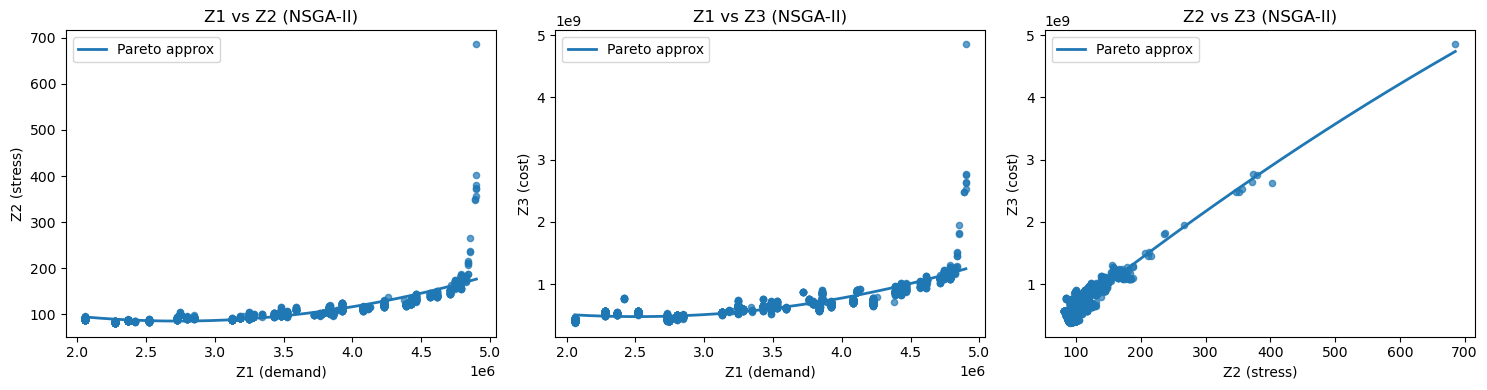

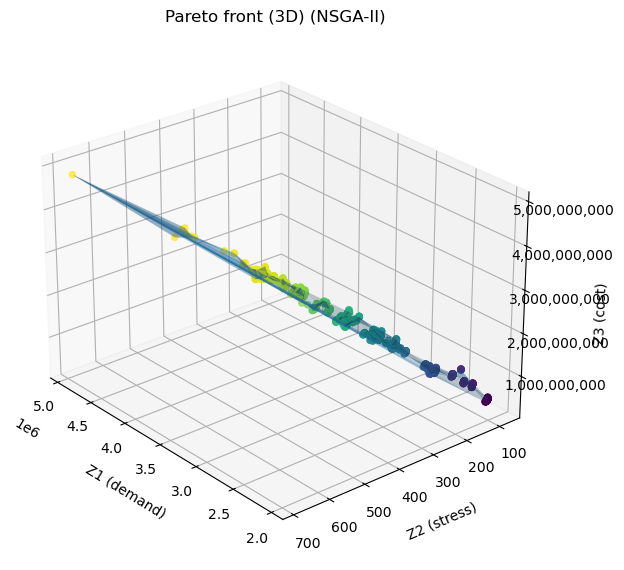

In [34]:
# ============================================================
# B) PLOTS —, but robust when Feasible=0
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from matplotlib.ticker import StrMethodFormatter

df_plot = df_nsga_deap.copy()
title_suffix = " (NSGA-II)"

df_plot = df_plot.dropna(subset=["Z1_demand","Z2_stress","Z3_cost","cv"]).copy()

if df_plot["ok"].sum() > 0:
    plot_df = df_plot[df_plot["ok"]].copy()
    print("Plotting feasible solutions:", len(plot_df))
else:
    # no feasible → plot the least-violating solutions
    K = min(200, len(df_plot))
    plot_df = df_plot.sort_values(["cv", "Z1_demand"], ascending=[True, False]).head(K).copy()
    print("Feasible=0 → plotting top", len(plot_df), "solutions with smallest cv")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

def _plot_with_fit(ax, x, y, xlabel, ylabel, title):
    ax.scatter(x, y, s=20, alpha=0.7)
    if len(x) >= 8:
        order = np.argsort(x)
        xs = np.asarray(x)[order]
        ys = np.asarray(y)[order]
        coeff = np.polyfit(xs, ys, deg=2)
        xs_fit = np.linspace(xs.min(), xs.max(), 200)
        ys_fit = np.polyval(coeff, xs_fit)
        ax.plot(xs_fit, ys_fit, linewidth=2, label="Pareto approx")
        ax.legend(loc="best")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

_plot_with_fit(axes[0], plot_df["Z1_demand"], plot_df["Z2_stress"],
               "Z1 (demand)", "Z2 (stress)", "Z1 vs Z2" + title_suffix)
_plot_with_fit(axes[1], plot_df["Z1_demand"], plot_df["Z3_cost"],
               "Z1 (demand)", "Z3 (cost)", "Z1 vs Z3" + title_suffix)
_plot_with_fit(axes[2], plot_df["Z2_stress"], plot_df["Z3_cost"],
               "Z2 (stress)", "Z3 (cost)", "Z2 vs Z3" + title_suffix)

plt.tight_layout()
plt.show()

# 3D
fig = plt.figure(figsize=(6.8, 5.8))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(plot_df["Z1_demand"], plot_df["Z2_stress"], plot_df["Z3_cost"],
           s=20, alpha=0.7, c=plot_df["Z1_demand"])

if len(plot_df) >= 10:
    xs = plot_df["Z1_demand"].to_numpy()
    ys = plot_df["Z2_stress"].to_numpy()
    zs = plot_df["Z3_cost"].to_numpy()
    tri = mtri.Triangulation(xs, ys)
    ax.plot_trisurf(tri, zs, alpha=0.25, linewidth=0.2)

if len(plot_df):
    zmin = float(plot_df["Z3_cost"].min())
    zmax = float(plot_df["Z3_cost"].max())
    zpad = max(1.0, 0.08 * (zmax - zmin))
    ax.set_zlim(zmin - zpad, zmax + zpad)

ax.set_xlabel("Z1 (demand)", labelpad=8)
ax.set_ylabel("Z2 (stress)", labelpad=8)
ax.set_zlabel("Z3 (cost)", labelpad=10)
ax.zaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.tick_params(axis="z", pad=6)
ax.set_title("Pareto front (3D)" + title_suffix)
ax.view_init(elev=26, azim=140)
ax.set_box_aspect((1.2, 1.0, 0.8))
plt.tight_layout()
plt.show()


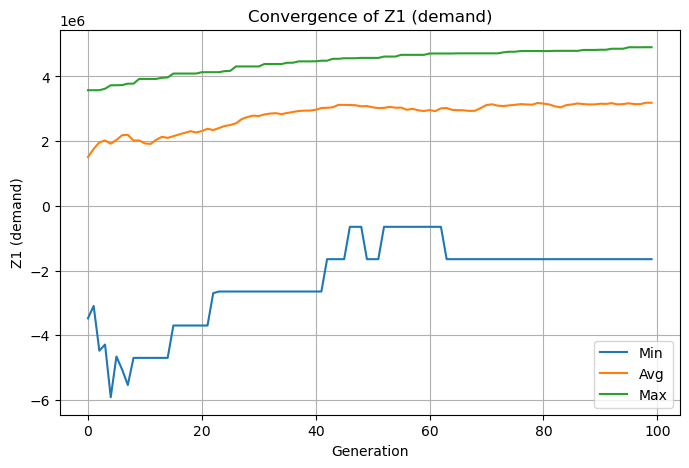

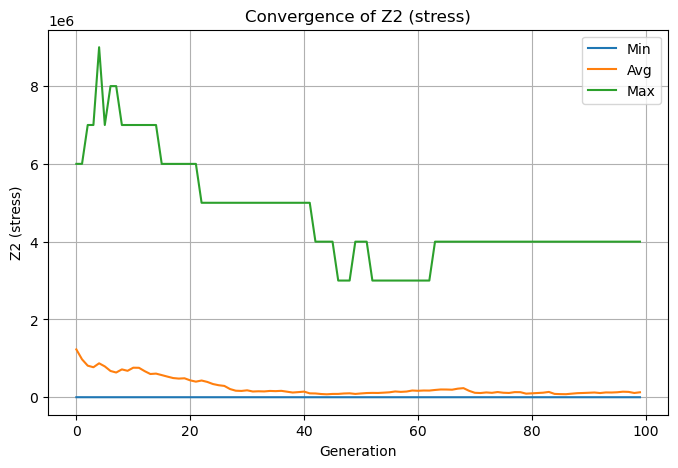

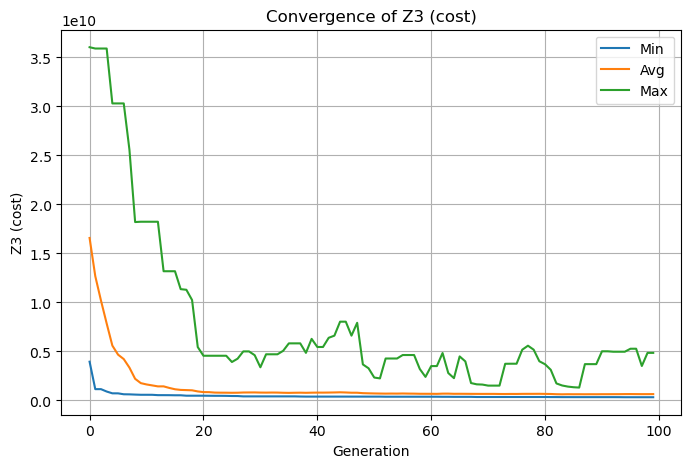

In [35]:
##### Log Plot

# Plot convergence for Z1, Z2, Z3 using logbook
import matplotlib.pyplot as plt

gens = logbook.select("gen")
min_vals = logbook.select("min")
avg_vals = logbook.select("avg")
max_vals = logbook.select("max")

objectives = ["Z1 (demand)", "Z2 (stress)", "Z3 (cost)"]
for i, obj in enumerate(objectives):
    plt.figure(figsize=(8, 5))
    plt.plot(gens, [v[i] for v in min_vals], label="Min")
    plt.plot(gens, [v[i] for v in avg_vals], label="Avg")
    plt.plot(gens, [v[i] for v in max_vals], label="Max")
    plt.xlabel("Generation")
    plt.ylabel(obj)
    plt.title(f"Convergence of {obj}")
    plt.legend()
    plt.grid(True)
    plt.show()

In [45]:
# ============================================================
# C) Choose "balanced" solution (ideal-point distance)
# Works with feasible set or top-K cv set used in plots.
# ============================================================

tmp = plot_df.copy()

# normalize
eps = 1e-9
Z1 = tmp["Z1_demand"].to_numpy()
Z2 = tmp["Z2_stress"].to_numpy()
Z3 = tmp["Z3_cost"].to_numpy()

Z1n = (Z1.max() - Z1) / (Z1.max() - Z1.min() + eps)  # smaller is better (closer to max demand)
Z2n = (Z2 - Z2.min()) / (Z2.max() - Z2.min() + eps)  # smaller is better
Z3n = (Z3 - Z3.min()) / (Z3.max() - Z3.min() + eps)  # smaller is better

dist = np.sqrt(Z1n**2 + Z2n**2 + Z3n**2)
best_idx = int(np.argmin(dist))
balanced_row = tmp.iloc[best_idx]

print("Balanced row (from plot_df):")
print(balanced_row)


Balanced row (from plot_df):
ok                       True
Z1_demand           4613700.0
Z2_stress          138.529549
Z3_cost      941232916.735959
cv                        0.0
Name: 378, dtype: object


### MAPPING (balanced, 3 objective with Min CV)

In [46]:
# Rebuild results table from existing pop with index idx

rows = []
for idx, ind in enumerate(pop):
    y, x, z = _decode(ind)

    Z1 = sum(_D[i] * y[i] for i in _N)
    Z2 = sum(get_LTS(i, j) * x[(i, j)] for (i, j) in _L)
    Z3 = sum(get_Cup(i, j) * x[(i, j)] for (i, j) in _L) + C_dock * sum(z[i] for i in _N)

    if C_station > 0:
        Z3 += C_station * sum(y.values())

    cv = _constraint_violation(y, x, z)

    rows.append({
        "idx": idx,
        "Z1_demand": float(Z1),
        "Z2_stress": float(Z2),
        "Z3_cost": float(Z3),
        "cv": float(cv),
        "ok": cv == 0
    })

df_nsga_full = pd.DataFrame(rows)

print("Rebuilt results table:", len(df_nsga_full))
print("Feasible:", df_nsga_full["ok"].sum())
df_nsga_full.head()

Rebuilt results table: 2000
Feasible: 1881


,idx,Z1_demand,Z2_stress,Z3_cost,cv,ok
0,0,2520866.0,86.769422,5.253054e+08,0.0,True
1,1,2520866.0,86.769422,5.253054e+08,0.0,True
2,2,2520866.0,86.769422,5.253054e+08,0.0,True
3,3,2520866.0,86.769422,5.253054e+08,0.0,True
4,4,2520866.0,86.769422,5.253054e+08,0.0,True


In [47]:
import numpy as np
import pandas as pd

# ----------------------------
# Choose candidate pool:
# - if feasible exists -> use feasible
# - else -> use top-K lowest cv
# ----------------------------
# Use df_nsga_full (it has idx)
if df_nsga_full["ok"].sum() > 0:
    pool = df_nsga_full[df_nsga_full["ok"]].copy()
    print("Selection pool = feasible:", len(pool))
else:
    K = min(300, len(df_nsga_full))
    pool = df_nsga_full.sort_values(["cv", "Z1_demand"], ascending=[True, False]).head(K).copy()
    print("Selection pool = top", len(pool), "lowest-cv solutions (no feasible).")

def pick_by_key(pool_df, key_cols, ascending_list):
    row = pool_df.sort_values(key_cols, ascending=ascending_list).iloc[0]
    ind = pop[int(row["idx"])]
    y, x, z = _decode(ind)
    return row, ind, y, x, z

# 1) Smallest CV + max demand
row_dem, ind_dem, y_dem, x_dem, z_dem = pick_by_key(
    pool, ["cv", "Z1_demand", "Z2_stress", "Z3_cost"], [True, False, True, True]
)

# 2) Smallest CV + min stress
row_str, ind_str, y_str, x_str, z_str = pick_by_key(
    pool, ["cv", "Z2_stress", "Z3_cost", "Z1_demand"], [True, True, True, False]
)

# 3) Smallest CV + min cost
row_cost, ind_cost, y_cost, x_cost, z_cost = pick_by_key(
    pool, ["cv", "Z3_cost", "Z2_stress", "Z1_demand"], [True, True, True, False]
)

# 4) Balanced (ideal-point distance) within the same pool
eps = 1e-9
Z1 = pool["Z1_demand"].to_numpy()
Z2 = pool["Z2_stress"].to_numpy()
Z3 = pool["Z3_cost"].to_numpy()

# normalize so "smaller is better" for distance
Z1n = (Z1.max() - Z1) / (Z1.max() - Z1.min() + eps)  # closer to max demand => smaller
Z2n = (Z2 - Z2.min()) / (Z2.max() - Z2.min() + eps)
Z3n = (Z3 - Z3.min()) / (Z3.max() - Z3.min() + eps)

dist = np.sqrt(Z1n**2 + Z2n**2 + Z3n**2)
balanced_row = pool.iloc[int(np.argmin(dist))]

ind_bal = pop[int(balanced_row["idx"])]
y_bal, x_bal, z_bal = _decode(ind_bal)

print("\nSelected solutions:")
print(" BestDemand:", dict(row_dem))
print(" BestStress:", dict(row_str))
print(" BestCost:  ", dict(row_cost))
print(" Balanced:  ", dict(balanced_row))

# ----------------------------
# Pack all solutions (for mapping + saving)
# ----------------------------
solutions = {
    "BestDemand": (row_dem, y_dem, x_dem, z_dem),
    "BestStress": (row_str, y_str, x_str, z_str),
    "BestCost":   (row_cost, y_cost, x_cost, z_cost),
    "Balanced":   (balanced_row, y_bal, x_bal, z_bal),
}

# ----------------------------
# Save CSVs for each solution
# ----------------------------
# def save_solution_csvs(label, y_sol, x_sol, z_sol, prefix="nsga"):
#     selected_stations = [i for i in _N if y_sol[i] == 1]
#     selected_links = [(i, j) for (i, j) in _L if x_sol[(i, j)] == 1]

#     stations_sel_df = pd.DataFrame({
#         "node": selected_stations,
#         "demand": [float(_D[i]) for i in selected_stations],
#         "z_capacity": [float(z_sol[i]) for i in selected_stations],
#     })
#     links_sel_df = pd.DataFrame({
#         "from_node": [e[0] for e in selected_links],
#         "to_node":   [e[1] for e in selected_links],
#         "lts":       [float(get_LTS(e[0], e[1])) for e in selected_links],
#         "cost_up":   [float(get_Cup(e[0], e[1])) for e in selected_links],
#     })

#     stations_csv = f"{solution_label}_{prefix}_{label}_stations.csv"
#     links_csv    = f"{solution_label}_{prefix}_{label}_links.csv"
#     stations_sel_df.to_csv(stations_csv, index=False)
#     links_sel_df.to_csv(links_csv, index=False)
#     print("Saved CSVs:", stations_csv, links_csv)

# for label, (_, y_sol, x_sol, z_sol) in solutions.items():
#     save_solution_csvs(label, y_sol, x_sol, z_sol)

Selection pool = feasible: 1881

Selected solutions:
 BestDemand: {'idx': np.int64(466), 'Z1_demand': np.float64(4902163.0), 'Z2_stress': np.float64(685.6253145752298), 'Z3_cost': np.float64(4855550325.428382), 'cv': np.float64(0.0), 'ok': np.True_}
 BestStress: {'idx': np.int64(90), 'Z1_demand': np.float64(2277449.0), 'Z2_stress': np.float64(81.93003931355643), 'Z3_cost': np.float64(560522699.907095), 'cv': np.float64(0.0), 'ok': np.True_}
 BestCost:   {'idx': np.int64(462), 'Z1_demand': np.float64(2059613.0), 'Z2_stress': np.float64(90.74565994474567), 'Z3_cost': np.float64(376460656.84222966), 'cv': np.float64(0.0), 'ok': np.True_}
 Balanced:   {'idx': np.int64(378), 'Z1_demand': np.float64(4613700.0), 'Z2_stress': np.float64(138.52954855965945), 'Z3_cost': np.float64(941232916.7359587), 'cv': np.float64(0.0), 'ok': np.True_}


In [49]:
import pandas as pd

# ------------------------------------------------------------
# Summary table for the 4 representative solutions (Table 4)
# Requires: `solutions` dict already created above
# ------------------------------------------------------------

# (Optional) ensure solution_label exists for saving outputs later
if "solution_label" not in globals():
    # simple safe prefix; adjust if you want
    solution_label = "nsga_run"

summary_rows = []

for label, (row, y_sol, x_sol, z_sol) in solutions.items():
    n_stations = int(sum(y_sol.values()))
    n_links    = int(sum(x_sol.values()))

    summary_rows.append({
        "Solution": label,
        "Selected Stations": n_stations,
        "Selected Links": n_links,
        "Z1_demand": float(row["Z1_demand"]),
        "Z2_stress": float(row["Z2_stress"]),
        "Z3_cost": float(row["Z3_cost"]),
        "cv": float(row["cv"]),
    })

df_solution_summary = pd.DataFrame(summary_rows)

# Optional: reorder to match your paper table style
order = ["BestDemand", "BestStress", "BestCost", "Balanced"]
df_solution_summary["Solution"] = pd.Categorical(df_solution_summary["Solution"], categories=order, ordered=True)
df_solution_summary = df_solution_summary.sort_values("Solution").reset_index(drop=True)

# Optional: pretty names for the paper
name_map = {
    "BestDemand": "Best Demand",
    "BestStress": "Best Stress",
    "BestCost":   "Best Cost",
    "Balanced":   "Balanced"
}
df_solution_summary["Solution"] = df_solution_summary["Solution"].map(name_map)

df_solution_summary

,Solution,Selected Stations,Selected Links,Z1_demand,Z2_stress,Z3_cost,cv
0,Best Demand,100,343,4902163.0,685.625315,4.855550e+09,0.0
1,Best Stress,44,50,2277449.0,81.930039,5.605227e+08,0.0
2,Best Cost,46,50,2059613.0,90.745660,3.764607e+08,0.0
3,Balanced,93,72,4613700.0,138.529549,9.412329e+08,0.0


In [48]:
import folium
import pyproj
import networkx as nx
from folium import Element

# ---- Build lookup tables from candidates_with_station_gdf (if available) ----
# Works if nodes are candidate IDs and you have:
#  - candidate_id
#  - graph_node (tuple)
#  - geometry (Point)
cand_gdf = None
if "candidates_with_station_gdf" in globals():
    cand_gdf = candidates_with_station_gdf.copy()

node_to_geom_xy = {}
node_to_graphnode = {}

if cand_gdf is not None:
    # decide what the node-id column is
    if "candidate_id" in cand_gdf.columns:
        id_col = "candidate_id"
    elif "node" in cand_gdf.columns:
        id_col = "node"
    else:
        id_col = None

    if id_col is not None:
        # Ensure CRS exists
        if cand_gdf.crs is None:
            raise ValueError("candidates_with_station_gdf CRS is None. Needed for mapping.")
        for _, r in cand_gdf.iterrows():
            nid = r[id_col]
            if hasattr(r, "geometry") and r.geometry is not None:
                node_to_geom_xy[nid] = (float(r.geometry.x), float(r.geometry.y))
            if "graph_node" in cand_gdf.columns:
                node_to_graphnode[nid] = r["graph_node"]

# ---- Transformer: use candidates CRS -> 4326 if possible ----
if cand_gdf is not None and cand_gdf.crs is not None:
    t_to_4326 = pyproj.Transformer.from_crs(cand_gdf.crs, "EPSG:4326", always_xy=True)
else:
    # Fallback: try 32618 -> 4326 (common for Montreal in your pipeline)
    t_to_4326 = pyproj.Transformer.from_crs("EPSG:32618", "EPSG:4326", always_xy=True)

def xy_to_latlon(x, y):
    lon, lat = t_to_4326.transform(float(x), float(y))
    return [lat, lon]

def node_to_xy(node):
    """Return (x,y) in the same CRS as cand_gdf for station plotting."""
    # case A: node is already (x,y)
    if isinstance(node, tuple) and len(node) == 2 and all(isinstance(v, (int, float, np.number)) for v in node):
        return (float(node[0]), float(node[1]))
    # case B: node is ID -> use geometry lookup
    if node in node_to_geom_xy:
        return node_to_geom_xy[node]
    # last resort
    raise KeyError(f"Cannot resolve node to coordinates: {node}")

def node_to_graph(node):
    """Return graph node key used by NetworkX shortest_path (often (x,y) tuple)."""
    # if node already looks like a graph node (x,y), keep it
    if isinstance(node, tuple) and len(node) == 2 and all(isinstance(v, (int, float, np.number)) for v in node):
        return (float(node[0]), float(node[1]))
    # if ID, map to graph_node
    if node in node_to_graphnode:
        return node_to_graphnode[node]
    # if no graph mapping, try using xy
    return node_to_xy(node)

def make_map_for_solution(label, y_sol, x_sol, z_sol, row_summary):
    selected_stations = [i for i in _N if y_sol[i] == 1]
    selected_links = [(i, j) for (i, j) in _L if x_sol[(i, j)] == 1]

    # Center map
    if cand_gdf is not None:
        cand_4326 = cand_gdf.to_crs(epsg=4326)
        center = [cand_4326.geometry.y.mean(), cand_4326.geometry.x.mean()]
    else:
        # fallback center from selected stations
        xy0 = node_to_xy(selected_stations[0]) if selected_stations else (0, 0)
        center = xy_to_latlon(xy0[0], xy0[1])

    m = folium.Map(location=center, zoom_start=12, tiles="CartoDB positron")

    # stations
    for n in selected_stations:
        x, y = node_to_xy(n)
        latlon = xy_to_latlon(x, y)
        folium.CircleMarker(
            location=latlon,
            radius=7,
            color="black",
            weight=2,
            fill=True,
            fill_color="limegreen",
            fill_opacity=0.95,
            popup=f"{label} | node={n} | demand={_D.get(n, None)} | z={z_sol.get(n, None)}"
        ).add_to(m)

    # links drawn via shortest path on G (using graph-node endpoints)
    failed = 0
    for a, b in selected_links:
        u = node_to_graph(a)
        v = node_to_graph(b)
        try:
            path = nx.shortest_path(G, u, v, weight="length")
            coords = [xy_to_latlon(x, y) for (x, y) in path]
            folium.PolyLine(coords, color="royalblue", weight=5, opacity=0.85).add_to(m)
        except Exception:
            failed += 1

    legend_html = f"""
    <div style="position:fixed;bottom:50px;left:50px;width:330px;z-index:9999;font-size:14px;
    background-color:rgba(255,255,255,0.92);border:2px solid grey;border-radius:8px;padding:10px;">
    <b>{label}</b><br>
    cv={row_summary["cv"]:.2f} | Z1={row_summary["Z1_demand"]:.0f} | Z2={row_summary["Z2_stress"]:.1f} | Z3={row_summary["Z3_cost"]:.0f}<br><br>
    <span style="display:inline-block;width:16px;height:16px;background:limegreen;border-radius:50%;
    margin-right:8px;border:2px solid black;"></span> Selected station<br>
    <span style="display:inline-block;width:22px;height:6px;background:royalblue;margin-right:8px;"></span> Selected link<br>
    Failed shortest paths: {failed}
    </div>
    """
    m.get_root().html.add_child(Element(legend_html))

    out_html = f"{solution_label}_nsga_{label}_map.html"
    m.save(out_html)
    print("Saved map:", out_html, "| failed paths:", failed)
    return m

# ---- Generate 4 maps ----
maps = {}
for label, (row, y_sol, x_sol, z_sol) in solutions.items():
    row_summary = {
        "cv": float(row["cv"]),
        "Z1_demand": float(row["Z1_demand"]),
        "Z2_stress": float(row["Z2_stress"]),
        "Z3_cost": float(row["Z3_cost"]),
    }
    maps[label] = make_map_for_solution(label, y_sol, x_sol, z_sol, row_summary)
    display(maps[label])

Saved map: m<folium.folium.Map object at 0x176090750>_nsga_BestDemand_map.html | failed paths: 0


Saved map: m<folium.folium.Map object at 0x176090750>_nsga_BestStress_map.html | failed paths: 0


Saved map: m<folium.folium.Map object at 0x176090750>_nsga_BestCost_map.html | failed paths: 0


Saved map: m<folium.folium.Map object at 0x176090750>_nsga_Balanced_map.html | failed paths: 0


### Sensitivity Analysis (RUNNING Approaches)

In [43]:
print("S_min =", data.get("S_min"))
print("M_min =", data.get("M_min"))
print("D_min =", data.get("D_min"))

S_min = 15
M_min = 50
D_min = 0.0


In [52]:
from deap import tools as deap_tools
import random
import numpy as np
import pandas as pd
from tqdm import tqdm

def run_one_nsga_scenario(
    *,                        # force keyword arguments (prevents mistakes)
    S_min=None,
    M_min=None,
    D_min=None,
    pop_size=200,
    n_gen=80,
    cxpb=0.9,
    mutpb=0.2,
    seed=42,
    verbose=True,
):
    """
    Runs YOUR existing DEAP NSGA-II loop for one scenario.
    You can override S_min / M_min / D_min and NSGA parameters (pop/gen/rates/seed).
    Returns: df_run, pop_run, logbook
    """
    global _S_min, _M_min, _D_min

    # --- set scenario constraint values ---
    if S_min is not None:
        _S_min = int(S_min)
    if M_min is not None:
        _M_min = int(M_min)
    if D_min is not None:
        _D_min = float(D_min)

    # --- reset randomness for reproducibility per scenario ---
    random.seed(seed)
    np.random.seed(seed)

    # --- initialize population ---
    pop = toolbox.population(n=pop_size)
    for ind in pop:
        _repair(ind)

    invalid = [ind for ind in pop if not ind.fitness.valid]
    for ind in invalid:
        ind.fitness.values = toolbox.evaluate(ind)

    # critical for NSGA-II: assign crowding distance
    pop = toolbox.select(pop, len(pop))

    # --- logbook ---
    logbook = deap_tools.Logbook()
    logbook.header = ["gen", "nevals", "min", "max", "avg"]

    desc = f"NSGA-II (S={_S_min}, M={_M_min}, D={_D_min}) POP={pop_size} GEN={n_gen}"
    for gen in tqdm(range(n_gen), desc=desc, unit="gen", disable=(not verbose)):
        # mating selection
        offspring = deap_tools.selTournamentDCD(pop, len(pop))
        offspring = [toolbox.clone(ind) for ind in offspring]

        # crossover
        for ind1, ind2 in zip(offspring[::2], offspring[1::2]):
            if random.random() < cxpb:
                toolbox.mate(ind1, ind2)
                del ind1.fitness.values, ind2.fitness.values

        # mutation (uses your toolbox.mutate which already calls _repair)
        for ind in offspring:
            if random.random() < mutpb:
                toolbox.mutate(ind)
                del ind.fitness.values

        # evaluate
        invalid = [ind for ind in offspring if not ind.fitness.valid]
        for ind in invalid:
            ind.fitness.values = toolbox.evaluate(ind)

        # survival selection (NSGA-II)
        pop = toolbox.select(pop + offspring, pop_size)

        # log stats on fitness values (penalized fitness)
        fits = np.array([ind.fitness.values for ind in pop], dtype=float)
        logbook.record(
            gen=gen,
            nevals=len(invalid),
            min=np.min(fits, axis=0),
            max=np.max(fits, axis=0),
            avg=np.mean(fits, axis=0),
        )

    # --- build TRUE objective table (no penalty in Zs) ---
    rows = []
    for ind in pop:
        y, x, z = _decode(ind)

        Z1 = sum(_D[i] * y[i] for i in _N)
        Z2 = sum(get_LTS(i, j) * x[(i, j)] for (i, j) in _L)
        Z3 = sum(get_Cup(i, j) * x[(i, j)] for (i, j) in _L) + C_dock * sum(z[i] for i in _N)
        if C_station > 0:
            Z3 += C_station * sum(y.values())

        cv = _constraint_violation(y, x, z)
        rows.append({"ok": cv == 0, "Z1_demand": Z1, "Z2_stress": Z2, "Z3_cost": Z3, "cv": cv})

    df_run = pd.DataFrame(rows)
    return df_run, pop, logbook

In [54]:
#### Defining function pareto_mask_maxmin //// 
#### df_run contains all final solutions (often many feasible)
#### But sensitivity plots should compare Pareto fronts, not full clouds/// gives the scenario-specific Pareto set


import numpy as np

def pareto_mask_maxmin(df, cols_max, cols_min):
    """
    Return boolean mask for nondominated points.
    cols_max: objectives to maximize (e.g., Z1)
    cols_min: objectives to minimize (e.g., Z2, Z3)
    """
    A = df.copy()

    # Convert max objectives to minimization by negating
    for c in cols_max:
        A[c] = -A[c]

    X = A[cols_max + cols_min].to_numpy(float)
    n = len(X)
    is_nd = np.ones(n, dtype=bool)

    # p dominates q if p<=q in all and p<q in at least one
    for i in range(n):
        if not is_nd[i]:
            continue
        for j in range(n):
            if i == j or not is_nd[j]:
                continue
            if np.all(X[j] <= X[i]) and np.any(X[j] < X[i]):
                is_nd[i] = False
                break
    return is_nd

In [55]:
# ---- Baseline constraint values (from your current run) ----
S0 = _S_min
M0 = _M_min
D0 = _D_min

# ---- Sensitivity grid for S_min ----
S_grid = [42, 45, 50, 60]   # change 

# ---- Sensitivity NSGA settings (separate from baseline) ----
SENS_POP  = 1200
SENS_GEN  = 80
SENS_CXPB = 0.9
SENS_MUTPB= 0.2

scenario_runs = {}
fronts_S = {}
summary_S = []

for S in S_grid:
    df_run, pop_run, log_run = run_one_nsga_scenario(
        S_min=S, M_min=M0, D_min=D0,
        pop_size=SENS_POP,
        n_gen=SENS_GEN,
        cxpb=SENS_CXPB,
        mutpb=SENS_MUTPB,
        seed=42,              # keep fixed first; later we can do multiple seeds
        verbose=True
    )

    feas = df_run[df_run["ok"]].copy()
    if len(feas) > 0:
        mask = pareto_mask_maxmin(feas, ["Z1_demand"], ["Z2_stress","Z3_cost"])
        pf = feas.loc[mask].copy()
    else:
        pf = feas

    scenario_runs[S] = {"df": df_run, "feas": feas, "pareto": pf, "logbook": log_run}
    fronts_S[S] = pf
    summary_S.append({"S_min": S, "total": len(df_run), "feasible": len(feas), "pareto": len(pf)})

pd.DataFrame(summary_S)

NSGA-II (S=60, M=50, D=0.0) POP=1200 GEN=80: 100%|██████████| 80/80 [1:32:33<00:00, 69.42s/gen]   


,S_min,total,feasible,pareto
0,42,1200,1200,276
1,45,1200,964,247
2,50,1200,1069,199
3,60,1200,1013,185


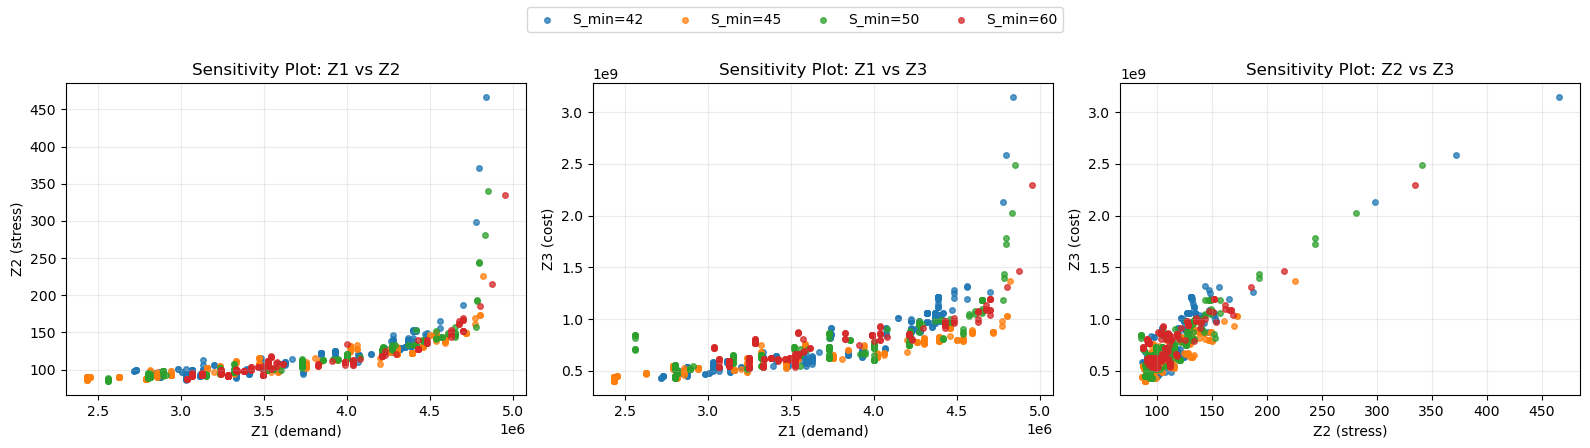

In [60]:
### PLOTS_2D

import matplotlib.pyplot as plt

S_grid_plot = S_grid

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
pairs = [
    ("Z1_demand", "Z2_stress", "Z1 (demand)", "Z2 (stress)", "Z1 vs Z2"),
    ("Z1_demand", "Z3_cost",   "Z1 (demand)", "Z3 (cost)",   "Z1 vs Z3"),
    ("Z2_stress", "Z3_cost",   "Z2 (stress)", "Z3 (cost)",   "Z2 vs Z3"),
]

for ax, (xcol, ycol, xl, yl, title) in zip(axes, pairs):
    for S in S_grid_plot:
        pf = fronts_S.get(S)
        if pf is None or len(pf) == 0:
            continue
        ax.scatter(pf[xcol], pf[ycol], s=16, alpha=0.75, label=f"S_min={S}")
    ax.set_xlabel(xl)
    ax.set_ylabel(yl)
    ax.set_title(f"Sensitivity Plot: {title}")
    ax.grid(True, alpha=0.25)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=len(S_grid_plot), frameon=True)
plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()

In [61]:
### Table for Values 
## 


S_grid = [42, 45, 50, 60]  # same as your scenarios

def summarize_pf(pf):
    # returns dict of summary stats for one Pareto set
    out = {}
    for col in ["Z1_demand", "Z2_stress", "Z3_cost"]:
        out[f"{col}_med"] = float(pf[col].median())
        out[f"{col}_q25"] = float(pf[col].quantile(0.25))
        out[f"{col}_q75"] = float(pf[col].quantile(0.75))

    # “best achievable” (extremes on the Pareto set)
    out["Z1_demand_max"] = float(pf["Z1_demand"].max())
    out["Z2_stress_min"] = float(pf["Z2_stress"].min())
    out["Z3_cost_min"]   = float(pf["Z3_cost"].min())
    return out

rows = []
for S in S_grid:
    pf = fronts_S.get(S)
    if pf is None or len(pf) == 0:
        rows.append({"S_min": S})
        continue
    r = {"S_min": S}
    r.update(summarize_pf(pf))
    rows.append(r)

df_stats = pd.DataFrame(rows).set_index("S_min").sort_index()
df_stats

,Z1_demand_med,Z1_demand_q25,Z1_demand_q75,Z2_stress_med,Z2_stress_q25,Z2_stress_q75,Z3_cost_med,Z3_cost_q25,Z3_cost_q75,Z1_demand_max,Z2_stress_min,Z3_cost_min
S_min,,,,,,,,,,,,
42,3590653.0,3060525.75,4280870.0,106.189003,94.741220,128.703372,6.366287e+08,5.435547e+08,9.695007e+08,4837651.0,86.659852,4.354237e+08
45,3470546.0,2858927.00,4262419.0,103.411809,92.543289,123.328448,5.826513e+08,5.053384e+08,7.688860e+08,4817873.0,86.702324,4.068473e+08
50,3728524.0,2893019.00,4209467.0,104.886079,93.249765,126.831949,6.972989e+08,5.477993e+08,8.440243e+08,4850446.0,85.354411,4.292610e+08
60,3497016.0,3285649.00,4034848.0,102.220183,94.409556,112.437444,7.232318e+08,6.035706e+08,8.438123e+08,4953591.0,87.191622,5.246892e+08


In [66]:
best_table = pd.DataFrame(index=["Max Z1", "Min Z2", "Min Z3"], columns=df_stats.index)

for S in df_stats.index:
    best_table.loc["Max Z1", S] = f"{df_stats.loc[S,'Z1_demand_max']:,.0f}"
    best_table.loc["Min Z2", S] = f"{df_stats.loc[S,'Z2_stress_min']:.2f}"
    best_table.loc["Min Z3", S] = f"{df_stats.loc[S,'Z3_cost_min']:,.0f}"

best_table

S_min,42,45,50,60
Max Z1,"4,837,651","4,817,873","4,850,446","4,953,591"
Min Z2,86.66,86.70,85.35,87.19
Min Z3,"435,423,748","406,847,253","429,260,977","524,689,204"


In [67]:
import pandas as pd

# ---- choose the scenarios you want in columns ----
S_list = list(fronts_S.keys())  # or e.g., [42,45,50,60]

# Build a multiindex table: rows = (Which, Metric), columns = S_min
row_index = pd.MultiIndex.from_product(
    [["Max Z1", "Min Z2", "Min Z3"],
     ["Z1_demand", "Z2_stress", "Z3_cost", "n_nodes", "n_links"]],
    names=["Point", "Metric"]
)

best_table_full = pd.DataFrame(index=row_index, columns=S_list)

for S in S_list:
    pf = fronts_S[S]
    if pf is None or len(pf) == 0:
        continue

    # indices of best-achievable points on the Pareto set
    idx_maxZ1 = pf["Z1_demand"].idxmax()
    idx_minZ2 = pf["Z2_stress"].idxmin()
    idx_minZ3 = pf["Z3_cost"].idxmin()

    def fill(which, idx):
        r = pf.loc[idx]
        best_table_full.loc[(which, "Z1_demand"), S] = float(r["Z1_demand"])
        best_table_full.loc[(which, "Z2_stress"), S] = float(r["Z2_stress"])
        best_table_full.loc[(which, "Z3_cost"),   S] = float(r["Z3_cost"])
        best_table_full.loc[(which, "n_nodes"),   S] = int(r["n_nodes"])
        best_table_full.loc[(which, "n_links"),   S] = int(r["n_links"])

    fill("Max Z1", idx_maxZ1)
    fill("Min Z2", idx_minZ2)
    fill("Min Z3", idx_minZ3)

# ---- optional: nicer formatting for display ----
best_table_display = best_table_full.copy()

# format columns
for S in S_list:
    for which in ["Max Z1", "Min Z2", "Min Z3"]:
        v = best_table_display.loc[(which, "Z1_demand"), S]
        if pd.notna(v): best_table_display.loc[(which, "Z1_demand"), S] = f"{v:,.0f}"

        v = best_table_display.loc[(which, "Z2_stress"), S]
        if pd.notna(v): best_table_display.loc[(which, "Z2_stress"), S] = f"{v:,.2f}"

        v = best_table_display.loc[(which, "Z3_cost"), S]
        if pd.notna(v): best_table_display.loc[(which, "Z3_cost"), S] = f"{v:,.0f}"

        v = best_table_display.loc[(which, "n_nodes"), S]
        if pd.notna(v): best_table_display.loc[(which, "n_nodes"), S] = f"{int(v)}"

        v = best_table_display.loc[(which, "n_links"), S]
        if pd.notna(v): best_table_display.loc[(which, "n_links"), S] = f"{int(v)}"

best_table_display

KeyError: 'n_nodes'

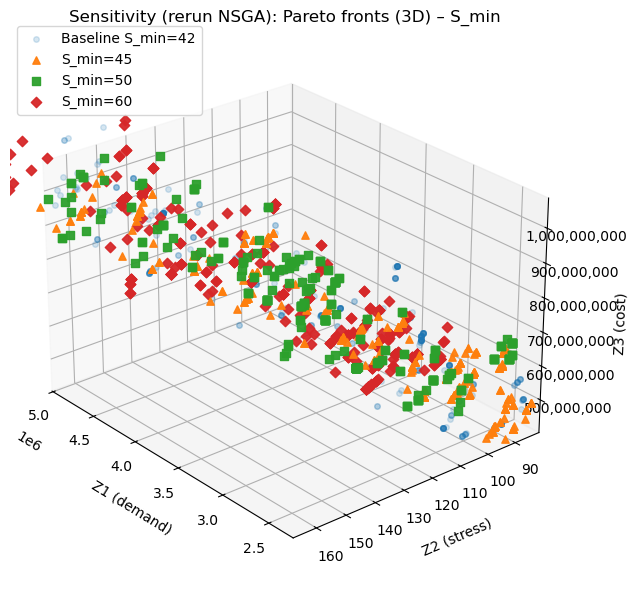

In [144]:
### Plots_ 3D

from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from matplotlib.ticker import StrMethodFormatter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

baseline_S = S_grid_plot[0]

all_pf = pd.concat(
    [fronts_S[S][["Z1_demand","Z2_stress","Z3_cost"]] for S in S_grid_plot if len(fronts_S[S])],
    ignore_index=True
)

qlo, qhi = 0.02, 0.98
def lim(s):
    lo = float(s.quantile(qlo)); hi = float(s.quantile(qhi))
    pad = 0.03 * (hi - lo + 1e-12)
    return lo - pad, hi + pad

xlim = lim(all_pf["Z1_demand"])
ylim = lim(all_pf["Z2_stress"])
zlim = lim(all_pf["Z3_cost"])

fig = plt.figure(figsize=(7.2, 6.0))
ax = fig.add_subplot(111, projection="3d")

markers = ["o","^","s","D","P","X","v"]
mark_map = {S: markers[i % len(markers)] for i, S in enumerate(S_grid_plot)}

# baseline first (faded)
pf0 = fronts_S[baseline_S]
ax.scatter(pf0["Z1_demand"], pf0["Z2_stress"], pf0["Z3_cost"],
           s=16, alpha=0.18, marker=mark_map[baseline_S],
           label=f"Baseline S_min={baseline_S}", depthshade=False)

# others on top
for S in S_grid_plot:
    if S == baseline_S:
        continue
    pf = fronts_S[S]
    if len(pf) == 0:
        continue
    ax.scatter(pf["Z1_demand"], pf["Z2_stress"], pf["Z3_cost"],
               s=28, alpha=0.95, marker=mark_map[S],
               label=f"S_min={S}", depthshade=False)

ax.set_xlim(*xlim); ax.set_ylim(*ylim); ax.set_zlim(*zlim)
ax.set_xlabel("Z1 (demand)", labelpad=8)
ax.set_ylabel("Z2 (stress)", labelpad=8)
ax.set_zlabel("Z3 (cost)", labelpad=10)
ax.zaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.set_title("Sensitivity (rerun NSGA): Pareto fronts (3D) – S_min")
ax.view_init(elev=26, azim=140)
ax.set_box_aspect((1.2, 1.0, 0.8))
ax.legend(loc="upper left", bbox_to_anchor=(0.0, 1.02))

plt.tight_layout()
plt.show()

In [1]:
### Plots_ 3D

from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from matplotlib.ticker import StrMethodFormatter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

baseline_S = S_grid_plot[0]

all_pf = pd.concat(
    [fronts_S[S][["Z1_demand","Z2_stress","Z3_cost"]] for S in S_grid_plot if len(fronts_S[S])],
    ignore_index=True
)

qlo, qhi = 0.02, 0.98
def lim(s):
    lo = float(s.quantile(qlo)); hi = float(s.quantile(qhi))
    pad = 0.03 * (hi - lo + 1e-12)
    return lo - pad, hi + pad

xlim = lim(all_pf["Z1_demand"])
ylim = lim(all_pf["Z2_stress"])
zlim = lim(all_pf["Z3_cost"])

fig = plt.figure(figsize=(7.2, 6.0))
ax = fig.add_subplot(111, projection="3d")

markers = ["o","^","s","D","P","X","v"]
mark_map = {S: markers[i % len(markers)] for i, S in enumerate(S_grid_plot)}

# baseline first (faded)
pf0 = fronts_S[baseline_S]
ax.scatter(pf0["Z1_demand"], pf0["Z2_stress"], pf0["Z3_cost"],
           s=16, alpha=0.18, marker=mark_map[baseline_S],
           label=f"Baseline S_min={baseline_S}", depthshade=False)

# others on top
for S in S_grid_plot:
    if S == baseline_S:
        continue
    pf = fronts_S[S]
    if len(pf) == 0:
        continue
    ax.scatter(pf["Z1_demand"], pf["Z2_stress"], pf["Z3_cost"],
               s=28, alpha=0.95, marker=mark_map[S],
               label=f"S_min={S}", depthshade=False)

ax.set_xlim(*xlim); ax.set_ylim(*ylim); ax.set_zlim(*zlim)
ax.set_xlabel("Z1 (demand)", labelpad=8)
ax.set_ylabel("Z2 (stress)", labelpad=8)
ax.set_zlabel("Z3 (cost)", labelpad=10)
ax.zaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.set_title("Sensitivity (rerun NSGA): Pareto fronts (3D) – S_min")
ax.view_init(elev=26, azim=140)
ax.set_box_aspect((1.2, 1.0, 0.8))
ax.legend(loc="upper left", bbox_to_anchor=(0.0, 1.02))

plt.tight_layout()
plt.show()

NameError: name 'S_grid_plot' is not defined

In [145]:
from deap import tools as deap_tools
import random
import numpy as np
import pandas as pd
from tqdm import tqdm

def run_one_nsga_scenario(
    *,                        # force keyword arguments (prevents mistakes)
    S_min=None,
    M_min=None,
    D_min=None,
    pop_size=200,
    n_gen=80,
    cxpb=0.9,
    mutpb=0.2,
    seed=42,
    verbose=True,
):
    """
    Runs YOUR existing DEAP NSGA-II loop for one scenario.
    You can override S_min / M_min / D_min and NSGA parameters (pop/gen/rates/seed).
    Returns: df_run, pop_run, logbook
    """
    global _S_min, _M_min, _D_min

    # --- set scenario constraint values ---
    if S_min is not None:
        _S_min = int(S_min)
    if M_min is not None:
        _M_min = int(M_min)
    if D_min is not None:
        _D_min = float(D_min)

    # --- reset randomness for reproducibility per scenario ---
    random.seed(seed)
    np.random.seed(seed)

    # --- initialize population ---
    pop = toolbox.population(n=pop_size)
    for ind in pop:
        _repair(ind)

    invalid = [ind for ind in pop if not ind.fitness.valid]
    for ind in invalid:
        ind.fitness.values = toolbox.evaluate(ind)

    # critical for NSGA-II: assign crowding distance
    pop = toolbox.select(pop, len(pop))

    # --- logbook ---
    logbook = deap_tools.Logbook()
    logbook.header = ["gen", "nevals", "min", "max", "avg"]

    desc = f"NSGA-II (S={_S_min}, M={_M_min}, D={_D_min}) POP={pop_size} GEN={n_gen}"
    for gen in tqdm(range(n_gen), desc=desc, unit="gen", disable=(not verbose)):
        # mating selection
        offspring = deap_tools.selTournamentDCD(pop, len(pop))
        offspring = [toolbox.clone(ind) for ind in offspring]

        # crossover
        for ind1, ind2 in zip(offspring[::2], offspring[1::2]):
            if random.random() < cxpb:
                toolbox.mate(ind1, ind2)
                del ind1.fitness.values, ind2.fitness.values

        # mutation (uses your toolbox.mutate which already calls _repair)
        for ind in offspring:
            if random.random() < mutpb:
                toolbox.mutate(ind)
                del ind.fitness.values

        # evaluate
        invalid = [ind for ind in offspring if not ind.fitness.valid]
        for ind in invalid:
            ind.fitness.values = toolbox.evaluate(ind)

        # survival selection (NSGA-II)
        pop = toolbox.select(pop + offspring, pop_size)

        # log stats on fitness values (penalized fitness)
        fits = np.array([ind.fitness.values for ind in pop], dtype=float)
        logbook.record(
            gen=gen,
            nevals=len(invalid),
            min=np.min(fits, axis=0),
            max=np.max(fits, axis=0),
            avg=np.mean(fits, axis=0),
        )

    # --- build TRUE objective table (no penalty in Zs) ---
    rows = []
    for ind in pop:
        y, x, z = _decode(ind)

        Z1 = sum(_D[i] * y[i] for i in _N)
        Z2 = sum(get_LTS(i, j) * x[(i, j)] for (i, j) in _L)
        Z3 = sum(get_Cup(i, j) * x[(i, j)] for (i, j) in _L) + C_dock * sum(z[i] for i in _N)
        if C_station > 0:
            Z3 += C_station * sum(y.values())

        cv = _constraint_violation(y, x, z)
        rows.append({"ok": cv == 0, "Z1_demand": Z1, "Z2_stress": Z2, "Z3_cost": Z3, "cv": cv})

    df_run = pd.DataFrame(rows)
    return df_run, pop, logbook

In [146]:
# ---- Baseline constraint values (from your current run) ----
S0 = _S_min
M0 = _M_min
D0 = _D_min

# ---- Sensitivity grid for S_min ----
S_grid = [30, 50, 60, 80, 100]   # change 

# ---- Sensitivity NSGA settings (separate from baseline) ----
SENS_POP  = 1200
SENS_GEN  = 80
SENS_CXPB = 0.9
SENS_MUTPB= 0.2

scenario_runs = {}
fronts_S = {}
summary_S = []

for S in S_grid:
    df_run, pop_run, log_run = run_one_nsga_scenario(
        S_min=S, M_min=M0, D_min=D0,
        pop_size=SENS_POP,
        n_gen=SENS_GEN,
        cxpb=SENS_CXPB,
        mutpb=SENS_MUTPB,
        seed=42,              # keep fixed first; later we can do multiple seeds
        verbose=True
    )

    feas = df_run[df_run["ok"]].copy()
    if len(feas) > 0:
        mask = pareto_mask_maxmin(feas, ["Z1_demand"], ["Z2_stress","Z3_cost"])
        pf = feas.loc[mask].copy()
    else:
        pf = feas

    scenario_runs[S] = {"df": df_run, "feas": feas, "pareto": pf, "logbook": log_run}
    fronts_S[S] = pf
    summary_S.append({"S_min": S, "total": len(df_run), "feasible": len(feas), "pareto": len(pf)})

pd.DataFrame(summary_S)

NSGA-II (S=100, M=50, D=0.0) POP=1200 GEN=80: 100%|██████████| 80/80 [2:52:44<00:00, 129.55s/gen]  


,S_min,total,feasible,pareto
0,30,1200,1200,251
1,50,1200,1138,254
2,60,1200,1200,304
3,80,1200,1125,128
4,100,1200,1182,60


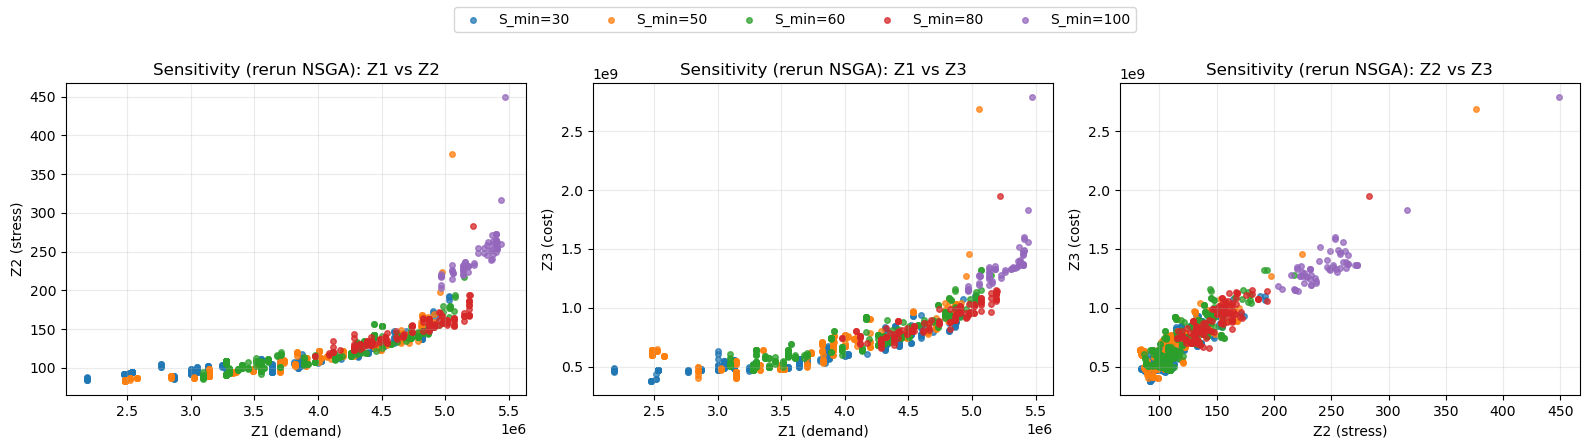

In [147]:
### PLOTS_2D

import matplotlib.pyplot as plt

S_grid_plot = S_grid

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
pairs = [
    ("Z1_demand", "Z2_stress", "Z1 (demand)", "Z2 (stress)", "Z1 vs Z2"),
    ("Z1_demand", "Z3_cost",   "Z1 (demand)", "Z3 (cost)",   "Z1 vs Z3"),
    ("Z2_stress", "Z3_cost",   "Z2 (stress)", "Z3 (cost)",   "Z2 vs Z3"),
]

for ax, (xcol, ycol, xl, yl, title) in zip(axes, pairs):
    for S in S_grid_plot:
        pf = fronts_S.get(S)
        if pf is None or len(pf) == 0:
            continue
        ax.scatter(pf[xcol], pf[ycol], s=16, alpha=0.75, label=f"S_min={S}")
    ax.set_xlabel(xl)
    ax.set_ylabel(yl)
    ax.set_title(f"Sensitivity (rerun NSGA): {title}")
    ax.grid(True, alpha=0.25)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=len(S_grid_plot), frameon=True)
plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()

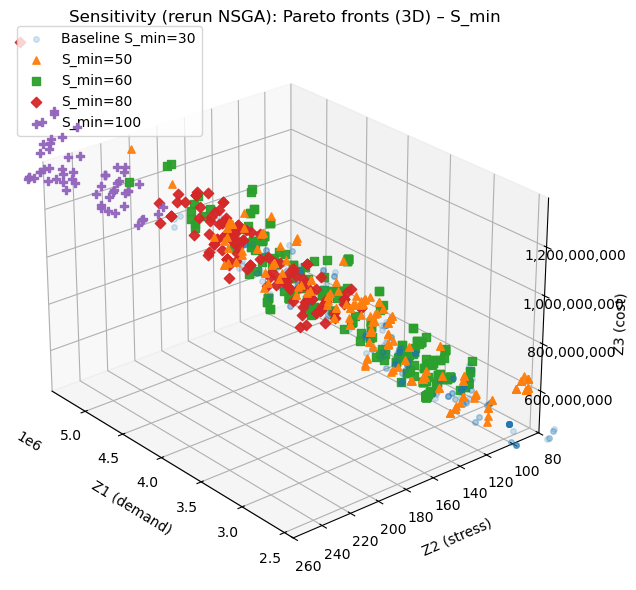

In [148]:
### Plots_ 3D

from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from matplotlib.ticker import StrMethodFormatter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

baseline_S = S_grid_plot[0]

all_pf = pd.concat(
    [fronts_S[S][["Z1_demand","Z2_stress","Z3_cost"]] for S in S_grid_plot if len(fronts_S[S])],
    ignore_index=True
)

qlo, qhi = 0.02, 0.98
def lim(s):
    lo = float(s.quantile(qlo)); hi = float(s.quantile(qhi))
    pad = 0.03 * (hi - lo + 1e-12)
    return lo - pad, hi + pad

xlim = lim(all_pf["Z1_demand"])
ylim = lim(all_pf["Z2_stress"])
zlim = lim(all_pf["Z3_cost"])

fig = plt.figure(figsize=(7.2, 6.0))
ax = fig.add_subplot(111, projection="3d")

markers = ["o","^","s","D","P","X","v"]
mark_map = {S: markers[i % len(markers)] for i, S in enumerate(S_grid_plot)}

# baseline first (faded)
pf0 = fronts_S[baseline_S]
ax.scatter(pf0["Z1_demand"], pf0["Z2_stress"], pf0["Z3_cost"],
           s=16, alpha=0.18, marker=mark_map[baseline_S],
           label=f"Baseline S_min={baseline_S}", depthshade=False)

# others on top
for S in S_grid_plot:
    if S == baseline_S:
        continue
    pf = fronts_S[S]
    if len(pf) == 0:
        continue
    ax.scatter(pf["Z1_demand"], pf["Z2_stress"], pf["Z3_cost"],
               s=28, alpha=0.95, marker=mark_map[S],
               label=f"S_min={S}", depthshade=False)

ax.set_xlim(*xlim); ax.set_ylim(*ylim); ax.set_zlim(*zlim)
ax.set_xlabel("Z1 (demand)", labelpad=8)
ax.set_ylabel("Z2 (stress)", labelpad=8)
ax.set_zlabel("Z3 (cost)", labelpad=10)
ax.zaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.set_title("Sensitivity (rerun NSGA): Pareto fronts (3D) – S_min")
ax.view_init(elev=26, azim=140)
ax.set_box_aspect((1.2, 1.0, 0.8))
ax.legend(loc="upper left", bbox_to_anchor=(0.0, 1.02))

plt.tight_layout()
plt.show()

### Sensitivity Analysis _ Min_Links 

In [68]:
print("S_min =", data.get("S_min"))
print("M_min =", data.get("M_min"))
print("D_min =", data.get("D_min"))

S_min = 15
M_min = 50
D_min = 0.0


In [71]:
# ---- Baseline constraint values ----
S0 = _S_min
M0 = _M_min
D0 = _D_min

print("Baseline S0, M0, D0 =", S0, M0, D0)

# ---- Sensitivity grid for M_min (Min Links) ----
# Choose values around your baseline and expected ranges
M_grid = [50, 100, 150, 200]   # change 
M_grid

Baseline S0, M0, D0 = 60 50 0.0


[50, 100, 150, 200]

In [72]:
# ---- Sensitivity NSGA settings (separate from baseline) ----
SENS_POP  = 1200
SENS_GEN  = 80
SENS_CXPB = 0.9
SENS_MUTPB= 0.2
SENS_SEED = 42

In [73]:
scenario_runs_M = {}
fronts_M = {}
summary_M = []

for M in M_grid:
    df_run, pop_run, log_run = run_one_nsga_scenario(
        S_min=S0, M_min=M, D_min=D0,
        pop_size=SENS_POP,
        n_gen=SENS_GEN,
        cxpb=SENS_CXPB,
        mutpb=SENS_MUTPB,
        seed=SENS_SEED,
        verbose=True
    )

    feas = df_run[df_run["ok"]].copy()
    if len(feas) > 0:
        mask = pareto_mask_maxmin(feas, ["Z1_demand"], ["Z2_stress","Z3_cost"])
        pf = feas.loc[mask].copy()
    else:
        pf = feas

    scenario_runs_M[M] = {"df": df_run, "pop": pop_run, "feas": feas, "pareto": pf, "logbook": log_run}
    fronts_M[M] = pf
    summary_M.append({"M_min": M, "total": len(df_run), "feasible": len(feas), "pareto": len(pf)})

pd.DataFrame(summary_M)

NSGA-II (S=60, M=200, D=0.0) POP=1200 GEN=80: 100%|██████████| 80/80 [26:24<00:00, 19.81s/gen]


In [74]:
pd.DataFrame(summary_M)

,M_min,total,feasible,pareto
0,50,1200,1013,185
1,100,1200,1146,219
2,150,1200,1018,177
3,200,1200,1200,199


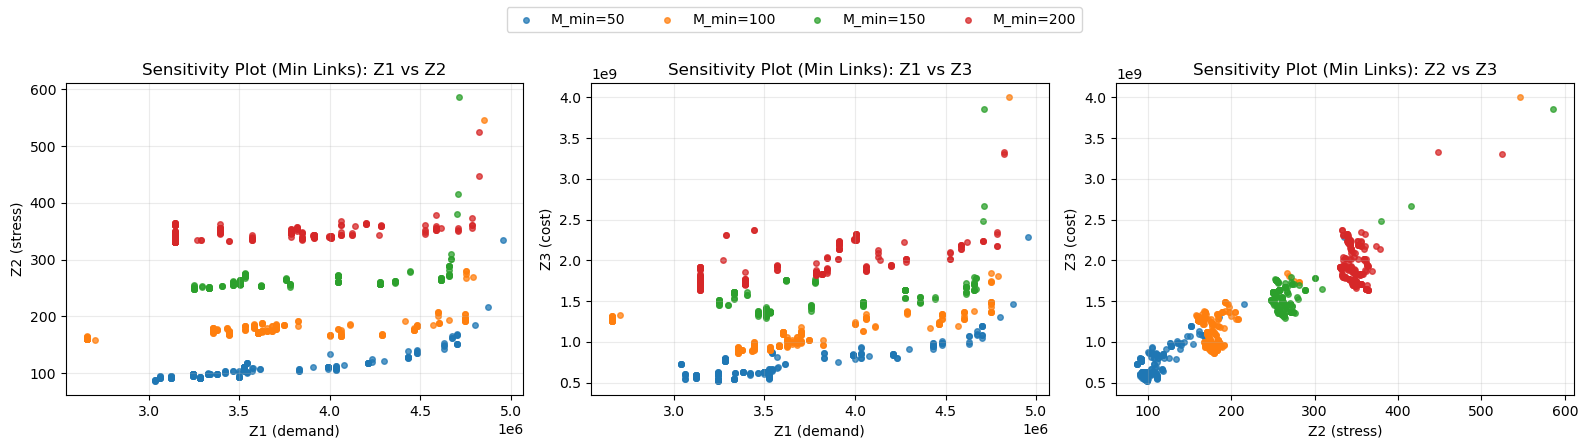

In [75]:
#### Plots_ 2D


M_grid_plot = M_grid

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
pairs = [
    ("Z1_demand", "Z2_stress", "Z1 (demand)", "Z2 (stress)", "Z1 vs Z2"),
    ("Z1_demand", "Z3_cost",   "Z1 (demand)", "Z3 (cost)",   "Z1 vs Z3"),
    ("Z2_stress", "Z3_cost",   "Z2 (stress)", "Z3 (cost)",   "Z2 vs Z3"),
]

for ax, (xcol, ycol, xl, yl, title) in zip(axes, pairs):
    for M in M_grid_plot:
        pf = fronts_M.get(M)
        if pf is None or len(pf) == 0:
            continue
        ax.scatter(pf[xcol], pf[ycol], s=16, alpha=0.75, label=f"M_min={M}")
    ax.set_xlabel(xl)
    ax.set_ylabel(yl)
    ax.set_title(f"Sensitivity Plot (Min Links): {title}")
    ax.grid(True, alpha=0.25)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=len(M_grid_plot), frameon=True)

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()

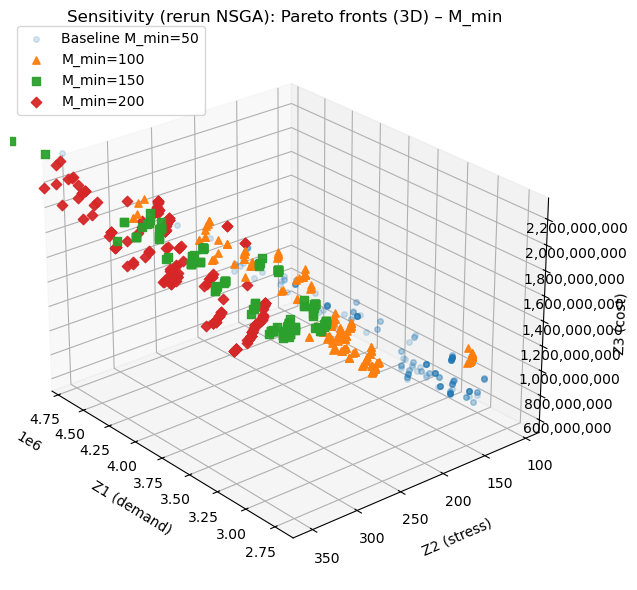

In [76]:
#### Plots_ 3D

from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from matplotlib.ticker import StrMethodFormatter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

baseline_M = M_grid_plot[0]

all_pf = pd.concat(
    [fronts_M[M][["Z1_demand","Z2_stress","Z3_cost"]] for M in M_grid_plot if len(fronts_M[M])],
    ignore_index=True
)

qlo, qhi = 0.02, 0.98
def lim(s):
    lo = float(s.quantile(qlo)); hi = float(s.quantile(qhi))
    pad = 0.03 * (hi - lo + 1e-12)
    return lo - pad, hi + pad

xlim = lim(all_pf["Z1_demand"])
ylim = lim(all_pf["Z2_stress"])
zlim = lim(all_pf["Z3_cost"])

fig = plt.figure(figsize=(7.2, 6.0))
ax = fig.add_subplot(111, projection="3d")

markers = ["o","^","s","D","P","X","v"]
mark_map = {M: markers[i % len(markers)] for i, M in enumerate(M_grid_plot)}

pf0 = fronts_M[baseline_M]
ax.scatter(pf0["Z1_demand"], pf0["Z2_stress"], pf0["Z3_cost"],
           s=16, alpha=0.18, marker=mark_map[baseline_M],
           label=f"Baseline M_min={baseline_M}", depthshade=False)

for M in M_grid_plot:
    if M == baseline_M:
        continue
    pf = fronts_M[M]
    if len(pf) == 0:
        continue
    ax.scatter(pf["Z1_demand"], pf["Z2_stress"], pf["Z3_cost"],
               s=28, alpha=0.95, marker=mark_map[M],
               label=f"M_min={M}", depthshade=False)

ax.set_xlim(*xlim); ax.set_ylim(*ylim); ax.set_zlim(*zlim)
ax.set_xlabel("Z1 (demand)", labelpad=8)
ax.set_ylabel("Z2 (stress)", labelpad=8)
ax.set_zlabel("Z3 (cost)", labelpad=10)
ax.zaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.set_title("Sensitivity (rerun NSGA): Pareto fronts (3D) – M_min")
ax.view_init(elev=26, azim=140)
ax.set_box_aspect((1.2, 1.0, 0.8))
ax.legend(loc="upper left", bbox_to_anchor=(0.0, 1.02))

plt.tight_layout()
plt.show()

In [77]:
import pandas as pd
import numpy as np

# Use the M_grid you ran in the min-links sensitivity
M_grid_for_stats = M_grid  # e.g., [50, 60, 70, 80]

rows = []
for M in M_grid_for_stats:
    pf = fronts_M.get(M)
    if pf is None or len(pf) == 0:
        rows.append({"M_min": M})
        continue

    rows.append({
        "M_min": M,
        "Z1_demand_max": float(pf["Z1_demand"].max()),
        "Z2_stress_min": float(pf["Z2_stress"].min()),
        "Z3_cost_min":   float(pf["Z3_cost"].min()),
    })

df_stats_M = pd.DataFrame(rows).set_index("M_min").sort_index()
df_stats_M

,Z1_demand_max,Z2_stress_min,Z3_cost_min
M_min,,,
50,4953591.0,87.191622,5.246892e+08
100,4851755.0,158.386233,8.658449e+08
150,4711749.0,247.918550,1.295744e+09
200,4820624.0,330.798837,1.637296e+09


In [79]:
best_table_M = pd.DataFrame(index=["Max Z1", "Min Z2", "Min Z3"], columns=df_stats_M.index)

for M in df_stats_M.index:
    best_table_M.loc["Max Z1", M] = f"{df_stats_M.loc[M,'Z1_demand_max']:,.0f}"
    best_table_M.loc["Min Z2", M] = f"{df_stats_M.loc[M,'Z2_stress_min']:.2f}"
    best_table_M.loc["Min Z3", M] = f"{df_stats_M.loc[M,'Z3_cost_min']:,.0f}"

best_table_M

M_min,50,100,150,200
Max Z1,"4,953,591","4,851,755","4,711,749","4,820,624"
Min Z2,87.19,158.39,247.92,330.80
Min Z3,"524,689,204","865,844,903","1,295,744,466","1,637,295,962"


In [81]:
### Checking all station results availability


import pandas as pd

for M, pack in scenario_runs_M.items():
    df_run = pack["df"].copy()
    pop_run = pack["pop"]

    # counts from chromosome slices (fast, no decode)
    df_run["n_nodes"] = [int(sum(ind[:n_y])) for ind in pop_run]
    df_run["n_links"] = [int(sum(ind[n_y:n_y+n_x])) for ind in pop_run]

    # update stored dfs
    scenario_runs_M[M]["df_counts"] = df_run

    # update Pareto df with counts (same indices as df_run)
    pf = pack["pareto"]
    scenario_runs_M[M]["pareto_counts"] = df_run.loc[pf.index].copy() if len(pf) else pf

    # optional: also update fronts_M to the counted version
    fronts_M[M] = scenario_runs_M[M]["pareto_counts"]

print("Done. Example columns:", fronts_M[M_grid[0]].columns)

Done. Example columns: Index(['ok', 'Z1_demand', 'Z2_stress', 'Z3_cost', 'cv', 'n_nodes', 'n_links'], dtype='str')


In [84]:
print(fronts_M[M_grid[0]])

       ok  Z1_demand   Z2_stress       Z3_cost   cv  n_nodes  n_links
0    True  3380181.0   98.316441  6.281534e+08  0.0       68       50
1    True  3380181.0   98.316441  6.281534e+08  0.0       68       50
2    True  3380181.0   98.316441  6.281534e+08  0.0       68       50
3    True  3380181.0   98.316441  6.281534e+08  0.0       68       50
4    True  3380181.0   98.316441  6.281534e+08  0.0       68       50
..    ...        ...         ...           ...  ...      ...      ...
198  True  4482083.0  140.517686  9.594388e+08  0.0       89       73
199  True  3577916.0  110.108360  6.893316e+08  0.0       67       54
200  True  3571281.0  109.206106  6.841253e+08  0.0       71       55
201  True  3497016.0  104.337905  6.035706e+08  0.0       71       54
202  True  3541571.0  100.999789  8.733197e+08  0.0       70       53

[185 rows x 7 columns]


In [85]:
import pandas as pd

best_table_M = pd.DataFrame(index=["Max Z1", "Min Z2", "Min Z3"], columns=sorted(fronts_M.keys()))

for M in best_table_M.columns:
    pf = fronts_M[M]
    best_table_M.loc["Max Z1", M] = f"{pf['Z1_demand'].max():,.0f}"
    best_table_M.loc["Min Z2", M] = f"{pf['Z2_stress'].min():.2f}"
    best_table_M.loc["Min Z3", M] = f"{pf['Z3_cost'].min():,.0f}"

best_table_M

,50,100,150,200
Max Z1,"4,953,591","4,851,755","4,711,749","4,820,624"
Min Z2,87.19,158.39,247.92,330.80
Min Z3,"524,689,204","865,844,903","1,295,744,466","1,637,295,962"


In [90]:
#### Number of stations for best solutions 
### 
stations_table_M = pd.DataFrame(index=["Max Z1", "Min Z2", "Min Z3"], columns=sorted(fronts_M.keys()))

for M in stations_table_M.columns:
    pf = fronts_M[M]

    idx_maxZ1 = pf["Z1_demand"].idxmax()
    idx_minZ2 = pf["Z2_stress"].idxmin()
    idx_minZ3 = pf["Z3_cost"].idxmin()

    stations_table_M.loc["Max Z1", M] = int(pf.loc[idx_maxZ1, "n_nodes"])
    stations_table_M.loc["Min Z2", M] = int(pf.loc[idx_minZ2, "n_nodes"])
    stations_table_M.loc["Min Z3", M] = int(pf.loc[idx_minZ3, "n_nodes"])

# stations_table_M

print("Number of selected stations for best solutions (by M_min)")
stations_table_M

Number of selected stations for best solutions (by M_min)


,50,100,150,200
Max Z1,101,99,95,98
Min Z2,61,61,60,61
Min Z3,63,63,67,61


In [92]:
#### Number of Links for best solutions 


links_table_M = pd.DataFrame(index=["Max Z1", "Min Z2", "Min Z3"], columns=sorted(fronts_M.keys()))

for M in links_table_M.columns:
    pf = fronts_M[M]

    idx_maxZ1 = pf["Z1_demand"].idxmax()
    idx_minZ2 = pf["Z2_stress"].idxmin()
    idx_minZ3 = pf["Z3_cost"].idxmin()

    links_table_M.loc["Max Z1", M] = int(pf.loc[idx_maxZ1, "n_links"])
    links_table_M.loc["Min Z2", M] = int(pf.loc[idx_minZ2, "n_links"])
    links_table_M.loc["Min Z3", M] = int(pf.loc[idx_minZ3, "n_links"])


print("Number of selected links for best solutions (by M_min)")
links_table_M


Number of selected links for best solutions (by M_min)


,50,100,150,200
Max Z1,169,279,299,252
Min Z2,50,100,150,200
Min Z3,52,100,150,200


In [93]:
combined = pd.DataFrame(index=stations_table_M.index, columns=pd.MultiIndex.from_product(
    [stations_table_M.columns, ["Stations", "Links"]],
    names=["M_min", "Metric"]
))

for M in stations_table_M.columns:
    combined[(M, "Stations")] = stations_table_M[M]
    combined[(M, "Links")]    = links_table_M[M]

combined.index.name = "Best point"
print("Network size (selected stations and links) for best points by M_min")
combined

Table Z. Network size (selected stations and links) for best points by M_min


M_min           50             100            150            200      
Metric     Stations Links Stations Links Stations Links Stations Links
Best point                                                            
Max Z1          101   169       99   279       95   299       98   252
Min Z2           61    50       61   100       60   150       61   200
Min Z3           63    52       63   100       67   150       61   200

### Sensitivity Analysis_1

In [118]:
print("S_min =", data.get("S_min"))
print("M_min =", data.get("M_min"))
print("D_min =", data.get("D_min"))

S_min = 15
M_min = 50
D_min = 0.0


In [85]:
### Stations
### add station/link counts once

df_nsga_deap = df_nsga_deap.copy()
df_nsga_deap["n_nodes"] = [int(sum(ind[:n_y])) for ind in pop]
df_nsga_deap["n_links"] = [int(sum(ind[n_y:n_y+n_x])) for ind in pop]

In [89]:
#### sensitivity for S_min by filtering

S_grid = [42, 45, 50, 60]  # choose test values

base_feas = df_nsga_deap[df_nsga_deap["ok"]].copy()

results = []
fronts = {}

for S in S_grid:
    sub = base_feas[base_feas["n_nodes"] >= S].copy()
    if len(sub) == 0:
        fronts[S] = sub
        results.append({"S_min": S, "feasible": 0, "pareto": 0})
        continue

    mask = pareto_mask_maxmin(sub, ["Z1_demand"], ["Z2_stress","Z3_cost"])
    pf = sub.loc[mask].copy()
    fronts[S] = pf
    results.append({"S_min": S, "feasible": len(sub), "pareto": len(pf)})

pd.DataFrame(results)

,S_min,feasible,pareto
0,42,3000,699
1,45,2861,662
2,50,2078,505
3,60,1729,406


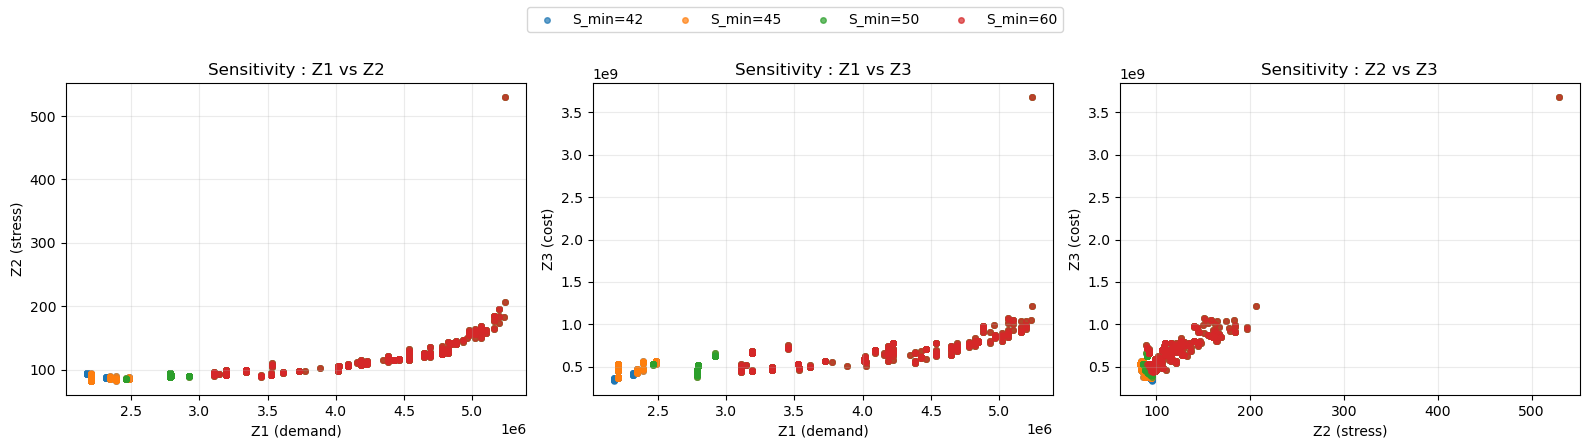

In [93]:
import matplotlib.pyplot as plt

# choose which S values to show (use your S_grid or a subset)
S_grid_plot = [42, 45, 50, 60]  # change if you want

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

pairs = [
    ("Z1_demand", "Z2_stress", "Z1 (demand)", "Z2 (stress)", "Z1 vs Z2"),
    ("Z1_demand", "Z3_cost",   "Z1 (demand)", "Z3 (cost)",   "Z1 vs Z3"),
    ("Z2_stress", "Z3_cost",   "Z2 (stress)", "Z3 (cost)",   "Z2 vs Z3"),
]

for ax, (xcol, ycol, xl, yl, title) in zip(axes, pairs):
    for S in S_grid_plot:
        pf = fronts.get(S)
        if pf is None or len(pf) == 0:
            continue
        ax.scatter(pf[xcol], pf[ycol], s=16, alpha=0.7, label=f"S_min={S}")
    ax.set_xlabel(xl)
    ax.set_ylabel(yl)
    ax.set_title(f"Sensitivity : {title}")
    ax.grid(True, alpha=0.25)

# Put one legend for the whole figure (cleaner)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=len(S_grid_plot), frameon=True)

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()

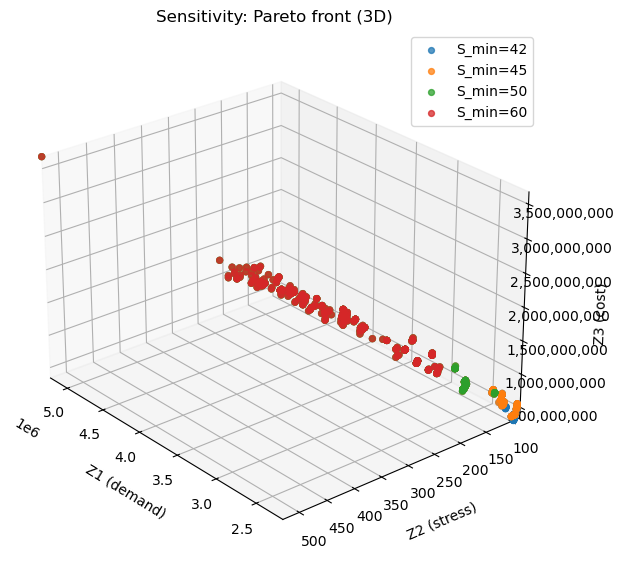

In [102]:
### ANOTHER version of 3D plots 

from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

S_grid_plot = [42, 45, 50, 60]

fig = plt.figure(figsize=(6.8, 5.8))
ax = fig.add_subplot(111, projection="3d")

# Optional: consistent axis limits across scenarios (recommended)
# Build global bounds from all plotted fronts
all_pf = []
for S in S_grid_plot:
    pf = fronts.get(S)
    if pf is not None and len(pf):
        all_pf.append(pf[["Z1_demand","Z2_stress","Z3_cost"]])
if all_pf:
    all_pf = pd.concat(all_pf, ignore_index=True)
    ax.set_xlim(all_pf["Z1_demand"].min(), all_pf["Z1_demand"].max())
    ax.set_ylim(all_pf["Z2_stress"].min(), all_pf["Z2_stress"].max())
    ax.set_zlim(all_pf["Z3_cost"].min(), all_pf["Z3_cost"].max())

for S in S_grid_plot:
    pf = fronts.get(S)
    if pf is None or len(pf) == 0:
        continue
    ax.scatter(pf["Z1_demand"], pf["Z2_stress"], pf["Z3_cost"],
               s=18, alpha=0.75, label=f"S_min={S}")

ax.set_xlabel("Z1 (demand)", labelpad=8)
ax.set_ylabel("Z2 (stress)", labelpad=8)
ax.set_zlabel("Z3 (cost)", labelpad=10)
ax.zaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.tick_params(axis="z", pad=6)

ax.set_title("Sensitivity: Pareto front (3D)")
ax.view_init(elev=26, azim=140)
ax.set_box_aspect((1.2, 1.0, 0.8))
ax.legend()

plt.tight_layout()
plt.show()

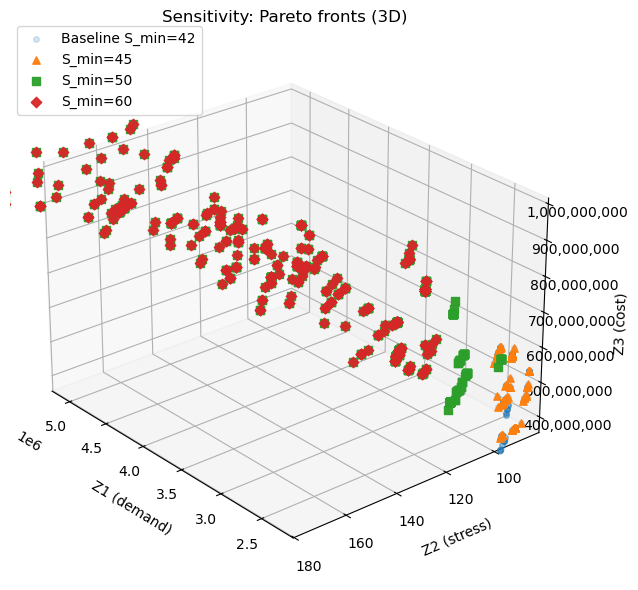

In [114]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
import numpy as np
import pandas as pd

S_grid_plot = [42, 45, 50, 60]
baseline_S = 42

# ---- collect points for robust limits (optional clipping) ----
all_pf = pd.concat(
    [fronts[S][["Z1_demand","Z2_stress","Z3_cost"]] for S in S_grid_plot
     if fronts.get(S) is not None and len(fronts[S])],
    ignore_index=True
)

qlo, qhi = 0.02, 0.98
def lim(s):
    lo = float(s.quantile(qlo))
    hi = float(s.quantile(qhi))
    pad = 0.03 * (hi - lo + 1e-12)
    return lo - pad, hi + pad

xlim = lim(all_pf["Z1_demand"])
ylim = lim(all_pf["Z2_stress"])
zlim = lim(all_pf["Z3_cost"])

fig = plt.figure(figsize=(7.2, 6.0))
ax = fig.add_subplot(111, projection="3d")

markers = {42:"o", 45:"^", 50:"s", 60:"D"}

# --- 1) Baseline FIRST (faded) so it doesn't hide others ---
pf0 = fronts.get(baseline_S)
if pf0 is not None and len(pf0):
    ax.scatter(
        pf0["Z1_demand"], pf0["Z2_stress"], pf0["Z3_cost"],
        s=16, alpha=0.18, marker=markers.get(baseline_S, "o"),
        label=f"Baseline S_min={baseline_S}",
        depthshade=False
    )

# --- 2) Other scenarios on top (bolder) ---
for S in S_grid_plot:
    if S == baseline_S:
        continue
    pf = fronts.get(S)
    if pf is None or len(pf) == 0:
        continue
    ax.scatter(
        pf["Z1_demand"], pf["Z2_stress"], pf["Z3_cost"],
        s=28, alpha=0.95, marker=markers.get(S, "o"),
        label=f"S_min={S}",
        depthshade=False
    )

ax.set_xlim(*xlim); ax.set_ylim(*ylim); ax.set_zlim(*zlim)

ax.set_xlabel("Z1 (demand)", labelpad=8)
ax.set_ylabel("Z2 (stress)", labelpad=8)
ax.set_zlabel("Z3 (cost)", labelpad=10)
ax.zaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.set_title("Sensitivity: Pareto fronts (3D)")

ax.view_init(elev=26, azim=140)
ax.set_box_aspect((1.2, 1.0, 0.8))
#ax.legend(loc="upper left")
ax.legend(loc="upper left", bbox_to_anchor=(0.0, 1.02))

plt.tight_layout()
plt.show()

In [125]:
### M_Min / Links

base_feas = df_nsga_deap[df_nsga_deap["ok"]].copy()
print(base_feas["n_links"].describe())

#M_grid = sorted(set(base_feas["n_links"].quantile([0.00, 0.25, 0.50, 0.75, 0.90]).round().astype(int).tolist()))
#M_grid

M_grid = [60, 70, 80, 90]   # example only


count    3000.000000
mean       57.499333
std        13.740607
min        50.000000
25%        50.000000
50%        51.000000
75%        60.000000
max       389.000000
Name: n_links, dtype: float64


In [126]:
# ---- sensitivity for M_min by filtering ----
M_grid = M_grid  # keep what you defined above (or replace with your manual list)

base_feas = df_nsga_deap[df_nsga_deap["ok"]].copy()

results_M = []
fronts_M = {}

for M in M_grid:
    sub = base_feas[base_feas["n_links"] >= M].copy()
    if len(sub) == 0:
        fronts_M[M] = sub
        results_M.append({"M_min": M, "feasible": 0, "pareto": 0})
        continue

    mask = pareto_mask_maxmin(sub, ["Z1_demand"], ["Z2_stress", "Z3_cost"])
    pf = sub.loc[mask].copy()
    fronts_M[M] = pf
    results_M.append({"M_min": M, "feasible": len(sub), "pareto": len(pf)})

pd.DataFrame(results_M)

,M_min,feasible,pareto
0,60,792,186
1,70,422,103
2,80,244,61
3,90,71,14


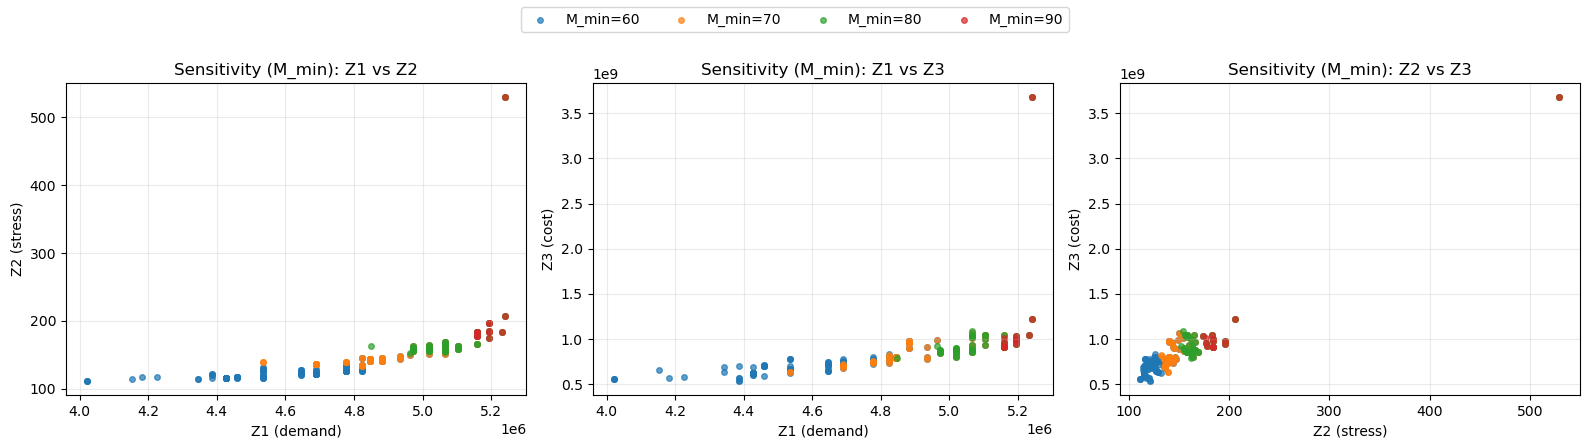

In [127]:
import matplotlib.pyplot as plt

M_grid_plot = M_grid  # or choose subset like [M_grid[0], M_grid[2], M_grid[-1]]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

pairs = [
    ("Z1_demand", "Z2_stress", "Z1 (demand)", "Z2 (stress)", "Z1 vs Z2"),
    ("Z1_demand", "Z3_cost",   "Z1 (demand)", "Z3 (cost)",   "Z1 vs Z3"),
    ("Z2_stress", "Z3_cost",   "Z2 (stress)", "Z3 (cost)",   "Z2 vs Z3"),
]

for ax, (xcol, ycol, xl, yl, title) in zip(axes, pairs):
    for M in M_grid_plot:
        pf = fronts_M.get(M)
        if pf is None or len(pf) == 0:
            continue
        ax.scatter(pf[xcol], pf[ycol], s=16, alpha=0.7, label=f"M_min={M}")
    ax.set_xlabel(xl)
    ax.set_ylabel(yl)
    ax.set_title(f"Sensitivity (M_min): {title}")
    ax.grid(True, alpha=0.25)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=min(len(M_grid_plot), 6), frameon=True)

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()

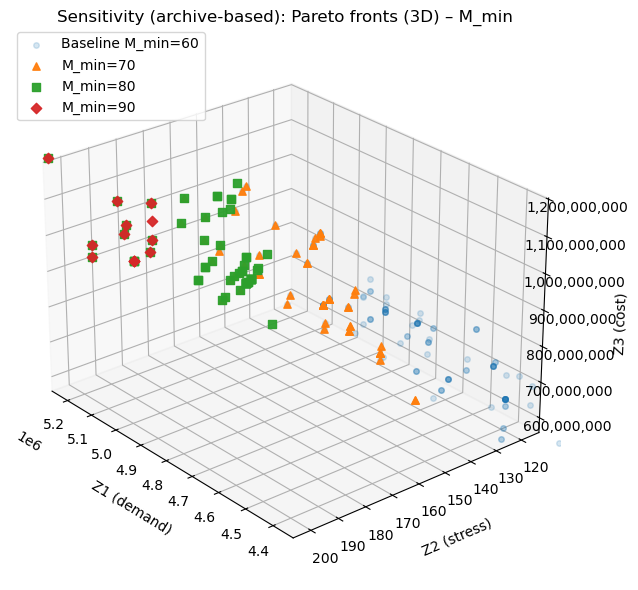

In [131]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
import numpy as np
import pandas as pd

M_grid_plot = M_grid  # or subset
baseline_M = M_grid_plot[0]  # treat the smallest as baseline

# collect points for robust limits (clipped)
all_pf = pd.concat(
    [fronts_M[M][["Z1_demand","Z2_stress","Z3_cost"]] for M in M_grid_plot
     if fronts_M.get(M) is not None and len(fronts_M[M])],
    ignore_index=True
)

qlo, qhi = 0.02, 0.98
def lim(s):
    lo = float(s.quantile(qlo))
    hi = float(s.quantile(qhi))
    pad = 0.03 * (hi - lo + 1e-12)
    return lo - pad, hi + pad

xlim = lim(all_pf["Z1_demand"])
ylim = lim(all_pf["Z2_stress"])
zlim = lim(all_pf["Z3_cost"])

fig = plt.figure(figsize=(7.2, 6.0))
ax = fig.add_subplot(111, projection="3d")

markers = ["o", "^", "s", "D", "P", "X", "v"]  # enough variety
mark_map = {M: markers[i % len(markers)] for i, M in enumerate(M_grid_plot)}

# baseline first (faded)
pf0 = fronts_M.get(baseline_M)
if pf0 is not None and len(pf0):
    ax.scatter(
        pf0["Z1_demand"], pf0["Z2_stress"], pf0["Z3_cost"],
        s=16, alpha=0.18, marker=mark_map[baseline_M],
        label=f"Baseline M_min={baseline_M}",
        depthshade=False
    )

# others on top
for M in M_grid_plot:
    if M == baseline_M:
        continue
    pf = fronts_M.get(M)
    if pf is None or len(pf) == 0:
        continue
    ax.scatter(
        pf["Z1_demand"], pf["Z2_stress"], pf["Z3_cost"],
        s=28, alpha=0.95, marker=mark_map[M],
        label=f"M_min={M}",
        depthshade=False
    )

ax.set_xlim(*xlim); ax.set_ylim(*ylim); ax.set_zlim(*zlim)
ax.set_xlabel("Z1 (demand)", labelpad=8)
ax.set_ylabel("Z2 (stress)", labelpad=8)
ax.set_zlabel("Z3 (cost)", labelpad=10)
ax.zaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.set_title("Sensitivity (archive-based): Pareto fronts (3D) – M_min")
ax.view_init(elev=26, azim=140)
ax.set_box_aspect((1.2, 1.0, 0.8))
ax.legend(loc="upper left", bbox_to_anchor=(0.0, 1.01))

plt.tight_layout()
plt.show()

In [ ]:
###

In [132]:
### D_Min

base_feas = df_nsga_deap[df_nsga_deap["ok"]].copy()
print("Feasible archive size:", len(base_feas))
print(base_feas["Z1_demand"].describe())

Feasible archive size: 3000
count    3.000000e+03
mean     3.430022e+06
std      1.006915e+06
min      2.175912e+06
25%      2.389239e+06
50%      3.191816e+06
75%      4.385074e+06
max      5.241768e+06
Name: Z1_demand, dtype: float64


In [133]:
# Build D_grid from quantiles of feasible Z1_demand

D_grid = sorted(set(
    base_feas["Z1_demand"]
    .quantile([0.00, 0.10, 0.25, 0.50, 0.75, 0.90])
    .round()
    .astype(int)
    .tolist()
))

D_grid

[2175912, 2209729, 2389239, 3191816, 4385074, 4882284]

In [134]:
D_grid = [2000000, 2500000, 3000000, 3500000, 4000000, 4500000]

In [135]:
results_D = []
fronts_D = {}

for Dmin in D_grid:
    sub = base_feas[base_feas["Z1_demand"] >= Dmin].copy()
    if len(sub) == 0:
        fronts_D[Dmin] = sub
        results_D.append({"D_min": int(Dmin), "feasible": 0, "pareto": 0})
        continue

    mask = pareto_mask_maxmin(sub, ["Z1_demand"], ["Z2_stress", "Z3_cost"])
    pf = sub.loc[mask].copy()
    fronts_D[Dmin] = pf
    results_D.append({"D_min": int(Dmin), "feasible": len(sub), "pareto": len(pf)})

df_results_D = pd.DataFrame(results_D).sort_values("D_min")
df_results_D

,D_min,feasible,pareto
0,2000000,3000,699
1,2500000,2013,495
2,3000000,1729,406
3,3500000,1315,294
4,4000000,1135,243
5,4500000,646,149


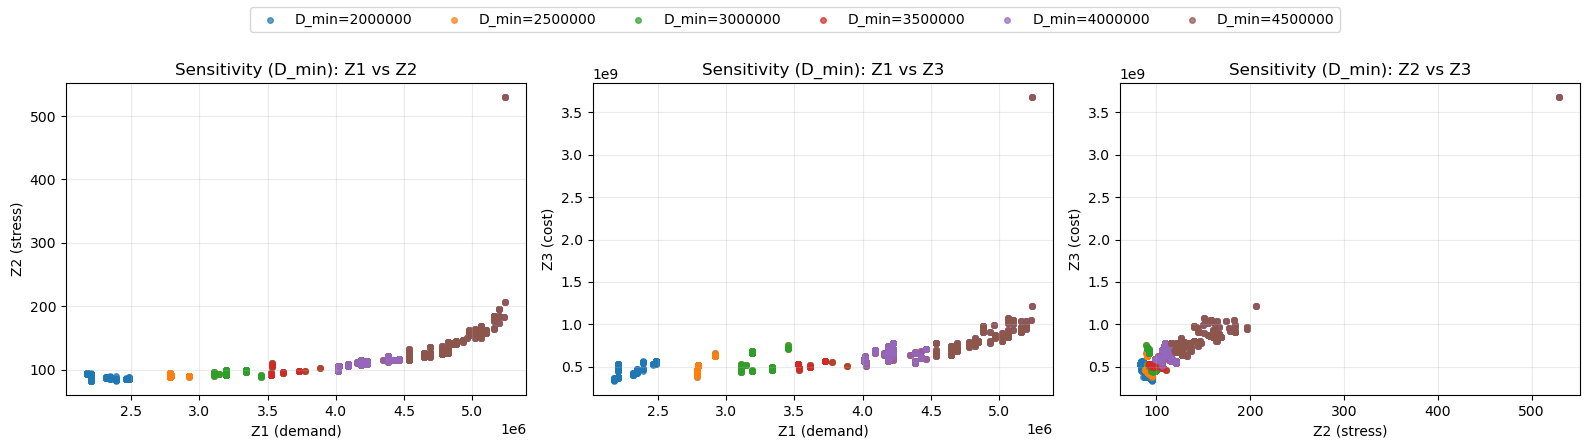

In [136]:
import matplotlib.pyplot as plt

D_grid_plot = D_grid  # or choose a smaller subset if legend gets big

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

pairs = [
    ("Z1_demand", "Z2_stress", "Z1 (demand)", "Z2 (stress)", "Z1 vs Z2"),
    ("Z1_demand", "Z3_cost",   "Z1 (demand)", "Z3 (cost)",   "Z1 vs Z3"),
    ("Z2_stress", "Z3_cost",   "Z2 (stress)", "Z3 (cost)",   "Z2 vs Z3"),
]

for ax, (xcol, ycol, xl, yl, title) in zip(axes, pairs):
    for Dmin in D_grid_plot:
        pf = fronts_D.get(Dmin)
        if pf is None or len(pf) == 0:
            continue
        ax.scatter(pf[xcol], pf[ycol], s=16, alpha=0.7, label=f"D_min={int(Dmin)}")
    ax.set_xlabel(xl)
    ax.set_ylabel(yl)
    ax.set_title(f"Sensitivity (D_min): {title}")
    ax.grid(True, alpha=0.25)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=min(len(D_grid_plot), 6), frameon=True)

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()

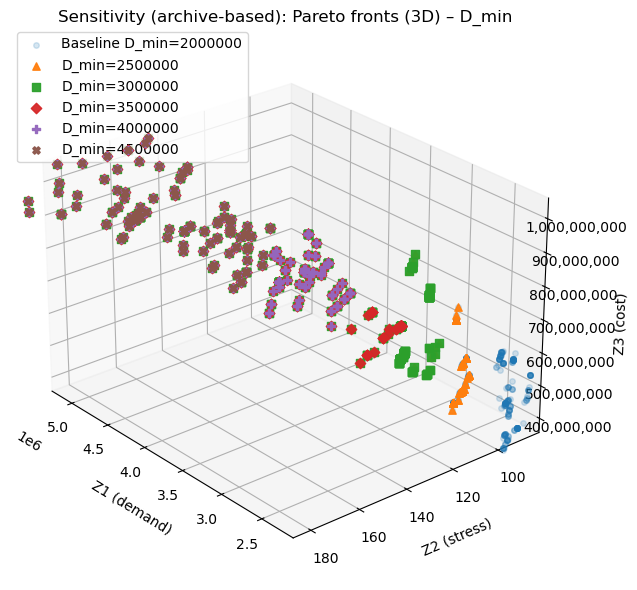

In [139]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
import numpy as np
import pandas as pd

D_grid_plot = D_grid
baseline_D = D_grid_plot[0]

# collect points for clipped limits
all_pf = pd.concat(
    [fronts_D[Dmin][["Z1_demand","Z2_stress","Z3_cost"]] for Dmin in D_grid_plot
     if fronts_D.get(Dmin) is not None and len(fronts_D[Dmin])],
    ignore_index=True
)

qlo, qhi = 0.02, 0.98
def lim(s):
    lo = float(s.quantile(qlo))
    hi = float(s.quantile(qhi))
    pad = 0.03 * (hi - lo + 1e-12)
    return lo - pad, hi + pad

xlim = lim(all_pf["Z1_demand"])
ylim = lim(all_pf["Z2_stress"])
zlim = lim(all_pf["Z3_cost"])

fig = plt.figure(figsize=(7.2, 6.0))
ax = fig.add_subplot(111, projection="3d")

markers = ["o", "^", "s", "D", "P", "X", "v"]
mark_map = {Dmin: markers[i % len(markers)] for i, Dmin in enumerate(D_grid_plot)}

# baseline first (faded)
pf0 = fronts_D.get(baseline_D)
if pf0 is not None and len(pf0):
    ax.scatter(
        pf0["Z1_demand"], pf0["Z2_stress"], pf0["Z3_cost"],
        s=16, alpha=0.18, marker=mark_map[baseline_D],
        label=f"Baseline D_min={int(baseline_D)}",
        depthshade=False
    )

# others on top
for Dmin in D_grid_plot:
    if Dmin == baseline_D:
        continue
    pf = fronts_D.get(Dmin)
    if pf is None or len(pf) == 0:
        continue
    ax.scatter(
        pf["Z1_demand"], pf["Z2_stress"], pf["Z3_cost"],
        s=28, alpha=0.95, marker=mark_map[Dmin],
        label=f"D_min={int(Dmin)}",
        depthshade=False
    )

ax.set_xlim(*xlim); ax.set_ylim(*ylim); ax.set_zlim(*zlim)
ax.set_xlabel("Z1 (demand)", labelpad=8)
ax.set_ylabel("Z2 (stress)", labelpad=8)
ax.set_zlabel("Z3 (cost)", labelpad=10)
ax.zaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.set_title("Sensitivity (archive-based): Pareto fronts (3D) – D_min")
ax.view_init(elev=26, azim=140)
ax.set_box_aspect((1.2, 1.0, 0.8))
ax.legend(loc="upper left", bbox_to_anchor=(0.0, 1.01))

plt.tight_layout()
plt.show()

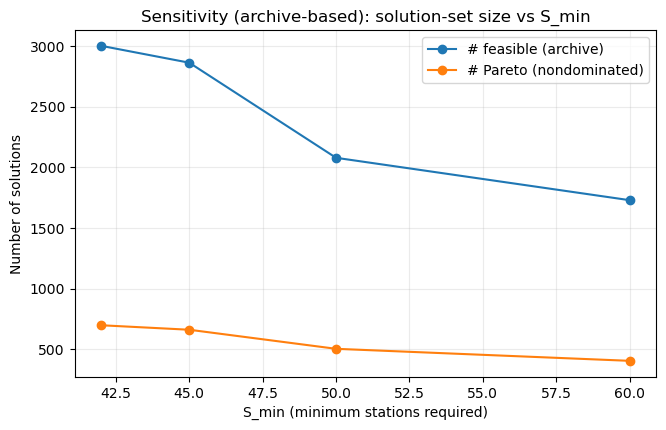

,S_min,feasible,pareto
0,42,3000,699
1,45,2861,662
2,50,2078,505
3,60,1729,406


In [95]:
#### Feasible count = how many solutions in your existing archive still satisfy
#### Pareto count = how many nondominated solutions remain after that filtering


# If you already have results as a list of dicts like:
# results = [{"S_min":42,"feasible":3000,"pareto":699}, ...]
df_summary = pd.DataFrame(results).sort_values("S_min")

plt.figure(figsize=(7.5, 4.5))
plt.plot(df_summary["S_min"], df_summary["feasible"], marker="o", label="# feasible (archive)")
plt.plot(df_summary["S_min"], df_summary["pareto"], marker="o", label="# Pareto (nondominated)")

plt.xlabel("S_min (minimum stations required)")
plt.ylabel("Number of solutions")
plt.title("Sensitivity (archive-based): solution-set size vs S_min")
plt.grid(True, alpha=0.25)
plt.legend()
plt.show()

df_summary

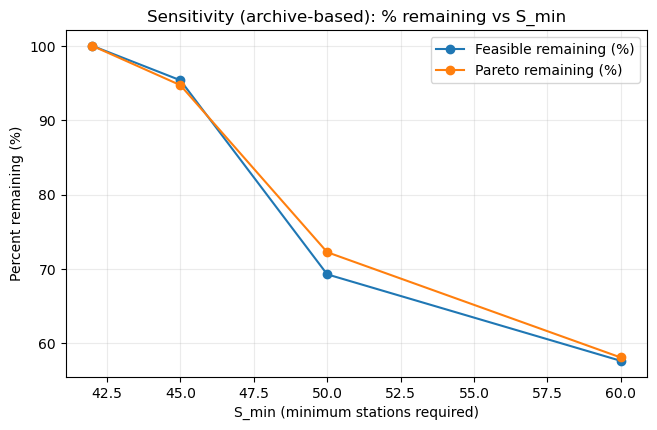

,S_min,feasible,pareto,feasible_%,pareto_%
0,42,3000,699,100.000000,100.000000
1,45,2861,662,95.366667,94.706724
2,50,2078,505,69.266667,72.246066
3,60,1729,406,57.633333,58.082976


In [96]:
#### Version: percent remaining


df_summary = pd.DataFrame(results).sort_values("S_min")
base_feasible = df_summary["feasible"].iloc[0]
base_pareto   = df_summary["pareto"].iloc[0]

df_summary["feasible_%"] = 100 * df_summary["feasible"] / (base_feasible if base_feasible else 1)
df_summary["pareto_%"]   = 100 * df_summary["pareto"]   / (base_pareto if base_pareto else 1)

plt.figure(figsize=(7.5, 4.5))
plt.plot(df_summary["S_min"], df_summary["feasible_%"], marker="o", label="Feasible remaining (%)")
plt.plot(df_summary["S_min"], df_summary["pareto_%"], marker="o", label="Pareto remaining (%)")

plt.xlabel("S_min (minimum stations required)")
plt.ylabel("Percent remaining (%)")
plt.title("Sensitivity (archive-based): % remaining vs S_min")
plt.grid(True, alpha=0.25)
plt.legend()
plt.show()

df_summary

In [97]:
####  how the Pareto front shifts as S_Min increase by tracking the median (and 24-75% band)
#  of each objective across Pareto solutions in each scenario


S_grid_plot = [42, 45, 50, 60]  # use your list (or S_grid)

rows = []
for S in S_grid_plot:
    pf = fronts.get(S)
    if pf is None or len(pf) == 0:
        rows.append({"S_min": S, 
                     "Z1_med": np.nan, "Z1_q25": np.nan, "Z1_q75": np.nan,
                     "Z2_med": np.nan, "Z2_q25": np.nan, "Z2_q75": np.nan,
                     "Z3_med": np.nan, "Z3_q25": np.nan, "Z3_q75": np.nan})
        continue

    rows.append({
        "S_min": S,
        "Z1_med": pf["Z1_demand"].median(),
        "Z1_q25": pf["Z1_demand"].quantile(0.25),
        "Z1_q75": pf["Z1_demand"].quantile(0.75),

        "Z2_med": pf["Z2_stress"].median(),
        "Z2_q25": pf["Z2_stress"].quantile(0.25),
        "Z2_q75": pf["Z2_stress"].quantile(0.75),

        "Z3_med": pf["Z3_cost"].median(),
        "Z3_q25": pf["Z3_cost"].quantile(0.25),
        "Z3_q75": pf["Z3_cost"].quantile(0.75),
    })

df_shift = pd.DataFrame(rows).sort_values("S_min")
df_shift

,S_min,Z1_med,Z1_q25,Z1_q75,Z2_med,Z2_q25,Z2_q75,Z3_med,Z3_q25,Z3_q75
0,42,3338778.0,2483323.0,4385074.0,95.201934,88.877292,115.642692,5.485776e+08,4.618285e+08,6.943122e+08
1,45,3338778.0,2483323.0,4425988.0,95.201934,89.531003,115.663530,5.541847e+08,4.728250e+08,7.031808e+08
2,50,3614261.0,3191816.0,4645589.0,99.189204,92.407090,124.313024,6.222317e+08,5.025412e+08,7.493424e+08
3,60,4182497.0,3449543.0,4776767.0,109.713012,97.705020,128.472860,6.649601e+08,5.324001e+08,7.753956e+08


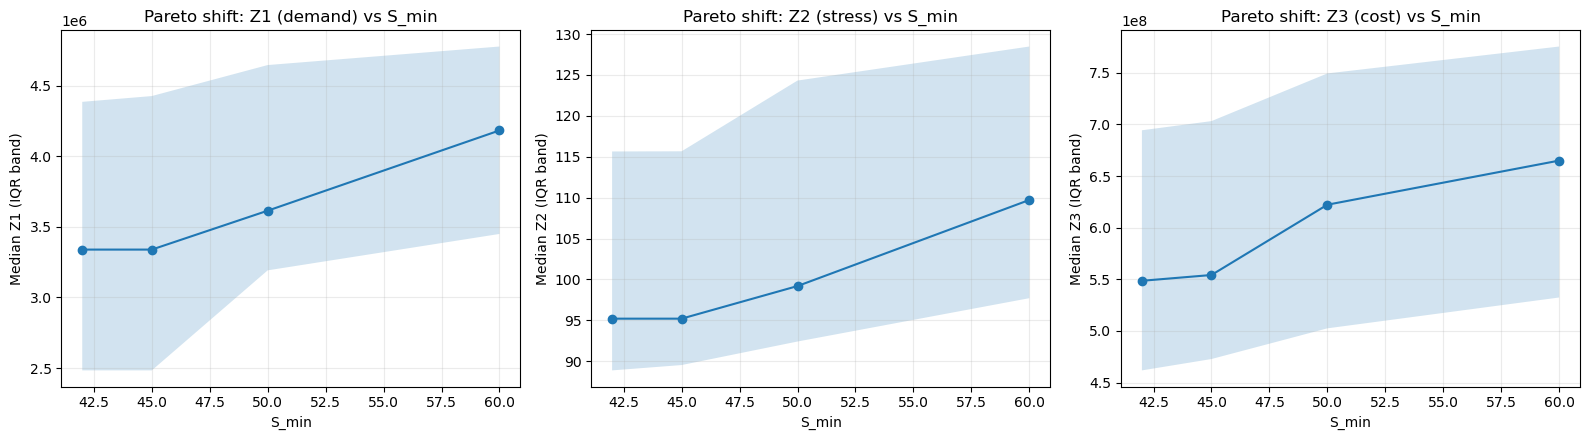

In [98]:

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# --- Z1 (maximize) ---
axes[0].plot(df_shift["S_min"], df_shift["Z1_med"], marker="o")
axes[0].fill_between(df_shift["S_min"], df_shift["Z1_q25"], df_shift["Z1_q75"], alpha=0.2)
axes[0].set_title("Pareto shift: Z1 (demand) vs S_min")
axes[0].set_xlabel("S_min")
axes[0].set_ylabel("Median Z1 (IQR band)")
axes[0].grid(True, alpha=0.25)

# --- Z2 (minimize) ---
axes[1].plot(df_shift["S_min"], df_shift["Z2_med"], marker="o")
axes[1].fill_between(df_shift["S_min"], df_shift["Z2_q25"], df_shift["Z2_q75"], alpha=0.2)
axes[1].set_title("Pareto shift: Z2 (stress) vs S_min")
axes[1].set_xlabel("S_min")
axes[1].set_ylabel("Median Z2 (IQR band)")
axes[1].grid(True, alpha=0.25)

# --- Z3 (minimize) ---
axes[2].plot(df_shift["S_min"], df_shift["Z3_med"], marker="o")
axes[2].fill_between(df_shift["S_min"], df_shift["Z3_q25"], df_shift["Z3_q75"], alpha=0.2)
axes[2].set_title("Pareto shift: Z3 (cost) vs S_min")
axes[2].set_xlabel("S_min")
axes[2].set_ylabel("Median Z3 (IQR band)")
axes[2].grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

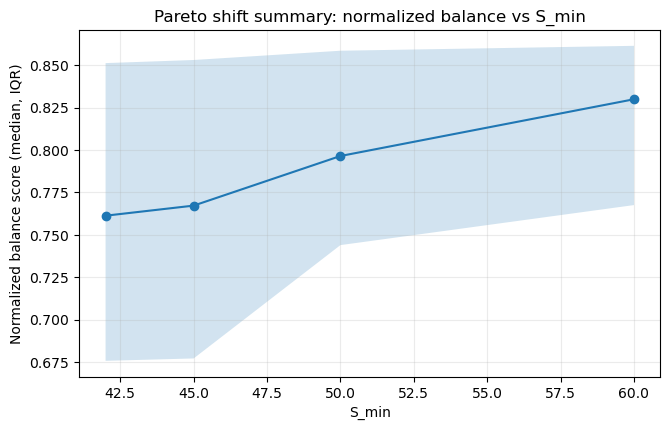

,S_min,score_med,score_q25,score_q75
0,42,0.761289,0.675710,0.851272
1,45,0.767234,0.677114,0.853096
2,50,0.796489,0.743946,0.858565
3,60,0.829952,0.767551,0.861453


In [99]:
#### how a normalized balance changes/// plot a single “trade-off score”


# Build global bounds from ALL fronts shown (for consistent normalization)
all_pf = pd.concat([fronts[S] for S in S_grid_plot if fronts.get(S) is not None and len(fronts[S])>0], ignore_index=True)

Z1_min, Z1_max = all_pf["Z1_demand"].min(), all_pf["Z1_demand"].max()
Z2_min, Z2_max = all_pf["Z2_stress"].min(), all_pf["Z2_stress"].max()
Z3_min, Z3_max = all_pf["Z3_cost"].min(), all_pf["Z3_cost"].max()

def norm(v, lo, hi):
    return (v - lo) / (hi - lo + 1e-12)

rows = []
for S in S_grid_plot:
    pf = fronts.get(S)
    if pf is None or len(pf) == 0:
        rows.append({"S_min": S, "score_med": np.nan, "score_q25": np.nan, "score_q75": np.nan})
        continue

    # convert to "higher is better" for all:
    z1 = norm(pf["Z1_demand"], Z1_min, Z1_max)          # higher better
    z2 = 1.0 - norm(pf["Z2_stress"], Z2_min, Z2_max)    # lower stress => higher better
    z3 = 1.0 - norm(pf["Z3_cost"],   Z3_min, Z3_max)    # lower cost => higher better

    score = (z1 + z2 + z3) / 3.0

    rows.append({
        "S_min": S,
        "score_med": score.median(),
        "score_q25": score.quantile(0.25),
        "score_q75": score.quantile(0.75)
    })

df_score = pd.DataFrame(rows).sort_values("S_min")

plt.figure(figsize=(7.5, 4.5))
plt.plot(df_score["S_min"], df_score["score_med"], marker="o")
plt.fill_between(df_score["S_min"], df_score["score_q25"], df_score["score_q75"], alpha=0.2)
plt.xlabel("S_min")
plt.ylabel("Normalized balance score (median, IQR)")
plt.title("Pareto shift summary: normalized balance vs S_min")
plt.grid(True, alpha=0.25)
plt.show()

df_score

### Mapping Different Solution

In [65]:
# ============================================================
# D) MAP — balanced/best solution on real Montreal basemap
# CRS: EPSG:2950 -> EPSG:4326 for Folium
# ============================================================

import folium
import pyproj
import networkx as nx
from folium import Element

t2950 = pyproj.Transformer.from_crs("EPSG:2950", "EPSG:4326", always_xy=True)

def to_latlon(x, y):
    lon, lat = t2950.transform(x, y)
    return [lat, lon]

# center from candidates
cand_4326 = candidates_with_station_gdf.to_crs(epsg=4326)
center = [cand_4326.geometry.y.mean(), cand_4326.geometry.x.mean()]

m = folium.Map(location=center, zoom_start=12, tiles="CartoDB positron")

# plot selected stations
for xy in selected_stations:
    folium.CircleMarker(
        location=to_latlon(xy[0], xy[1]),
        radius=8,
        color="black",
        weight=2,
        fill=True,
        fill_color="limegreen",
        fill_opacity=0.95,
        popup=f"Selected: {xy}"
    ).add_to(m)

# plot selected links as shortest paths
failed = 0
for u, v in selected_links:
    try:
        path = nx.shortest_path(G, u, v, weight="length")
        coords = [to_latlon(x, y) for (x, y) in path]
        folium.PolyLine(coords, color="royalblue", weight=5, opacity=0.85).add_to(m)
    except Exception:
        failed += 1

print("Failed shortest paths:", failed)

legend_html = f"""
<div style="position:fixed;bottom:50px;left:50px;width:270px;z-index:9999;font-size:15px;
background-color:rgba(255,255,255,0.92);border:2px solid grey;border-radius:8px;padding:10px;">
<b>Legend</b><br>
<span style="display:inline-block;width:18px;height:18px;background:limegreen;border-radius:50%;
margin-right:8px;border:2.5px solid black;"></span> Selected station<br>
<span style="display:inline-block;width:22px;height:6px;background:royalblue;margin-right:8px;"></span> Selected link<br>

</div>
"""
m.get_root().html.add_child(Element(legend_html))

display(m)
map_html = f"{solution_label}_nsga_balanced_solution_map.html"
m.save(map_html)
print("Saved map:", map_html)


Failed shortest paths: 0


Saved map: m<folium.folium.Map object at 0x30ace43d0>_nsga_balanced_solution_map.html


### OLD_ MAPPING (balanced, 3 objective with Min CV) _ OLD

In [66]:
# Rebuild results table from existing pop with index idx

rows = []
for idx, ind in enumerate(pop):
    y, x, z = _decode(ind)

    Z1 = sum(_D[i] * y[i] for i in _N)
    Z2 = sum(get_LTS(i, j) * x[(i, j)] for (i, j) in _L)
    Z3 = sum(get_Cup(i, j) * x[(i, j)] for (i, j) in _L) + C_dock * sum(z[i] for i in _N)

    if C_station > 0:
        Z3 += C_station * sum(y.values())

    cv = _constraint_violation(y, x, z)

    rows.append({
        "idx": idx,
        "Z1_demand": float(Z1),
        "Z2_stress": float(Z2),
        "Z3_cost": float(Z3),
        "cv": float(cv),
        "ok": cv == 0
    })

df_nsga_full = pd.DataFrame(rows)

print("Rebuilt results table:", len(df_nsga_full))
print("Feasible:", df_nsga_full["ok"].sum())
df_nsga_full.head()

Rebuilt results table: 3000
Feasible: 3000


,idx,Z1_demand,Z2_stress,Z3_cost,cv,ok
0,0,3527279.0,92.40709,5.324001e+08,0.0,True
1,1,3527279.0,92.40709,5.324001e+08,0.0,True
2,2,3527279.0,92.40709,5.324001e+08,0.0,True
3,3,3527279.0,92.40709,5.324001e+08,0.0,True
4,4,3527279.0,92.40709,5.324001e+08,0.0,True


In [68]:
import numpy as np
import pandas as pd

# ----------------------------
# Choose candidate pool:
# - if feasible exists -> use feasible
# - else -> use top-K lowest cv
# ----------------------------
# Use df_nsga_full (it has idx)
if df_nsga_full["ok"].sum() > 0:
    pool = df_nsga_full[df_nsga_full["ok"]].copy()
    print("Selection pool = feasible:", len(pool))
else:
    K = min(300, len(df_nsga_full))
    pool = df_nsga_full.sort_values(["cv", "Z1_demand"], ascending=[True, False]).head(K).copy()
    print("Selection pool = top", len(pool), "lowest-cv solutions (no feasible).")

def pick_by_key(pool_df, key_cols, ascending_list):
    row = pool_df.sort_values(key_cols, ascending=ascending_list).iloc[0]
    ind = pop[int(row["idx"])]
    y, x, z = _decode(ind)
    return row, ind, y, x, z

# 1) Smallest CV + max demand
row_dem, ind_dem, y_dem, x_dem, z_dem = pick_by_key(
    pool, ["cv", "Z1_demand", "Z2_stress", "Z3_cost"], [True, False, True, True]
)

# 2) Smallest CV + min stress
row_str, ind_str, y_str, x_str, z_str = pick_by_key(
    pool, ["cv", "Z2_stress", "Z3_cost", "Z1_demand"], [True, True, True, False]
)

# 3) Smallest CV + min cost
row_cost, ind_cost, y_cost, x_cost, z_cost = pick_by_key(
    pool, ["cv", "Z3_cost", "Z2_stress", "Z1_demand"], [True, True, True, False]
)

# 4) Balanced (ideal-point distance) within the same pool
eps = 1e-9
Z1 = pool["Z1_demand"].to_numpy()
Z2 = pool["Z2_stress"].to_numpy()
Z3 = pool["Z3_cost"].to_numpy()

# normalize so "smaller is better" for distance
Z1n = (Z1.max() - Z1) / (Z1.max() - Z1.min() + eps)  # closer to max demand => smaller
Z2n = (Z2 - Z2.min()) / (Z2.max() - Z2.min() + eps)
Z3n = (Z3 - Z3.min()) / (Z3.max() - Z3.min() + eps)

dist = np.sqrt(Z1n**2 + Z2n**2 + Z3n**2)
balanced_row = pool.iloc[int(np.argmin(dist))]

ind_bal = pop[int(balanced_row["idx"])]
y_bal, x_bal, z_bal = _decode(ind_bal)

print("\nSelected solutions:")
print(" BestDemand:", dict(row_dem))
print(" BestStress:", dict(row_str))
print(" BestCost:  ", dict(row_cost))
print(" Balanced:  ", dict(balanced_row))

# ----------------------------
# Pack all solutions (for mapping + saving)
# ----------------------------
solutions = {
    "BestDemand": (row_dem, y_dem, x_dem, z_dem),
    "BestStress": (row_str, y_str, x_str, z_str),
    "BestCost":   (row_cost, y_cost, x_cost, z_cost),
    "Balanced":   (balanced_row, y_bal, x_bal, z_bal),
}

# ----------------------------
# Save CSVs for each solution
# ----------------------------
# def save_solution_csvs(label, y_sol, x_sol, z_sol, prefix="nsga"):
#     selected_stations = [i for i in _N if y_sol[i] == 1]
#     selected_links = [(i, j) for (i, j) in _L if x_sol[(i, j)] == 1]

#     stations_sel_df = pd.DataFrame({
#         "node": selected_stations,
#         "demand": [float(_D[i]) for i in selected_stations],
#         "z_capacity": [float(z_sol[i]) for i in selected_stations],
#     })
#     links_sel_df = pd.DataFrame({
#         "from_node": [e[0] for e in selected_links],
#         "to_node":   [e[1] for e in selected_links],
#         "lts":       [float(get_LTS(e[0], e[1])) for e in selected_links],
#         "cost_up":   [float(get_Cup(e[0], e[1])) for e in selected_links],
#     })

#     stations_csv = f"{solution_label}_{prefix}_{label}_stations.csv"
#     links_csv    = f"{solution_label}_{prefix}_{label}_links.csv"
#     stations_sel_df.to_csv(stations_csv, index=False)
#     links_sel_df.to_csv(links_csv, index=False)
#     print("Saved CSVs:", stations_csv, links_csv)

# for label, (_, y_sol, x_sol, z_sol) in solutions.items():
#     save_solution_csvs(label, y_sol, x_sol, z_sol)

Selection pool = feasible: 3000

Selected solutions:
 BestDemand: {'idx': np.int64(667), 'Z1_demand': np.float64(5241768.0), 'Z2_stress': np.float64(529.148337957568), 'Z3_cost': np.float64(3674516882.0506425), 'cv': np.float64(0.0), 'ok': np.True_}
 BestStress: {'idx': np.int64(349), 'Z1_demand': np.float64(2209729.0), 'Z2_stress': np.float64(83.14304474627535), 'Z3_cost': np.float64(527269380.1700471), 'cv': np.float64(0.0), 'ok': np.True_}
 BestCost:   {'idx': np.int64(615), 'Z1_demand': np.float64(2175912.0), 'Z2_stress': np.float64(95.69925920078718), 'Z3_cost': np.float64(336672426.09892905), 'cv': np.float64(0.0), 'ok': np.True_}
 Balanced:   {'idx': np.int64(510), 'Z1_demand': np.float64(4934704.0), 'Z2_stress': np.float64(147.75881692335005), 'Z3_cost': np.float64(778543153.9836848), 'cv': np.float64(0.0), 'ok': np.True_}


In [69]:
import folium
import pyproj
import networkx as nx
from folium import Element

# ---- Build lookup tables from candidates_with_station_gdf (if available) ----
# Works if nodes are candidate IDs and you have:
#  - candidate_id
#  - graph_node (tuple)
#  - geometry (Point)
cand_gdf = None
if "candidates_with_station_gdf" in globals():
    cand_gdf = candidates_with_station_gdf.copy()

node_to_geom_xy = {}
node_to_graphnode = {}

if cand_gdf is not None:
    # decide what the node-id column is
    if "candidate_id" in cand_gdf.columns:
        id_col = "candidate_id"
    elif "node" in cand_gdf.columns:
        id_col = "node"
    else:
        id_col = None

    if id_col is not None:
        # Ensure CRS exists
        if cand_gdf.crs is None:
            raise ValueError("candidates_with_station_gdf CRS is None. Needed for mapping.")
        for _, r in cand_gdf.iterrows():
            nid = r[id_col]
            if hasattr(r, "geometry") and r.geometry is not None:
                node_to_geom_xy[nid] = (float(r.geometry.x), float(r.geometry.y))
            if "graph_node" in cand_gdf.columns:
                node_to_graphnode[nid] = r["graph_node"]

# ---- Transformer: use candidates CRS -> 4326 if possible ----
if cand_gdf is not None and cand_gdf.crs is not None:
    t_to_4326 = pyproj.Transformer.from_crs(cand_gdf.crs, "EPSG:4326", always_xy=True)
else:
    # Fallback: try 32618 -> 4326 (common for Montreal in your pipeline)
    t_to_4326 = pyproj.Transformer.from_crs("EPSG:32618", "EPSG:4326", always_xy=True)

def xy_to_latlon(x, y):
    lon, lat = t_to_4326.transform(float(x), float(y))
    return [lat, lon]

def node_to_xy(node):
    """Return (x,y) in the same CRS as cand_gdf for station plotting."""
    # case A: node is already (x,y)
    if isinstance(node, tuple) and len(node) == 2 and all(isinstance(v, (int, float, np.number)) for v in node):
        return (float(node[0]), float(node[1]))
    # case B: node is ID -> use geometry lookup
    if node in node_to_geom_xy:
        return node_to_geom_xy[node]
    # last resort
    raise KeyError(f"Cannot resolve node to coordinates: {node}")

def node_to_graph(node):
    """Return graph node key used by NetworkX shortest_path (often (x,y) tuple)."""
    # if node already looks like a graph node (x,y), keep it
    if isinstance(node, tuple) and len(node) == 2 and all(isinstance(v, (int, float, np.number)) for v in node):
        return (float(node[0]), float(node[1]))
    # if ID, map to graph_node
    if node in node_to_graphnode:
        return node_to_graphnode[node]
    # if no graph mapping, try using xy
    return node_to_xy(node)

def make_map_for_solution(label, y_sol, x_sol, z_sol, row_summary):
    selected_stations = [i for i in _N if y_sol[i] == 1]
    selected_links = [(i, j) for (i, j) in _L if x_sol[(i, j)] == 1]

    # Center map
    if cand_gdf is not None:
        cand_4326 = cand_gdf.to_crs(epsg=4326)
        center = [cand_4326.geometry.y.mean(), cand_4326.geometry.x.mean()]
    else:
        # fallback center from selected stations
        xy0 = node_to_xy(selected_stations[0]) if selected_stations else (0, 0)
        center = xy_to_latlon(xy0[0], xy0[1])

    m = folium.Map(location=center, zoom_start=12, tiles="CartoDB positron")

    # stations
    for n in selected_stations:
        x, y = node_to_xy(n)
        latlon = xy_to_latlon(x, y)
        folium.CircleMarker(
            location=latlon,
            radius=7,
            color="black",
            weight=2,
            fill=True,
            fill_color="limegreen",
            fill_opacity=0.95,
            popup=f"{label} | node={n} | demand={_D.get(n, None)} | z={z_sol.get(n, None)}"
        ).add_to(m)

    # links drawn via shortest path on G (using graph-node endpoints)
    failed = 0
    for a, b in selected_links:
        u = node_to_graph(a)
        v = node_to_graph(b)
        try:
            path = nx.shortest_path(G, u, v, weight="length")
            coords = [xy_to_latlon(x, y) for (x, y) in path]
            folium.PolyLine(coords, color="royalblue", weight=5, opacity=0.85).add_to(m)
        except Exception:
            failed += 1

    legend_html = f"""
    <div style="position:fixed;bottom:50px;left:50px;width:330px;z-index:9999;font-size:14px;
    background-color:rgba(255,255,255,0.92);border:2px solid grey;border-radius:8px;padding:10px;">
    <b>{label}</b><br>
    cv={row_summary["cv"]:.2f} | Z1={row_summary["Z1_demand"]:.0f} | Z2={row_summary["Z2_stress"]:.1f} | Z3={row_summary["Z3_cost"]:.0f}<br><br>
    <span style="display:inline-block;width:16px;height:16px;background:limegreen;border-radius:50%;
    margin-right:8px;border:2px solid black;"></span> Selected station<br>
    <span style="display:inline-block;width:22px;height:6px;background:royalblue;margin-right:8px;"></span> Selected link<br>
    Failed shortest paths: {failed}
    </div>
    """
    m.get_root().html.add_child(Element(legend_html))

    out_html = f"{solution_label}_nsga_{label}_map.html"
    m.save(out_html)
    print("Saved map:", out_html, "| failed paths:", failed)
    return m

# ---- Generate 4 maps ----
maps = {}
for label, (row, y_sol, x_sol, z_sol) in solutions.items():
    row_summary = {
        "cv": float(row["cv"]),
        "Z1_demand": float(row["Z1_demand"]),
        "Z2_stress": float(row["Z2_stress"]),
        "Z3_cost": float(row["Z3_cost"]),
    }
    maps[label] = make_map_for_solution(label, y_sol, x_sol, z_sol, row_summary)
    display(maps[label])

Saved map: m<folium.folium.Map object at 0x30ace43d0>_nsga_BestDemand_map.html | failed paths: 0


Saved map: m<folium.folium.Map object at 0x30ace43d0>_nsga_BestStress_map.html | failed paths: 0


Saved map: m<folium.folium.Map object at 0x30ace43d0>_nsga_BestCost_map.html | failed paths: 0


Saved map: m<folium.folium.Map object at 0x30ace43d0>_nsga_Balanced_map.html | failed paths: 0


# CODES BELOW MIGHT NOT WORK!!!!

In [ ]:
# ============================================
# 5) NSGA-II (DEAP) — same objective triplet
# ============================================

from deap import base, creator, tools
import random

N = data["N"]
link_list = list(data["L"])
nN = len(N)
nL = len(link_list)

D = data["D"]
Dp = data["D_peak"]
LTS = data["LTS"]
Cup = data["C_up"]
Cdock = data["C_dock"]
Cstation = data["C_station"]

S_min = data["S_min"]
M_min = data["M_min"]
D_min = data["D_min"]

# incidence map for "no isolated"
node_to_inc = {n: [] for n in N}
for idx, (i, j) in enumerate(link_list):
    node_to_inc[i].append(idx)
    node_to_inc[j].append(idx)

DIM = nN + nL

def repair(ind):
    y = ind[:nN]
    x = ind[nN:]

    while sum(y) < S_min:
        y[random.randrange(nN)] = 1

    while sum(x) < M_min:
        x[random.randrange(nL)] = 1

    # link -> endpoints
    for e_idx, (i, j) in enumerate(link_list):
        if x[e_idx] == 1:
            y[N.index(i)] = 1
            y[N.index(j)] = 1

    # no isolated
    for k_idx, node in enumerate(N):
        if y[k_idx] == 1:
            inc = node_to_inc[node]
            if inc and sum(x[e] for e in inc) == 0:
                x[random.choice(inc)] = 1

    ind[:nN] = y
    ind[nN:] = x
    return ind

def evaluate(ind):
    ind = repair(ind)
    y = ind[:nN]
    x = ind[nN:]

    active_nodes = [N[i] for i in range(nN) if y[i] == 1]
    active_links = [link_list[e] for e in range(nL) if x[e] == 1]

    Z1 = sum(D[i] for i in active_nodes)
    Z2 = sum(LTS[(i, j)] for (i, j) in active_links)
    Z3 = sum(Cup[(i, j)] for (i, j) in active_links) + sum(Cdock*Dp[i] for i in active_nodes) + sum(Cstation for _ in active_nodes)

    penalty = 0.0
    if Z1 < D_min:
        penalty = (D_min - Z1) * 1e6

    # DEAP minimizes: (-Z1, Z2, Z3)
    return (-Z1 + penalty, Z2 + penalty, Z3 + penalty)

# Create classes safely (avoid re-definition errors)
if "FitnessMin3" not in dir(creator):
    creator.create("FitnessMin3", base.Fitness, weights=(-1.0, -1.0, -1.0))
if "Individual" not in dir(creator):
    creator.create("Individual", list, fitness=creator.FitnessMin3)

toolbox = base.Toolbox()
toolbox.register("attr_bool", random.randint, 0, 1)
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bool, DIM)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

toolbox.register("evaluate", evaluate)
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", tools.mutFlipBit, indpb=0.02)
toolbox.register("select", tools.selNSGA2)

# Run NSGA-II
POP = 80
GEN = 60
LAMBDA = 80
CXPB = 0.9
MUTPB = 0.2

pop = toolbox.population(n=POP)

# Evaluate initial pop
for ind in pop:
    ind.fitness.values = toolbox.evaluate(ind)

# ✅ critical: assign crowding distance before selTournamentDCD usage
pop = toolbox.select(pop, len(pop))

for gen in range(GEN):
    offspring = tools.selTournamentDCD(pop, LAMBDA)
    offspring = [toolbox.clone(ind) for ind in offspring]

    for ind1, ind2 in zip(offspring[::2], offspring[1::2]):
        if random.random() <= CXPB:
            toolbox.mate(ind1, ind2)
            del ind1.fitness.values, ind2.fitness.values

    for mutant in offspring:
        if random.random() <= MUTPB:
            toolbox.mutate(mutant)
            del mutant.fitness.values

    invalid = [ind for ind in offspring if not ind.fitness.valid]
    for ind in invalid:
        ind.fitness.values = toolbox.evaluate(ind)

    pop = toolbox.select(pop + offspring, POP)

front = tools.sortNondominated(pop, k=len(pop), first_front_only=True)[0]
print("Pareto front size:", len(front))


In [ ]:
front = tools.sortNondominated(pop, k=len(pop), first_front_only=True)[0]
print("Pareto front size:", len(front))


In [ ]:
import pandas as pd
import numpy as np

pareto_rows = []
for idx, ind in enumerate(front):
    f1, f2, f3 = ind.fitness.values  # stored as (-Z1, Z2, Z3)
    pareto_rows.append({
        "solution_id": idx,
        "Z1_demand": -float(f1),
        "Z2_lts": float(f2),
        "Z3_cost": float(f3),
        "n_nodes": int(sum(ind[:nN])),
        "n_links": int(sum(ind[nN:])),
    })

df_pareto = pd.DataFrame(pareto_rows).sort_values(["Z3_cost", "Z2_lts"]).reset_index(drop=True)
print(df_pareto.head(10))


In [ ]:
# extreme points
i_min_cost   = df_pareto["Z3_cost"].idxmin()
i_min_lts    = df_pareto["Z2_lts"].idxmin()
i_max_demand = df_pareto["Z1_demand"].idxmax()

# balanced: closest to ideal point after normalization
df_norm = df_pareto.copy()
for col in ["Z1_demand", "Z2_lts", "Z3_cost"]:
    mn, mx = df_norm[col].min(), df_norm[col].max()
    df_norm[col] = 0.0 if mx == mn else (df_norm[col] - mn) / (mx - mn)

df_norm["dist_to_ideal"] = np.sqrt((1 - df_norm["Z1_demand"])**2 + (df_norm["Z2_lts"])**2 + (df_norm["Z3_cost"])**2)
i_balanced = df_norm["dist_to_ideal"].idxmin()

selected_summary = df_pareto.loc[[i_min_cost, i_min_lts, i_max_demand, i_balanced]].copy()
selected_summary["label"] = ["min_cost", "min_lts", "max_demand", "balanced"]
selected_summary = selected_summary[["label","solution_id","Z1_demand","Z2_lts","Z3_cost","n_nodes","n_links"]]
print(selected_summary)


In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(df_pareto["Z3_cost"], df_pareto["Z2_lts"])
plt.xlabel("Z3: Total Cost")
plt.ylabel("Z2: Total LTS")
plt.title("NSGA-II Pareto Front: Cost vs LTS")
plt.show()


plt.figure()
plt.scatter(df_pareto["Z3_cost"], df_pareto["Z1_demand"])
plt.xlabel("Z3: Total Cost")
plt.ylabel("Z1: Demand Served")
plt.title("NSGA-II Pareto Front: Cost vs Demand")
plt.show()


plt.figure()
plt.scatter(df_pareto["Z1_demand"], df_pareto["Z2_lts"])
plt.xlabel("Z1: Demand Served")
plt.ylabel("Z2: Total LTS")
plt.title("NSGA-II Pareto Front: Demand vs LTS")
plt.show()

from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
ax.scatter(df_pareto["Z3_cost"], df_pareto["Z2_lts"], df_pareto["Z1_demand"])
ax.set_xlabel("Z3: Cost")
ax.set_ylabel("Z2: LTS")
ax.set_zlabel("Z1: Demand")
ax.set_title("NSGA-II Pareto Front (3D)")
plt.show()


In [ ]:
labels = selected_summary.set_index("label")["solution_id"].to_dict()

def highlight_point(label, xcol, ycol):
    sid = labels[label]
    row = df_pareto[df_pareto["solution_id"] == sid].iloc[0]
    plt.scatter([row[xcol]], [row[ycol]], s=80, marker="X")
    plt.text(row[xcol], row[ycol], f"  {label}", fontsize=10, va="center")

# Cost vs LTS with highlights
plt.figure()
plt.scatter(df_pareto["Z3_cost"], df_pareto["Z2_lts"], alpha=0.7)
plt.xlabel("Z3: Total Cost")
plt.ylabel("Z2: Total LTS")
plt.title("NSGA-II Pareto Front: Cost vs LTS (Highlighted)")
for lab in ["min_cost", "min_lts", "max_demand", "balanced"]:
    highlight_point(lab, "Z3_cost", "Z2_lts")
plt.show()

# Cost vs Demand with highlights
plt.figure()
plt.scatter(df_pareto["Z3_cost"], df_pareto["Z1_demand"], alpha=0.7)
plt.xlabel("Z3: Total Cost")
plt.ylabel("Z1: Demand Served")
plt.title("NSGA-II Pareto Front: Cost vs Demand (Highlighted)")
for lab in ["min_cost", "min_lts", "max_demand", "balanced"]:
    highlight_point(lab, "Z3_cost", "Z1_demand")
plt.show()


In [ ]:
import numpy as np
import pyproj
import folium
import networkx as nx

def decode_solution(ind, N, link_list, nN, nL):
    y_bits = ind[:nN]
    x_bits = ind[nN:]
    selected_nodes = [N[i] for i in range(nN) if y_bits[i] == 1]
    selected_links = [link_list[e] for e in range(nL) if x_bits[e] == 1]
    return selected_nodes, selected_links

solution_label = "balanced"  # "min_cost", "min_lts", "max_demand", "balanced"
solution_id = int(selected_summary[selected_summary["label"]==solution_label]["solution_id"].iloc[0])

ind_sol = front[solution_id]
selected_stations, selected_links = decode_solution(ind_sol, N, link_list, nN, nL)

print("Chosen:", solution_label, "solution_id:", solution_id)
print("Selected stations:", len(selected_stations))
print("Selected links:", len(selected_links))


In [ ]:
# IMPORTANT: your current pipeline CRS is EPSG:32618 (UTM 18N)
project = pyproj.Transformer.from_crs("EPSG:32618", "EPSG:4326", always_xy=True).transform

def to_latlon(x, y):
    lon, lat = project(x, y)
    return [lat, lon]

cand_4326 = candidates_with_station_gdf.to_crs(epsg=4326)

map_center = [cand_4326.geometry.y.mean(), cand_4326.geometry.x.mean()]
m = folium.Map(location=map_center, zoom_start=12, tiles="CartoDB positron")


In [ ]:
print("candidates_with_station_gdf CRS:", candidates_with_station_gdf.crs)

# example candidate geometry bounds
print("candidates bounds:", candidates_with_station_gdf.total_bounds)

# check G nodes format
example_node = next(iter(G.nodes()))
print("Example G node:", example_node, "type:", type(example_node))

# numeric scale check for G nodes
try:
    xs = [n[0] for n in list(G.nodes())[:200]]
    ys = [n[1] for n in list(G.nodes())[:200]]
    print("G x-range:", (min(xs), max(xs)))
    print("G y-range:", (min(ys), max(ys)))
except Exception as e:
    print("Could not parse G node coords as tuples:", e)

# selected station scale check
print("Example selected station:", selected_stations[0])
print("Selected station x,y:", selected_stations[0][0], selected_stations[0][1])


In [ ]:
import pyproj
import folium
import networkx as nx
import numpy as np
from folium import Element

print("Candidates CRS:", candidates_with_station_gdf.crs)
print("Example G node:", next(iter(G.nodes())))

# We will assume BOTH are EPSG:2950 based on your diagnostics
# If candidates CRS is not EPSG:2950, STOP and fix upstream.


In [ ]:
# ============================================================
# MAPPING (Folium) — REAL Montreal basemap + selected solution
# CRS: candidates + G nodes + selected_stations are EPSG:2950
# Convert to EPSG:4326 ONLY for Folium display
# ============================================================

import pyproj
import folium
import networkx as nx
import numpy as np
from folium import Element

print("===== MAPPING START =====")
print("Candidates CRS:", candidates_with_station_gdf.crs)
print("Example G node:", next(iter(G.nodes())))
print("Selected stations:", len(selected_stations))
print("Selected links:", len(selected_links))

# 1) Transformer: EPSG:2950 -> EPSG:4326 (lon/lat)
project_2950_to_4326 = pyproj.Transformer.from_crs("EPSG:2950", "EPSG:4326", always_xy=True)

def to_latlon_2950(x, y):
    lon, lat = project_2950_to_4326.transform(x, y)
    return [lat, lon]

# 2) Map center from candidates (convert candidates to EPSG:4326 once)
cand_4326 = candidates_with_station_gdf.to_crs(epsg=4326)
map_center = [cand_4326.geometry.y.mean(), cand_4326.geometry.x.mean()]

m = folium.Map(location=map_center, zoom_start=12, tiles="CartoDB positron")

# 3) Plot all candidate points
#    Blue = station_exact, Red = random_candidate (same as your legend)
for _, row in cand_4326.iterrows():
    color = "blue" if row.get("type", "") == "station_exact" else "red"
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=4,
        color=color,
        fill=True,
        fill_opacity=0.6,
        weight=1,
        popup=f"{row.get('type','')}: {row.get('Station_Name','')}"
    ).add_to(m)

# 4) Plot selected stations (limegreen w/ black outline)
for xy in selected_stations:
    folium.CircleMarker(
        location=to_latlon_2950(xy[0], xy[1]),
        radius=8,
        color="black",
        fill=True,
        fill_color="limegreen",
        fill_opacity=0.95,
        weight=2,
        popup=f"SELECTED node: {xy}"
    ).add_to(m)

# 5) Plot selected links as SHORTEST PATHS on real graph G
#    Royalblue polylines
failed_paths = 0
for u, v in selected_links:
    try:
        path = nx.shortest_path(G, u, v, weight="length")
        path_coords = [to_latlon_2950(x, y) for (x, y) in path]
        folium.PolyLine(
            path_coords,
            color="royalblue",
            weight=5,
            opacity=0.85,
            tooltip=f"Selected link {u} → {v}"
        ).add_to(m)
    except Exception:
        failed_paths += 1
        continue

print("Failed shortest paths:", failed_paths)

# 6) Add legend (same style as your old code)
legend_html = f'''
<div style="
    position: fixed;
    bottom: 50px; left: 50px; width: 270px; z-index:9999; font-size:15px;
    background-color: rgba(255,255,255,0.92);
    border:2px solid grey; border-radius:8px; padding: 10px;">
<b>Legend</b><br>
<span style="display:inline-block;width:18px;height:18px;background:blue;border-radius:50%;
margin-right:8px;border:1.5px solid #333;"></span> Current station (station_exact)<br>
<span style="display:inline-block;width:18px;height:18px;background:red;border-radius:50%;
margin-right:8px;border:1.5px solid #333;"></span> Potential candidate<br>
<span style="display:inline-block;width:18px;height:18px;background:limegreen;border-radius:50%;
margin-right:8px;border:2.5px solid black;"></span> Selected station<br>
<span style="display:inline-block;width:22px;height:6px;background:royalblue;margin-right:8px;"></span> Selected link (shortest path)<br>
<br><b>Solution:</b> {solution_label}
</div>
'''
m.get_root().html.add_child(Element(legend_html))

display(m)

out_html = f"{solution_label}_solution_map_EPSG2950.html"
m.save(out_html)
print("Saved map:", out_html)
print("===== MAPPING END =====")


### NSGA _Version2 

In [ ]:
# ============================================================
# NSGA-II (DEAP) — : y (stations), x (links), z (capacity)
# Objectives: maximize demand, minimize stress, minimize cost
# ============================================================

from deap import base, creator, tools
import random
import numpy as np
from tqdm import tqdm

# ----------------------------
# Hyperparameters (tune later)
# ----------------------------
DEAP_POP   = 400   # used 2000; start smaller for speed, then increase
DEAP_GEN   = 80
DEAP_CXPB  = 0.9
DEAP_MUTPB = 0.2
DEAP_SEED  = 42

random.seed(DEAP_SEED)
np.random.seed(DEAP_SEED)

# ----------------------------
# Pull from your data dict
# ----------------------------
_N   = list(data["N"])                 # nodes
_L   = list(data["L"])                 # links as (i,j) pairs
_D   = dict(data["D"])                 # demand per node
_Dp  = dict(data["D_peak"])            # peak demand proxy per node (for docks)
_LTS = dict(data["LTS"])               # stress per link
_Cup = dict(data["C_up"])              # upgrade cost per link
C_dock   = float(data["C_dock"])       # dock cost coefficient
C_station = float(data.get("C_station", 0.0))  # optional station fixed cost (if you want)

_S_min = int(data["S_min"])
_M_min = int(data["M_min"])
_D_min = float(data["D_min"])

# Capacity upper bound for genes (use max peak demand or max estimated_docks)
_z_max = max(_Dp.values()) if len(_Dp) else 0.0
if _z_max <= 0:
    _z_max = 50.0  # safe fallback

# for stable indexing
L_list = list(_L)

n_y = len(_N)         # station binary vars
n_x = len(L_list)     # link binary vars
n_z = len(_N)         # capacity continuous vars
DIM = n_y + n_x + n_z

# ----------------------------
# Helpers: robust dict lookups
# ----------------------------
def get_LTS(i, j):
    # allow undirected storage
    if (i, j) in _LTS: return float(_LTS[(i, j)])
    if (j, i) in _LTS: return float(_LTS[(j, i)])
    return 0.0

def get_Cup(i, j):
    if (i, j) in _Cup: return float(_Cup[(i, j)])
    if (j, i) in _Cup: return float(_Cup[(j, i)])
    return 0.0

# ----------------------------
# Encoding / decoding
# ----------------------------
def _decode(ind):
    y_vals = np.array(ind[:n_y])
    x_vals = np.array(ind[n_y:n_y+n_x])
    z_vals = np.array(ind[n_y+n_x:])

    y = {i: int(v) for i, v in zip(_N, y_vals)}
    x = {L_list[k]: int(x_vals[k]) for k in range(n_x)}
    z = {i: float(v) for i, v in zip(_N, z_vals)}
    return y, x, z

def _encode(y, x, z):
    return [
        *[int(y[i]) for i in _N],
        *[int(x[p]) for p in L_list],
        *[float(z[i]) for i in _N],
    ]

# ----------------------------
# Constraint violation measure
# ----------------------------
def _constraint_violation(y, x, z):
    viol = 0.0

    # min stations / min links / min demand
    viol += max(0.0, _S_min - sum(y.values()))
    viol += max(0.0, _M_min - sum(x.values()))
    viol += max(0.0, _D_min - sum(_D[i] * y[i] for i in _N))

    # capacity constraint: z[i] >= Dp[i]*y[i]
    for i in _N:
        viol += max(0.0, float(_Dp.get(i, 0.0)) * y[i] - z[i])

    # link implies station
    for (i, j), v in x.items():
        if v:
            viol += max(0.0, v - y[i])
            viol += max(0.0, v - y[j])

    # no isolated active stations (each selected station must have >=1 incident selected link)
    incident = {k: 0 for k in _N}
    for (i, j), v in x.items():
        if v:
            incident[i] += 1
            incident[j] += 1
    for k in _N:
        viol += max(0.0, y[k] - incident[k])

    return viol

# ----------------------------
# Repair operator 
# ----------------------------
def _repair(ind):
    y, x, z = _decode(ind)

    # binarize y/x
    y = {i: 1 if y[i] >= 1 else 0 for i in _N}
    x = {p: 1 if x[p] >= 1 else 0 for p in L_list}

    # ensure min stations + min demand by adding highest-demand nodes
    total_stations = sum(y.values())
    total_demand = sum(_D[i] * y[i] for i in _N)
    if total_stations < _S_min or total_demand < _D_min:
        candidates = sorted(_N, key=lambda i: _D[i], reverse=True)
        for i in candidates:
            if y[i] == 0:
                y[i] = 1
                total_stations += 1
                total_demand += _D[i]
            if total_stations >= _S_min and total_demand >= _D_min:
                break

    # enforce link only between active nodes
    active = [i for i in _N if y[i] == 1]
    active_set = set(active)
    x = {p: (1 if (p[0] in active_set and p[1] in active_set and x[p]) else 0) for p in L_list}

    # ensure min links among active nodes
    if len(active) >= 2:
        cur_links = sum(x.values())
        if cur_links < _M_min:
            remaining = [p for p in L_list if p[0] in active_set and p[1] in active_set and x[p] == 0]
            random.shuffle(remaining)
            needed = _M_min - cur_links
            for p in remaining[:needed]:
                x[p] = 1

    # ensure no isolated active nodes
    if len(active) >= 2:
        incident = {k: 0 for k in _N}
        for (i, j), v in x.items():
            if v:
                incident[i] += 1
                incident[j] += 1
        for k in active:
            if incident[k] == 0:
                other = random.choice([a for a in active if a != k])
                p = (k, other) if (k, other) in x else (other, k)
                x[p] = 1

    # capacity: z[i] >= Dp[i]*y[i], and z=0 if inactive
    z = {i: (0.0 if y[i] == 0 else max(float(_Dp.get(i, 0.0)), float(z[i]))) for i in _N}
    z = {i: min(max(0.0, z[i]), float(_z_max)) for i in _N}

    # write back
    ind[:] = _encode(y, x, z)
    return ind

# ----------------------------
# Fitness definition
# ----------------------------
# maximize demand, minimize stress, minimize cost
if "FitnessMulti" not in creator.__dict__:
    creator.create("FitnessMulti", base.Fitness, weights=(1.0, -1.0, -1.0))
if "IndividualNSGA" not in creator.__dict__:
    creator.create("IndividualNSGA", list, fitness=creator.FitnessMulti)

toolbox = base.Toolbox()
toolbox.register("attr_bin", random.randint, 0, 1)
toolbox.register("attr_z", random.uniform, 0.0, float(_z_max))

toolbox.register(
    "individual",
    tools.initCycle,
    creator.IndividualNSGA,
    ([toolbox.attr_bin] * (n_y + n_x) + [toolbox.attr_z] * n_z),
    n=1,
)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

def evaluate(ind):
    _repair(ind)
    y, x, z = _decode(ind)

    Z1 = sum(_D[i] * y[i] for i in _N)
    Z2 = sum(get_LTS(i, j) * x[(i, j)] for (i, j) in _L)
    Z3 = sum(get_Cup(i, j) * x[(i, j)] for (i, j) in _L) + C_dock * sum(z[i] for i in _N)

    # optional: add station fixed cost if you want
    if C_station > 0:
        Z3 += C_station * sum(y.values())

    cv = _constraint_violation(y, x, z)
    penalty = 1e6 * cv
    return (Z1 - penalty, Z2 + penalty, Z3 + penalty)

def mutate(ind, indpb=0.02, z_sigma=0.1):
    # flip bits for y/x; gaussian perturbation for z
    for k in range(n_y + n_x):
        if random.random() < indpb:
            ind[k] = 1 - int(ind[k])
    for k in range(n_y + n_x, n_y + n_x + n_z):
        if random.random() < indpb:
            ind[k] = float(ind[k]) + random.gauss(0.0, z_sigma * float(_z_max))
            ind[k] = min(max(0.0, float(ind[k])), float(_z_max))
    _repair(ind)
    return (ind,)

toolbox.register("evaluate", evaluate)
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", mutate, indpb=0.02, z_sigma=0.1)
toolbox.register("select", tools.selNSGA2)

# ----------------------------
# Run NSGA-II
# ----------------------------
pop = toolbox.population(n=DEAP_POP)

for ind in pop:
    _repair(ind)

invalid = [ind for ind in pop if not ind.fitness.valid]
for ind in invalid:
    ind.fitness.values = toolbox.evaluate(ind)

# critical: assign crowding distance
pop = toolbox.select(pop, len(pop))

for gen in tqdm(range(DEAP_GEN), desc="DEAP NSGA-II", unit="gen"):
    offspring = tools.selTournamentDCD(pop, len(pop))
    offspring = [toolbox.clone(ind) for ind in offspring]

    for ind1, ind2 in zip(offspring[::2], offspring[1::2]):
        if random.random() < DEAP_CXPB:
            toolbox.mate(ind1, ind2)
            del ind1.fitness.values, ind2.fitness.values

    for ind in offspring:
        if random.random() < DEAP_MUTPB:
            toolbox.mutate(ind)
            del ind.fitness.values

    invalid = [ind for ind in offspring if not ind.fitness.valid]
    for ind in invalid:
        ind.fitness.values = toolbox.evaluate(ind)

    pop = toolbox.select(pop + offspring, DEAP_POP)

# ----------------------------
# Build results table 
# ----------------------------
rows = []
for ind in pop:
    y, x, z = _decode(ind)
    Z1 = sum(_D[i] * y[i] for i in _N)
    Z2 = sum(get_LTS(i, j) * x[(i, j)] for (i, j) in _L)
    Z3 = sum(get_Cup(i, j) * x[(i, j)] for (i, j) in _L) + C_dock * sum(z[i] for i in _N)
    if C_station > 0:
        Z3 += C_station * sum(y.values())

    cv = _constraint_violation(y, x, z)
    rows.append({"ok": cv == 0, "Z1_demand": Z1, "Z2_stress": Z2, "Z3_cost": Z3, "cv": cv})

df_nsga_deap = pd.DataFrame(rows)
print("DEAP NSGA-II results:", len(df_nsga_deap), "rows")
print("Feasible:", int(df_nsga_deap["ok"].sum()))
df_nsga_deap.head(10)


In [ ]:
#### DEBUG 

# ------------------------------------------------------------
# Build incident edge map from L_list (ONLY real edges)
# ------------------------------------------------------------
from collections import defaultdict
import random
import numpy as np

inc_edges = defaultdict(list)
for e in L_list:
    i, j = e
    inc_edges[i].append(e)
    inc_edges[j].append(e)

# quick sanity
print("Example node:", _N[0])
print("Incident edges count:", len(inc_edges[_N[0]]))


In [ ]:
# ============================================================
# NSGA-II (DEAP) — : y (stations), x (links), z (capacity)
# Objectives: maximize demand, minimize stress, minimize cost
### Uses ONLY existing edges in L_list for repairs (fixes Feasible=0 issue)
# ============================================================


from deap import base, creator, tools
import random
import numpy as np
import pandas as pd
from tqdm import tqdm
from collections import defaultdict

# ----------------------------
# Hyperparameters (tune later)
# ----------------------------
DEAP_POP   = 400   # start smaller; can increase (e.g., 1000-2000)
DEAP_GEN   = 80
DEAP_CXPB  = 0.9
DEAP_MUTPB = 0.2
DEAP_SEED  = 42

random.seed(DEAP_SEED)
np.random.seed(DEAP_SEED)

# ----------------------------
# Pull from your data dict
# ----------------------------
_N   = list(data["N"])                 # nodes (tuples)
_L   = list(data["L"])                 # links as (i,j) pairs (must be subset of N*N)
_D   = dict(data["D"])                 # demand per node
_Dp  = dict(data["D_peak"])            # peak demand proxy per node (for docks/capacity)
_LTS = dict(data["LTS"])               # stress per link
_Cup = dict(data["C_up"])              # upgrade cost per link

C_dock    = float(data["C_dock"])                  # dock cost coefficient
C_station = float(data.get("C_station", 0.0))      # optional station fixed cost (0 if unused)

_S_min = int(data["S_min"])
_M_min = int(data["M_min"])
_D_min = float(data["D_min"])

# z bounds
_z_max = max(_Dp.values()) if len(_Dp) else 0.0
if _z_max <= 0:
    _z_max = 50.0  # fallback

# stable link list for indexing in genome
L_list = list(_L)

n_y = len(_N)
n_x = len(L_list)
n_z = len(_N)
DIM = n_y + n_x + n_z

print("NSGA dims:", {"n_y": n_y, "n_x": n_x, "n_z": n_z, "DIM": DIM})
print("Params:", {"S_min": _S_min, "M_min": _M_min, "D_min": _D_min, "z_max": _z_max})

# ----------------------------
# Incident-edge map (ONLY real edges in L_list)
# ----------------------------
inc_edges = defaultdict(list)
for e in L_list:
    i, j = e
    inc_edges[i].append(e)
    inc_edges[j].append(e)

# ----------------------------
# Robust dict lookups (handle undirected storage)
# ----------------------------
def get_LTS(i, j):
    if (i, j) in _LTS: return float(_LTS[(i, j)])
    if (j, i) in _LTS: return float(_LTS[(j, i)])
    return 0.0

def get_Cup(i, j):
    if (i, j) in _Cup: return float(_Cup[(i, j)])
    if (j, i) in _Cup: return float(_Cup[(j, i)])
    return 0.0

# ----------------------------
# Encoding / decoding
# ----------------------------
def _decode(ind):
    y_vals = np.array(ind[:n_y])
    x_vals = np.array(ind[n_y:n_y+n_x])
    z_vals = np.array(ind[n_y+n_x:])

    y = {i: int(v) for i, v in zip(_N, y_vals)}
    x = {L_list[k]: int(x_vals[k]) for k in range(n_x)}
    z = {i: float(v) for i, v in zip(_N, z_vals)}
    return y, x, z

def _encode(y, x, z):
    return [
        *[int(y[i]) for i in _N],
        *[int(x[p]) for p in L_list],
        *[float(z[i]) for i in _N],
    ]

# ----------------------------
# Constraint violation measure
# ----------------------------
def _constraint_violation(y, x, z):
    viol = 0.0

    # min stations / min links / min demand
    viol += max(0.0, _S_min - sum(y.values()))
    viol += max(0.0, _M_min - sum(x.values()))
    viol += max(0.0, _D_min - sum(_D[i] * y[i] for i in _N))

    # capacity: z[i] >= Dp[i] * y[i]
    for i in _N:
        viol += max(0.0, float(_Dp.get(i, 0.0)) * y[i] - z[i])

    # link implies station
    for (i, j), v in x.items():
        if v:
            viol += max(0.0, v - y[i])
            viol += max(0.0, v - y[j])

    # no isolated active stations (each selected station must have >=1 incident selected link)
    incident = {k: 0 for k in _N}
    for (i, j), v in x.items():
        if v:
            incident[i] += 1
            incident[j] += 1
    for k in _N:
        viol += max(0.0, y[k] - incident[k])

    return viol

# ----------------------------
# Repair operator (IMPORTANT)
# ----------------------------
def _repair(ind):
    y, x, z = _decode(ind)

    # binarize y/x
    y = {i: 1 if y[i] >= 1 else 0 for i in _N}
    x = {p: 1 if x[p] >= 1 else 0 for p in L_list}

    # ensure min stations + min demand by adding highest-demand nodes
    total_stations = sum(y.values())
    total_demand = sum(_D[i] * y[i] for i in _N)
    if total_stations < _S_min or total_demand < _D_min:
        candidates = sorted(_N, key=lambda i: _D[i], reverse=True)
        for i in candidates:
            if y[i] == 0:
                y[i] = 1
                total_stations += 1
                total_demand += _D[i]
            if total_stations >= _S_min and total_demand >= _D_min:
                break

    # enforce links only between active nodes
    active = [i for i in _N if y[i] == 1]
    active_set = set(active)
    x = {p: (1 if (p[0] in active_set and p[1] in active_set and x[p]) else 0) for p in L_list}

    # ensure min links among active nodes
    if len(active) >= 2:
        cur_links = sum(x.values())
        if cur_links < _M_min:
            remaining = [p for p in L_list if p[0] in active_set and p[1] in active_set and x[p] == 0]
            random.shuffle(remaining)
            needed = _M_min - cur_links
            for p in remaining[:needed]:
                x[p] = 1

    # ensure no isolated active nodes using ONLY existing edges
    if len(active) >= 2:
        incident = {k: 0 for k in _N}
        for (i, j), v in x.items():
            if v:
                incident[i] += 1
                incident[j] += 1

        for k in list(active):
            if incident[k] == 0:
                candidates_edges = [e for e in inc_edges[k] if (e[0] in active_set and e[1] in active_set)]
                if candidates_edges:
                    e = random.choice(candidates_edges)
                    x[e] = 1
                    incident[e[0]] += 1
                    incident[e[1]] += 1
                else:
                    # cannot connect within active_set using available edges → drop station
                    y[k] = 0
                    active_set.discard(k)

    # capacity: z[i] >= Dp[i]*y[i], and z=0 if inactive
    z = {i: (0.0 if y[i] == 0 else max(float(_Dp.get(i, 0.0)), float(z[i]))) for i in _N}
    z = {i: min(max(0.0, z[i]), float(_z_max)) for i in _N}

    # write back
    ind[:] = _encode(y, x, z)
    return ind

# ----------------------------
# Fitness definition (maximize demand, minimize stress, minimize cost)
# ----------------------------
# Avoid re-definition errors across reruns
if "FitnessMulti" not in creator.__dict__:
    creator.create("FitnessMulti", base.Fitness, weights=(1.0, -1.0, -1.0))
if "IndividualNSGA" not in creator.__dict__:
    creator.create("IndividualNSGA", list, fitness=creator.FitnessMulti)

toolbox = base.Toolbox()
toolbox.register("attr_bin", random.randint, 0, 1)
toolbox.register("attr_z", random.uniform, 0.0, float(_z_max))

toolbox.register(
    "individual",
    tools.initCycle,
    creator.IndividualNSGA,
    ([toolbox.attr_bin] * (n_y + n_x) + [toolbox.attr_z] * n_z),
    n=1,
)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

def evaluate(ind):
    _repair(ind)
    y, x, z = _decode(ind)

    Z1 = sum(_D[i] * y[i] for i in _N)
    Z2 = sum(get_LTS(i, j) * x[(i, j)] for (i, j) in _L)
    Z3 = sum(get_Cup(i, j) * x[(i, j)] for (i, j) in _L) + C_dock * sum(z[i] for i in _N)
    if C_station > 0:
        Z3 += C_station * sum(y.values())

    cv = _constraint_violation(y, x, z)
    penalty = 1e6 * cv
    return (Z1 - penalty, Z2 + penalty, Z3 + penalty)

def mutate(ind, indpb=0.02, z_sigma=0.1):
    # flip bits for y/x; gaussian perturbation for z
    for k in range(n_y + n_x):
        if random.random() < indpb:
            ind[k] = 1 - int(ind[k])
    for k in range(n_y + n_x, n_y + n_x + n_z):
        if random.random() < indpb:
            ind[k] = float(ind[k]) + random.gauss(0.0, z_sigma * float(_z_max))
            ind[k] = min(max(0.0, float(ind[k])), float(_z_max))
    _repair(ind)
    return (ind,)

toolbox.register("evaluate", evaluate)
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", mutate, indpb=0.02, z_sigma=0.1)
toolbox.register("select", tools.selNSGA2)

# ----------------------------
# Run NSGA-II
# ----------------------------
pop = toolbox.population(n=DEAP_POP)

# pre-repair
for ind in pop:
    _repair(ind)

# evaluate
invalid = [ind for ind in pop if not ind.fitness.valid]
for ind in invalid:
    ind.fitness.values = toolbox.evaluate(ind)

# assign crowding distance (required for selTournamentDCD)
pop = toolbox.select(pop, len(pop))

for gen in tqdm(range(DEAP_GEN), desc="DEAP NSGA-II", unit="gen"):
    offspring = tools.selTournamentDCD(pop, len(pop))
    offspring = [toolbox.clone(ind) for ind in offspring]

    for ind1, ind2 in zip(offspring[::2], offspring[1::2]):
        if random.random() < DEAP_CXPB:
            toolbox.mate(ind1, ind2)
            del ind1.fitness.values, ind2.fitness.values

    for ind in offspring:
        if random.random() < DEAP_MUTPB:
            toolbox.mutate(ind)
            del ind.fitness.values

    invalid = [ind for ind in offspring if not ind.fitness.valid]
    for ind in invalid:
        ind.fitness.values = toolbox.evaluate(ind)

    pop = toolbox.select(pop + offspring, DEAP_POP)

# ----------------------------
# Results table 
# ----------------------------
rows = []
for ind in pop:
    y, x, z = _decode(ind)
    Z1 = sum(_D[i] * y[i] for i in _N)
    Z2 = sum(get_LTS(i, j) * x[(i, j)] for (i, j) in _L)
    Z3 = sum(get_Cup(i, j) * x[(i, j)] for (i, j) in _L) + C_dock * sum(z[i] for i in _N)
    if C_station > 0:
        Z3 += C_station * sum(y.values())
    cv = _constraint_violation(y, x, z)
    rows.append({"ok": cv == 0, "Z1_demand": Z1, "Z2_stress": Z2, "Z3_cost": Z3, "cv": cv})

df_nsga_deap = pd.DataFrame(rows)
print("DEAP NSGA-II results:", len(df_nsga_deap), "rows")
print("Feasible:", int(df_nsga_deap["ok"].sum()))
df_nsga_deap.head(10)


In [ ]:
# ============================================================
# A) Pick best solution from NSGA population and save outputs
# Best = minimum cv; 
# ============================================================

def compute_objectives_from_decision(y, x, z):
    Z1 = sum(_D[i] * y[i] for i in _N)
    Z2 = sum(get_LTS(i, j) * x[(i, j)] for (i, j) in _L)
    Z3 = sum(get_Cup(i, j) * x[(i, j)] for (i, j) in _L) + C_dock * sum(z[i] for i in _N)
    if C_station > 0:
        Z3 += C_station * sum(y.values())
    cv = _constraint_violation(y, x, z)
    return Z1, Z2, Z3, cv

# choose best individual
best_ind = None
best_key = None

for ind in pop:
    y, x, z = _decode(ind)
    Z1, Z2, Z3, cv = compute_objectives_from_decision(y, x, z)
    key = (cv, -Z1, Z2, Z3)  # min cv, max demand, then lower stress/cost
    if best_key is None or key < best_key:
        best_key = key
        best_ind = ind

y_best, x_best, z_best = _decode(best_ind)
Z1_best, Z2_best, Z3_best, cv_best = compute_objectives_from_decision(y_best, x_best, z_best)

print("BEST solution summary:")
print("  cv:", cv_best)
print("  Z1_demand:", Z1_best)
print("  Z2_stress:", Z2_best)
print("  Z3_cost:", Z3_best)

selected_stations = [i for i in _N if y_best[i] == 1]
selected_links = [(i, j) for (i, j) in _L if x_best[(i, j)] == 1]

print("Selected stations:", len(selected_stations))
print("Selected links:", len(selected_links))

# Save
stations_sel_df = pd.DataFrame({
    "node": selected_stations,
    "demand": [float(_D[i]) for i in selected_stations],
    "z_capacity": [float(z_best[i]) for i in selected_stations],
})
links_sel_df = pd.DataFrame({
    "from_node": [e[0] for e in selected_links],
    "to_node":   [e[1] for e in selected_links],
    "lts":       [float(get_LTS(e[0], e[1])) for e in selected_links],
    "cost_up":   [float(get_Cup(e[0], e[1])) for e in selected_links],
})

stations_csv = f"{solution_label}_nsga_selected_stations.csv"
links_csv    = f"{solution_label}_nsga_selected_links.csv"
# stations_sel_df.to_csv(stations_csv, index=False)
# links_sel_df.to_csv(links_csv, index=False)

print("Saved:", stations_csv, links_csv)


In [ ]:
# ============================================================
# B) PLOTS —, but robust when Feasible=0
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from matplotlib.ticker import StrMethodFormatter

df_plot = df_nsga_deap.copy()
title_suffix = " (NSGA-II)"

df_plot = df_plot.dropna(subset=["Z1_demand","Z2_stress","Z3_cost","cv"]).copy()

if df_plot["ok"].sum() > 0:
    plot_df = df_plot[df_plot["ok"]].copy()
    print("Plotting feasible solutions:", len(plot_df))
else:
    # no feasible → plot the least-violating solutions
    K = min(200, len(df_plot))
    plot_df = df_plot.sort_values(["cv", "Z1_demand"], ascending=[True, False]).head(K).copy()
    print("Feasible=0 → plotting top", len(plot_df), "solutions with smallest cv")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

def _plot_with_fit(ax, x, y, xlabel, ylabel, title):
    ax.scatter(x, y, s=20, alpha=0.7)
    if len(x) >= 8:
        order = np.argsort(x)
        xs = np.asarray(x)[order]
        ys = np.asarray(y)[order]
        coeff = np.polyfit(xs, ys, deg=2)
        xs_fit = np.linspace(xs.min(), xs.max(), 200)
        ys_fit = np.polyval(coeff, xs_fit)
        ax.plot(xs_fit, ys_fit, linewidth=2, label="Pareto approx")
        ax.legend(loc="best")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

_plot_with_fit(axes[0], plot_df["Z1_demand"], plot_df["Z2_stress"],
               "Z1 (demand)", "Z2 (stress)", "Z1 vs Z2" + title_suffix)
_plot_with_fit(axes[1], plot_df["Z1_demand"], plot_df["Z3_cost"],
               "Z1 (demand)", "Z3 (cost)", "Z1 vs Z3" + title_suffix)
_plot_with_fit(axes[2], plot_df["Z2_stress"], plot_df["Z3_cost"],
               "Z2 (stress)", "Z3 (cost)", "Z2 vs Z3" + title_suffix)

plt.tight_layout()
plt.show()

# 3D
fig = plt.figure(figsize=(6.8, 5.8))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(plot_df["Z1_demand"], plot_df["Z2_stress"], plot_df["Z3_cost"],
           s=20, alpha=0.7, c=plot_df["Z1_demand"])

if len(plot_df) >= 10:
    xs = plot_df["Z1_demand"].to_numpy()
    ys = plot_df["Z2_stress"].to_numpy()
    zs = plot_df["Z3_cost"].to_numpy()
    tri = mtri.Triangulation(xs, ys)
    ax.plot_trisurf(tri, zs, alpha=0.25, linewidth=0.2)

if len(plot_df):
    zmin = float(plot_df["Z3_cost"].min())
    zmax = float(plot_df["Z3_cost"].max())
    zpad = max(1.0, 0.08 * (zmax - zmin))
    ax.set_zlim(zmin - zpad, zmax + zpad)

ax.set_xlabel("Z1 (demand)", labelpad=8)
ax.set_ylabel("Z2 (stress)", labelpad=8)
ax.set_zlabel("Z3 (cost)", labelpad=10)
ax.zaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.tick_params(axis="z", pad=6)
ax.set_title("Pareto front (3D)" + title_suffix)
ax.view_init(elev=26, azim=140)
ax.set_box_aspect((1.2, 1.0, 0.8))
plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# C) Choose "balanced" solution (ideal-point distance)
# Works with feasible set or top-K cv set used in plots.
# ============================================================

tmp = plot_df.copy()

# normalize
eps = 1e-9
Z1 = tmp["Z1_demand"].to_numpy()
Z2 = tmp["Z2_stress"].to_numpy()
Z3 = tmp["Z3_cost"].to_numpy()

Z1n = (Z1.max() - Z1) / (Z1.max() - Z1.min() + eps)  # smaller is better (closer to max demand)
Z2n = (Z2 - Z2.min()) / (Z2.max() - Z2.min() + eps)  # smaller is better
Z3n = (Z3 - Z3.min()) / (Z3.max() - Z3.min() + eps)  # smaller is better

dist = np.sqrt(Z1n**2 + Z2n**2 + Z3n**2)
best_idx = int(np.argmin(dist))
balanced_row = tmp.iloc[best_idx]

print("Balanced row (from plot_df):")
print(balanced_row)


In [ ]:
# ============================================================
# D) MAP — balanced/best solution on real Montreal basemap
# CRS: EPSG:2950 -> EPSG:4326 for Folium
# ============================================================

import folium
import pyproj
import networkx as nx
from folium import Element

t2950 = pyproj.Transformer.from_crs("EPSG:2950", "EPSG:4326", always_xy=True)

def to_latlon(x, y):
    lon, lat = t2950.transform(x, y)
    return [lat, lon]

# center from candidates
cand_4326 = candidates_with_station_gdf.to_crs(epsg=4326)
center = [cand_4326.geometry.y.mean(), cand_4326.geometry.x.mean()]

m = folium.Map(location=center, zoom_start=12, tiles="CartoDB positron")

# plot selected stations
for xy in selected_stations:
    folium.CircleMarker(
        location=to_latlon(xy[0], xy[1]),
        radius=8,
        color="black",
        weight=2,
        fill=True,
        fill_color="limegreen",
        fill_opacity=0.95,
        popup=f"Selected: {xy}"
    ).add_to(m)

# plot selected links as shortest paths
failed = 0
for u, v in selected_links:
    try:
        path = nx.shortest_path(G, u, v, weight="length")
        coords = [to_latlon(x, y) for (x, y) in path]
        folium.PolyLine(coords, color="royalblue", weight=5, opacity=0.85).add_to(m)
    except Exception:
        failed += 1

print("Failed shortest paths:", failed)

legend_html = f"""
<div style="position:fixed;bottom:50px;left:50px;width:270px;z-index:9999;font-size:15px;
background-color:rgba(255,255,255,0.92);border:2px solid grey;border-radius:8px;padding:10px;">
<b>Legend</b><br>
<span style="display:inline-block;width:18px;height:18px;background:limegreen;border-radius:50%;
margin-right:8px;border:2.5px solid black;"></span> Selected station<br>
<span style="display:inline-block;width:22px;height:6px;background:royalblue;margin-right:8px;"></span> Selected link<br>

</div>
"""
m.get_root().html.add_child(Element(legend_html))

display(m)
map_html = f"{solution_label}_nsga_balanced_solution_map.html"
m.save(map_html)
print("Saved map:", map_html)


## Additional Plots _ Take a look later!

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def _clean_plot(ax, title=None, xlabel=None, ylabel=None):
    if title: ax.set_title(title, pad=10)
    if xlabel: ax.set_xlabel(xlabel)
    if ylabel: ax.set_ylabel(ylabel)
    ax.grid(True, which="major", linewidth=0.6, alpha=0.35)
    ax.set_axisbelow(True)

plt.rcParams.update({
    "figure.figsize": (11, 4.2),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})


In [ ]:
daily_plot = daily_total.copy()
daily_plot["date"] = pd.to_datetime(daily_plot["date"])
daily_plot = daily_plot.sort_values("date")
daily_plot["trips_7d_ma"] = daily_plot["trips"].rolling(7, min_periods=1).mean()

fig, ax = plt.subplots()
ax.plot(daily_plot["date"], daily_plot["trips"], linewidth=1)
ax.plot(daily_plot["date"], daily_plot["trips_7d_ma"], linewidth=2)

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
fig.autofmt_xdate()

_clean_plot(ax, title="BIXI – Daily Trips (System Total)", xlabel="Date", ylabel="Trips")
plt.tight_layout()
plt.show()


In [ ]:
weekly_plot = weekly_total.copy()
weekly_plot = weekly_plot.sort_values(["iso_year", "iso_week"])

def iso_week_start(y, w):
    # Monday of ISO week
    return pd.Timestamp.fromisocalendar(int(y), int(w), 1)

weekly_plot["week_start"] = [iso_week_start(y, w) for y, w in zip(weekly_plot["iso_year"], weekly_plot["iso_week"])]

fig, ax = plt.subplots()
ax.plot(weekly_plot["week_start"], weekly_plot["trips"], linewidth=2)

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
fig.autofmt_xdate()

_clean_plot(ax, title="BIXI – Weekly Trips", xlabel="Week start (Mon)", ylabel="Trips")
plt.tight_layout()
plt.show()


In [ ]:
monthly_plot = monthly_total.copy()
monthly_plot["month_start"] = pd.to_datetime(
    monthly_plot["year"].astype(str) + "-" + monthly_plot["month"].astype(str).str.zfill(2) + "-01"
)
monthly_plot = monthly_plot.sort_values("month_start")

fig, ax = plt.subplots()
ax.bar(monthly_plot["month_start"], monthly_plot["trips"], width=20)  # ~month width in days

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
fig.autofmt_xdate()

_clean_plot(ax, title="BIXI – Monthly Trips", xlabel="Month", ylabel="Trips")
plt.tight_layout()
plt.show()


In [ ]:
hod_plot = hod_total.copy().sort_values("hour")

fig, ax = plt.subplots()
ax.plot(hod_plot["hour"], hod_plot["Trips_out"], linewidth=2, label="Departures (start_hour)")
ax.plot(hod_plot["hour"], hod_plot["Trips_in"],  linewidth=2, label="Arrivals (end_hour)")
ax.plot(hod_plot["hour"], hod_plot["Trips_total"], linewidth=2, label="Total")

ax.set_xticks(range(0, 24, 1))
ax.set_xlim(0, 23)

_clean_plot(ax, title="BIXI – Hour-of-Day Profile (System)", xlabel="Hour of day", ylabel="Trips")
ax.legend(frameon=False, ncol=3, loc="upper center", bbox_to_anchor=(0.5, 1.20))
plt.tight_layout()
plt.show()


In [ ]:
# departures heatmap (start time)
dep_hm = (df.groupby(["dow", "hour"]).size().unstack("hour").reindex(index=range(7), columns=range(24), fill_value=0))

dow_labels = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]

fig, ax = plt.subplots(figsize=(11, 4.8))
im = ax.imshow(dep_hm.values, aspect="auto", interpolation="nearest")

ax.set_yticks(range(7))
ax.set_yticklabels(dow_labels)
ax.set_xticks(range(0, 24, 1))
ax.set_xticklabels(range(24))

_clean_plot(ax, title="BIXI – Departures Heatmap (Day-of-Week × Hour)", xlabel="Hour of day", ylabel="Day of week")
cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Trips (departures)")

plt.tight_layout()
plt.show()


In [ ]:
arr_df = df.dropna(subset=["end_dt"])
arr_hm = (arr_df.groupby(["end_dow", "end_hour"]).size()
            .unstack("end_hour").reindex(index=range(7), columns=range(24), fill_value=0))

fig, ax = plt.subplots(figsize=(11, 4.8))
im = ax.imshow(arr_hm.values, aspect="auto", interpolation="nearest")

ax.set_yticks(range(7))
ax.set_yticklabels(dow_labels)
ax.set_xticks(range(0, 24, 1))
ax.set_xticklabels(range(24))

_clean_plot(ax, title="BIXI – Arrivals Heatmap (Day-of-Week × Hour)", xlabel="Hour of day", ylabel="Day of week")
cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Trips (arrivals)")

plt.tight_layout()
plt.show()


In [ ]:
topN = 25
top_out = (stations_clean.sort_values("Trips_out", ascending=False)
           .head(topN)
           .sort_values("Trips_out", ascending=True))

fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(top_out["Station_Name"], top_out["Trips_out"])

_clean_plot(ax, title=f"Top {topN} Stations by Departures (Trips_out)", xlabel="Trips_out", ylabel="")
plt.tight_layout()
plt.show()


In [ ]:
topN = 25
peak_top = station_peak_month.head(topN).copy()
peak_top["peak_month"] = peak_top["year"].astype(str) + "-" + peak_top["month"].astype(int).astype(str).str.zfill(2)

# for a clean barh, reverse order
peak_top = peak_top.iloc[::-1]

fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(peak_top["Station_Name"], peak_top["PeakMonthlyTrips_out"])
ax.set_title(f"Top {topN} Stations by Peak Monthly Departures", pad=10)
ax.set_xlabel("PeakMonthlyTrips_out")
ax.grid(True, which="major", linewidth=0.6, alpha=0.35)

# annotate peak month lightly (right side)
for i, (v, m) in enumerate(zip(peak_top["PeakMonthlyTrips_out"], peak_top["peak_month"])):
    ax.text(v, i, f"  {m}", va="center", fontsize=9)

plt.tight_layout()
plt.show()


# BIXI reading files BEFORE